# DAV 6150 Project 2 (Module 9)
## Clustering + KNN: Can We Predict Purchases from Web Sites?

## 1. Introduction

In this project, we explore a behavioral dataset sourced from the UCI Machine Learning Repository, which captures 12,330 anonymous user sessions on an e-commerce website over a one-year period. Each session represents a unique user to reduce bias from repeated visits or seasonal effects. The primary goal is to uncover patterns in user behavior through clustering techniques and then predict the behavioral group of unseen sessions using the K-Nearest Neighbors (KNN) algorithm.

The dataset contains 17 features detailing various aspects of user interaction, including the number and duration of visits to administrative, informational, and product-related pages; bounce and exit rates; page values; and contextual data such as special days, month, weekend indicator, operating systems, browsers, traffic types, and visitor types. The target variable, `Revenue`, is binary and indicates whether a session concluded with a purchase. Notably, only 15.5% (1,908 sessions) of the dataset are positive cases, highlighting a significant class imbalance.

We follow a structured data science workflow that includes:

- **Loading the Dataset**: Reading and preparing the raw dataset for analysis.
- **Exploratory Data Analysis (EDA)**: Examining data distributions, types, and identifying the need for standardization or encoding.
- **Data Preparation**: Applying appropriate transformations to make the data suitable for clustering algorithms.
- **Clustering Modeling**: Performing hierarchical and K-means clustering, using dendrograms, elbow plots, and silhouette scores to determine optimal group counts.
- **Post-Clustering Analysis**: Analyzing the characteristics of each cluster and comparing them to purchase behavior.
- **KNN Modeling**: Constructing and validating KNN models to predict cluster groupings for new data.
- **Model Selection and Evaluation**: Choosing the best-performing model and assessing how accurately it predicts behavioral clusters.

By combining unsupervised and supervised learning techniques, this project aims to better understand user behavior and evaluate the predictive capability of machine learning models in the context of e-commerce engagement.


### 1. Load the data

#### A. Import Python Libraries

- Import all libraries that are required for our analysis, such as Data Loading, Statistical analysis, Visualization etc.

- __Pandas__ and __Numpy__ have been used for __Data Manipulation__ and __numerical Calculations__.

- __Matplotlib__ and __Seaborn__ have been used for __Data visualizations__.

- GitHub source link: https://raw.githubusercontent.com/Nikkat-Afrin/DAV-6150-1/refs/heads/main/Project2_Data.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import functools as _ft
if not getattr(sns, "_palette_hue_patch", False):
    for _f in ("countplot","barplot","boxplot","violinplot","stripplot","swarmplot","pointplot","boxenplot"):
        _o = getattr(sns, _f, None)
        if _o is None:
            continue
        def _w(*a, _o=_o, **k):
            if k.get("palette") is not None and "hue" not in k:
                if isinstance(k.get("palette"), str) and ("x" in k or "y" in k):
                    k["hue"] = k.get("x", k.get("y"))
                    k.setdefault("legend", False)
                else:
                    k.pop("palette", None)
            return _o(*a, **k)
        setattr(sns, _f, _ft.wraps(_o)(_w))
    sns._palette_hue_patch = True
#to ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# load the data set
Ol_shop_data = pd.read_csv("data/Project2_Data.csv")
Ol_shop_data

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
0,0,0.00,0,0.0,8,222.000000,0.000000,0.028571,53.474571,0.0,May,1,1,1,2,New_Visitor,True
1,0,0.00,0,0.0,14,1037.500000,0.014286,0.047619,0.000000,0.0,Mar,2,2,4,2,Returning_Visitor,False
2,4,37.50,2,82.0,4,96.625000,0.000000,0.017500,0.000000,0.0,Nov,2,2,9,2,New_Visitor,False
3,4,115.70,0,0.0,16,655.383333,0.000000,0.012037,0.000000,0.0,Nov,1,1,2,3,Returning_Visitor,False
4,1,60.00,1,15.0,26,670.166667,0.000000,0.003846,0.000000,0.0,May,2,2,3,4,Returning_Visitor,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,148.00,0,0.0,8,292.500000,0.000000,0.027273,0.000000,0.0,Mar,2,2,1,3,Returning_Visitor,True
12326,1,9.00,1,29.5,23,1157.583333,0.007692,0.053846,0.000000,0.0,Nov,2,2,7,2,Returning_Visitor,False
12327,0,0.00,0,0.0,91,4157.633333,0.010000,0.028013,0.000000,0.0,Jul,2,2,1,13,Returning_Visitor,False
12328,0,0.00,0,0.0,38,1417.666667,0.016117,0.048718,0.000000,1.0,May,2,6,3,6,Returning_Visitor,True


### 2. Analyzing the data

In [3]:
Ol_shop_data.shape

(12330, 17)

There are **12330** observations and **17** variables in our dataset.

In [4]:
Ol_shop_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

#### Variable Types

##### Categorical Variables

- **Month** (`object`): Represents months (e.g., "May", "Nov"). Should be encoded as categorical.
- **VisitorType** (`object`): Values like "Returning_Visitor", "New_Visitor". Should be encoded as categorical.
- **Weekend** (`bool`): Indicates if the session occurred on a weekend. Already binary and suitable for modeling.
- **OperatingSystems**, **Browser**, **Region**, **TrafficType** (`int64`): Represent ID codes for OS, browser, region, and traffic source. While stored as numeric, these should be treated as categorical variables during modeling.

##### Numerical Variables

- **Administrative**, **Informational**, **ProductRelated** (`int64`): Count of page types visited during a session.
- **Administrative_Duration**, **Informational_Duration**, **ProductRelated_Duration** (`float64`): Time spent on each type of page.
- **BounceRates**, **ExitRates**, **PageValues**, **SpecialDay** (`float64`): Web behavior metrics derived from Google Analytics.

##### Target Variable

- **Revenue**: Present in the separate labels file (`Project2_Data_Labels.csv`).

---

##### Changes to Consider

- Convert **Month** and **VisitorType** from object to categorical encodings.
- Convert **OperatingSystems**, **Browser**, **Region**, and **TrafficType** as categorical variables.

#### Type Conversion:

In [5]:
# Convert 'Month' and 'VisitorType' from object to categorical
Ol_shop_data['Month'] = Ol_shop_data['Month'].astype('category')
Ol_shop_data['VisitorType'] = Ol_shop_data['VisitorType'].astype('category')

# Convert 'OperatingSystems', 'Browser', 'Region', and 'TrafficType' from int to categorical
Ol_shop_data['OperatingSystems'] = Ol_shop_data['OperatingSystems'].astype('category')
Ol_shop_data['Browser'] = Ol_shop_data['Browser'].astype('category')
Ol_shop_data['Region'] = Ol_shop_data['Region'].astype('category')
Ol_shop_data['TrafficType'] = Ol_shop_data['TrafficType'].astype('category')

In [6]:
Ol_shop_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Administrative           12330 non-null  int64   
 1   Administrative_Duration  12330 non-null  float64 
 2   Informational            12330 non-null  int64   
 3   Informational_Duration   12330 non-null  float64 
 4   ProductRelated           12330 non-null  int64   
 5   ProductRelated_Duration  12330 non-null  float64 
 6   BounceRates              12330 non-null  float64 
 7   ExitRates                12330 non-null  float64 
 8   PageValues               12330 non-null  float64 
 9   SpecialDay               12330 non-null  float64 
 10  Month                    12330 non-null  category
 11  OperatingSystems         12330 non-null  category
 12  Browser                  12330 non-null  category
 13  Region                   12330 non-null  category
 14  Traffi

After implementing the type conversion to our desired variables we can move forward with our analysis.

In [7]:
Ol_shop_data.SpecialDay.unique()

array([0. , 0.4, 0.2, 1. , 0.6, 0.8])

**Note on the "SpecialDay" Feature**

At first glance, the `SpecialDay` column appeared to be binary (0 or 1), as seen in the sample output. However, upon further inspection using `Ol_shop_data.SpecialDay.unique()`, I found that it contains continuous values such as 0.0, 0.2, 0.4, 0.6, 0.8, and 1.0.

According to the dataset description, this feature represents the **closeness of the session to a special day**, with a maximum value of 1 on the closest day and smaller values for nearby dates. Given this, `SpecialDay` is a **continuous variable** rather than a categorical or binary one.

Hence, I did **not convert** this column to a categorical type, as doing so would incorrectly treat a numerical proximity measure as a discrete class.


#### Null Values:

In [8]:
Ol_shop_data.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
dtype: int64

By using the **isnull().sum()** function we got to know that there are no more null values in the data set. So, lets move forward and try to find out if there are any duplicate values in the dataset. 

#### Duplicate Values:

In [9]:
# Check for fully duplicated rows
Ol_shop_data.duplicated().sum()

# View the duplicates (if any)
Ol_shop_data[Ol_shop_data.duplicated()]


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
92,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Nov,2,2,1,1,Returning_Visitor,False
975,0,0.0,0,0.0,2,0.0,0.2,0.2,0.0,0.0,Mar,1,1,1,1,Returning_Visitor,False
2006,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,2,2,8,1,Returning_Visitor,False
2174,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Nov,1,1,4,1,Returning_Visitor,False
2221,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Nov,2,2,1,1,Returning_Visitor,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12121,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,June,3,2,3,13,Returning_Visitor,False
12164,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,2,2,1,3,Returning_Visitor,False
12170,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,2,2,2,1,Returning_Visitor,False
12276,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Nov,1,1,3,3,Returning_Visitor,False


#### Decision on Duplicate Rows

While exploring the dataset, I identified 125 duplicate rows — roughly 1% of the total data. Initially, I considered removing them to eliminate redundancy. However, upon closer reflection, I decided to **retain** these entries.

The reasoning behind this choice is that **duplicate rows in behavior do not necessarily mean duplication in users**. It is entirely plausible that different users from the same region, using the same browser, and engaging in similar browsing patterns may end up producing identical session data. In such cases, the data is still **valid and meaningful**.

Since each session is assumed to belong to a unique user (as per the dataset documentation), and no user-specific identifier or timestamp is available to confirm duplication in identity, I opted **not to drop these rows**. This ensures that all real-world behavior patterns — even those that are similar — are preserved in the analysis.


## 2. Pre-Clustering Exploratory Data Analysis  

### Univariate Analysis of Numerical Variable:

#### 1. Administrative

Summary statistics for 'Administrative':
count    12330.000000
mean         2.315166
std          3.321784
min          0.000000
25%          0.000000
50%          1.000000
75%          4.000000
max         27.000000
Name: Administrative, dtype: float64


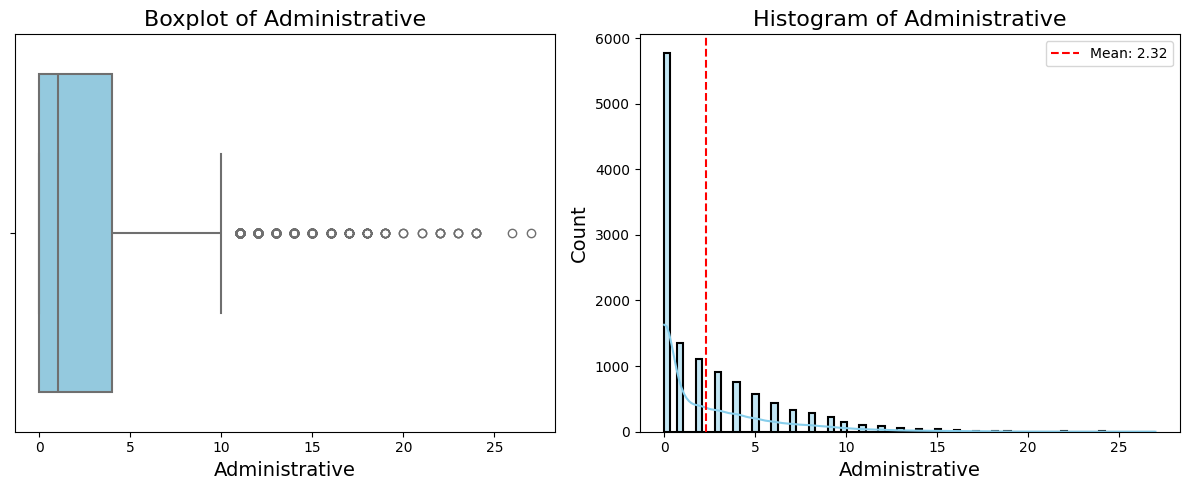

In [10]:
print("Summary statistics for 'Administrative':")
print(Ol_shop_data['Administrative'].describe())

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
sns.boxplot(x='Administrative', data=Ol_shop_data, ax=ax[0], color='skyblue', linewidth=1.5)
ax[0].set_title('Boxplot of Administrative', fontsize=16)
ax[0].set_xlabel('Administrative', fontsize=14)

# Histogram
sns.histplot(Ol_shop_data['Administrative'], kde=True, ax=ax[1], color='skyblue', linewidth=1.5)
mean_val = np.mean(Ol_shop_data['Administrative'])
ax[1].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
ax[1].set_title('Histogram of Administrative', fontsize=16)
ax[1].set_xlabel('Administrative', fontsize=14)
ax[1].set_ylabel('Count', fontsize=14)
ax[1].legend()

plt.tight_layout()
plt.show()


#### Univariate Analysis of `Administrative`

- **Summary Statistics:**  
  - Mean number of administrative page views is approximately **2.32**.  
  - Minimum value is **0**, and the maximum is **27**, indicating a wide range of interaction with administrative content.  
  - The standard deviation is **3.32**, showing moderate spread with some high-end variability.  
  - Median is **1**, with 25th percentile at **0** and 75th at **4**, indicating that at least half the users viewed very few administrative pages.

- **Boxplot:**  
  - Shows a **right-skewed distribution**, with a concentration of values below 5 and a significant number of **outliers above 10**.  
  - The whiskers extend up to around 10, after which isolated data points indicate less common, longer engagement with administrative content.

- **Histogram + KDE:**  
  - The distribution is **heavily right-skewed**, with most sessions having 0–2 administrative page views.  
  - The red dashed line representing the mean is noticeably higher than the mode, again highlighting skewness.  
  - A sharp drop in frequency is observed as page count increases beyond 5, with very few users visiting more than 10 administrative pages.

- **Conclusion:**  
  - Most users either **skip or lightly interact** with administrative pages.  
  - A small number of users show intense interaction, possibly due to **policy, help, or checkout-related activities**, resulting in **outliers**.

#### 2. Administrative_Duration

Summary statistics for 'Administrative_Duration':
count    12330.000000
mean        80.818611
std        176.779107
min          0.000000
25%          0.000000
50%          7.500000
75%         93.256250
max       3398.750000
Name: Administrative_Duration, dtype: float64


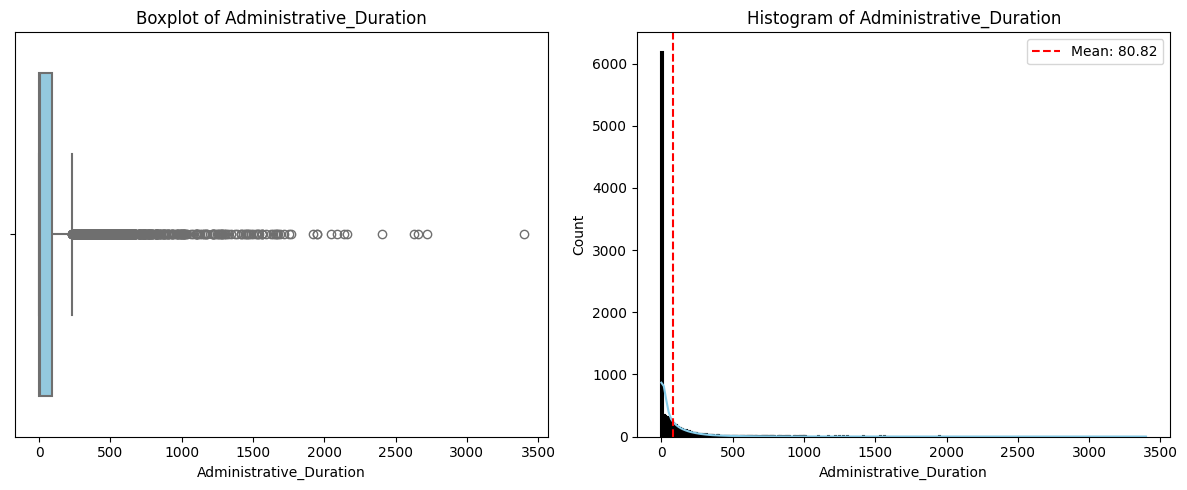

In [11]:
print("Summary statistics for 'Administrative_Duration':")
print(Ol_shop_data['Administrative_Duration'].describe())

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='Administrative_Duration', data=Ol_shop_data, ax=ax[0], color='skyblue', linewidth=1.5)
ax[0].set_title('Boxplot of Administrative_Duration')
ax[0].set_xlabel('Administrative_Duration')

sns.histplot(Ol_shop_data['Administrative_Duration'], kde=True, ax=ax[1], color='skyblue', linewidth=1.5)
mean_val = np.mean(Ol_shop_data['Administrative_Duration'])
ax[1].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
ax[1].set_title('Histogram of Administrative_Duration')
ax[1].set_xlabel('Administrative_Duration')
ax[1].legend()

plt.tight_layout()
plt.show()


#### Univariate Analysis of `Administrative_Duration`

- **Summary Statistics:**  
  - Mean duration is approximately 80.82 seconds.  
  - Minimum value is 0, indicating no time spent in the administrative section by many users.  
  - Maximum duration is 3398.75, which is extremely high and can be considered a potential outlier.  
  - The standard deviation is about 176.78, showing a very wide spread in the data.  
  - The median is 7.5, with the 25th percentile at 0 and the 75th percentile at approximately 93.26, indicating a highly skewed distribution.

- **Boxplot:**  
  - Shows a large number of outliers, especially on the higher end beyond 500 seconds.  
  - The majority of the data is concentrated at the lower end, with a clear long tail towards high values.  
  - The presence of so many outliers suggests that some users spend significantly more time than average on administrative pages.

- **Histogram + KDE:**  
  - The distribution is heavily right-skewed, with most values clustered near zero and a long tail toward the right.  
  - The mean (red dashed line) lies far to the right of the peak, emphasizing the influence of outliers on the average.  
  - The steep drop-off in the histogram confirms that the majority of users spend little to no time in the administrative section.

#### 3. Informational

Summary statistics for 'Informational':
count    12330.000000
mean         0.503569
std          1.270156
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         24.000000
Name: Informational, dtype: float64


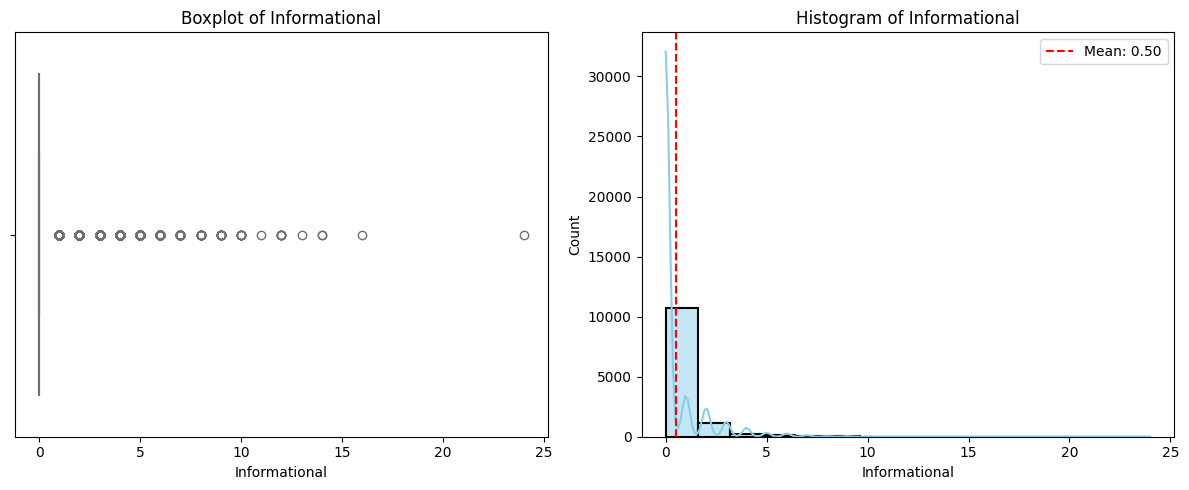

In [12]:
print("Summary statistics for 'Informational':")
print(Ol_shop_data['Informational'].describe())

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='Informational', data=Ol_shop_data, ax=ax[0], color='skyblue', linewidth=1.5)
ax[0].set_title('Boxplot of Informational')
ax[0].set_xlabel('Informational')

sns.histplot(Ol_shop_data['Informational'], kde=True, ax=ax[1], color='skyblue', linewidth=1.5)
mean_val = np.mean(Ol_shop_data['Informational'])
ax[1].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
ax[1].set_title('Histogram of Informational')
ax[1].set_xlabel('Informational')
ax[1].legend()

plt.tight_layout()
plt.show()


#### Univariate Analysis of `Informational`

- **Summary Statistics:**  
  - Mean value is approximately 0.50.  
  - Minimum value is 0, and the maximum observed is 24, which appears to be a potential outlier.  
  - The standard deviation is around 1.27, suggesting that most values are concentrated near 0.  
  - Both the median and interquartile range (25th and 75th percentiles) are 0, indicating that a large portion of the data is zero.

- **Boxplot:**  
  - Shows a heavy clustering of values at 0, with a few moderate to extreme outliers ranging up to 24.  
  - The majority of users did not visit the informational section of the website.  
  - The outliers are isolated and well-spaced, suggesting that only a few users accessed informational pages multiple times.

- **Histogram + KDE:**  
  - The distribution is extremely right-skewed, with a sharp spike at 0.  
  - The mean (red dashed line) lies just above 0, reflecting how the few higher values (outliers) pull the average up.  
  - Very few observations lie beyond 2–3, confirming that most users did not engage with the informational content.

#### 4. Informational_Duration

Summary statistics for 'Informational_Duration':
count    12330.000000
mean        34.472398
std        140.749294
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       2549.375000
Name: Informational_Duration, dtype: float64


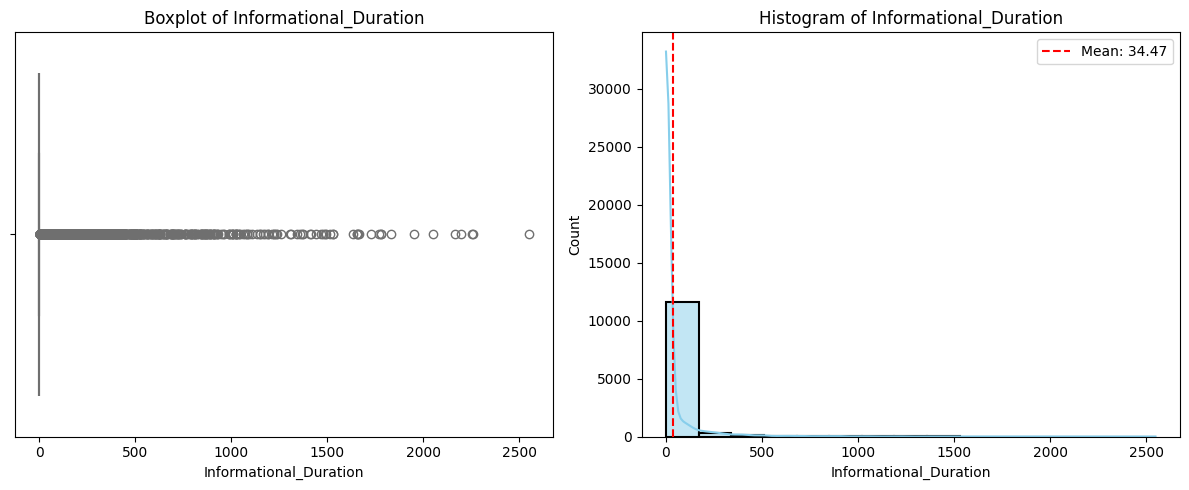

In [13]:
print("Summary statistics for 'Informational_Duration':")
print(Ol_shop_data['Informational_Duration'].describe())

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='Informational_Duration', data=Ol_shop_data, ax=ax[0], color='skyblue', linewidth=1.5)
ax[0].set_title('Boxplot of Informational_Duration')
ax[0].set_xlabel('Informational_Duration')

sns.histplot(Ol_shop_data['Informational_Duration'], kde=True, ax=ax[1], color='skyblue', linewidth=1.5)
mean_val = np.mean(Ol_shop_data['Informational_Duration'])
ax[1].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
ax[1].set_title('Histogram of Informational_Duration')
ax[1].set_xlabel('Informational_Duration')
ax[1].legend()

plt.tight_layout()
plt.show()


#### Univariate Analysis of `Informational_Duration`

- **Summary Statistics:**  
  - Mean duration is approximately 34.47 seconds.  
  - Minimum value is 0, while the maximum observed duration is 2549.38 seconds, which is a clear outlier.  
  - The standard deviation is quite high at around 140.75, indicating a large spread.  
  - The 25th, 50th (median), and 75th percentiles are all 0, showing that most users did not spend any time in the informational section.

- **Boxplot:**  
  - Displays a large number of outliers, mostly between 500 and 2500 seconds.  
  - A strong clustering of values at 0, with very few users spending a significant amount of time on informational pages.  
  - The presence of extreme outliers suggests a small group of users engaged deeply with this section.

- **Histogram + KDE:**  
  - The distribution is extremely right-skewed, with a sharp spike at 0 and a long tail stretching to the right.  
  - The mean (red dashed line) is noticeably pulled rightward due to a few large values.  
  - Very few users have durations greater than 100 seconds, indicating low overall engagement with informational content.

#### 5. ProductRelated

Summary statistics for 'ProductRelated':
count    12330.000000
mean        31.731468
std         44.475503
min          0.000000
25%          7.000000
50%         18.000000
75%         38.000000
max        705.000000
Name: ProductRelated, dtype: float64


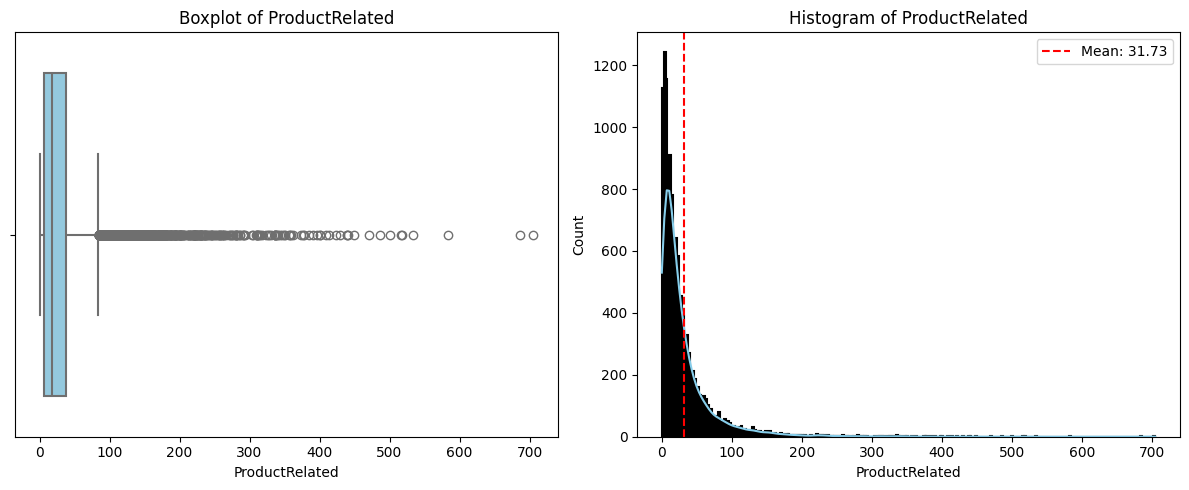

In [14]:
print("Summary statistics for 'ProductRelated':")
print(Ol_shop_data['ProductRelated'].describe())

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='ProductRelated', data=Ol_shop_data, ax=ax[0], color='skyblue', linewidth=1.5)
ax[0].set_title('Boxplot of ProductRelated')
ax[0].set_xlabel('ProductRelated')

sns.histplot(Ol_shop_data['ProductRelated'], kde=True, ax=ax[1], color='skyblue', linewidth=1.5)
mean_val = np.mean(Ol_shop_data['ProductRelated'])
ax[1].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
ax[1].set_title('Histogram of ProductRelated')
ax[1].set_xlabel('ProductRelated')
ax[1].legend()

plt.tight_layout()
plt.show()


#### Univariate Analysis of `ProductRelated`

- **Summary Statistics:**  
  - Mean number of product-related page visits is approximately 31.73.  
  - Minimum value is 0, indicating some users did not visit any product-related pages.  
  - Maximum value is 705, which is a clear outlier.  
  - The standard deviation is 44.48, reflecting high variability in page visits.  
  - The median is 18, with the 25th percentile at 7 and the 75th at 38, showing that half the users visited between 7 and 38 product-related pages.

- **Boxplot:**  
  - Reveals a significant number of high-end outliers, especially above 100.  
  - The spread is wide, with many values scattered throughout the range and a dense cluster in the lower range.  
  - Outliers above 500 are particularly rare and represent extreme browsing behavior.

- **Histogram + KDE:**  
  - The distribution is heavily right-skewed, with most users visiting fewer than 50 product-related pages.  
  - The red dashed line (mean) lies to the right of the histogram’s main peak, indicating that a few high values pull the average up.  
  - There’s a gradual decline in frequency as the number of visits increases, with only a small tail reaching the extreme values.

#### 6. ProductRelated_Duration

Summary statistics for 'ProductRelated_Duration':
count    12330.000000
mean      1194.746220
std       1913.669288
min          0.000000
25%        184.137500
50%        598.936905
75%       1464.157214
max      63973.522230
Name: ProductRelated_Duration, dtype: float64


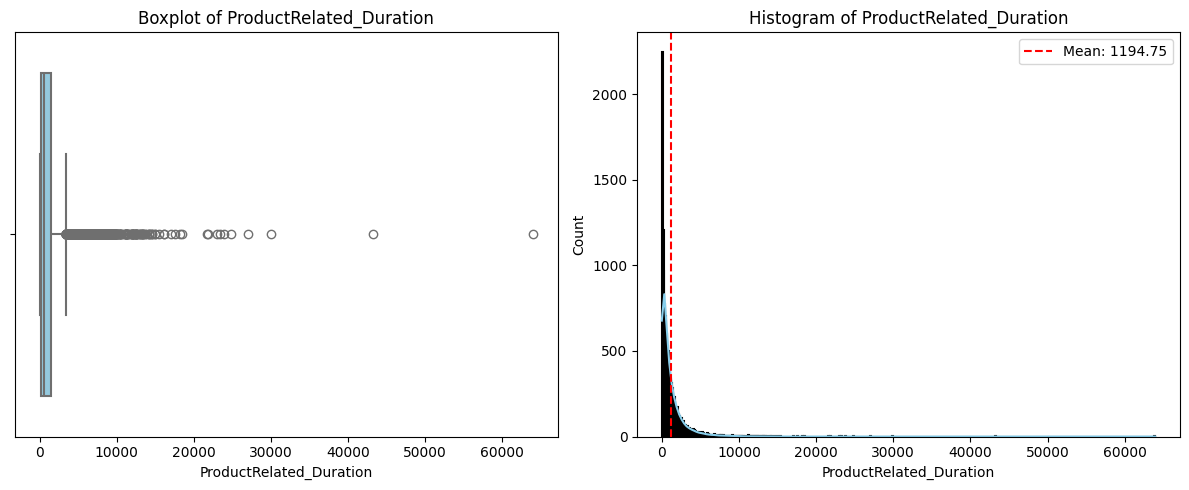

In [15]:
print("Summary statistics for 'ProductRelated_Duration':")
print(Ol_shop_data['ProductRelated_Duration'].describe())

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='ProductRelated_Duration', data=Ol_shop_data, ax=ax[0], color='skyblue', linewidth=1.5)
ax[0].set_title('Boxplot of ProductRelated_Duration')
ax[0].set_xlabel('ProductRelated_Duration')

sns.histplot(Ol_shop_data['ProductRelated_Duration'], kde=True, ax=ax[1], color='skyblue', linewidth=1.5)
mean_val = np.mean(Ol_shop_data['ProductRelated_Duration'])
ax[1].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
ax[1].set_title('Histogram of ProductRelated_Duration')
ax[1].set_xlabel('ProductRelated_Duration')
ax[1].legend()

plt.tight_layout()
plt.show()


#### Univariate Analysis of `ProductRelated_Duration`

- **Summary Statistics:**  
  - Mean duration spent on product-related pages is approximately 1194.75 seconds.  
  - Minimum value is 0, and the maximum is 63,973.52 seconds, which is an extreme outlier.  
  - The standard deviation is very high at 1913.67, indicating a wide range of time spent.  
  - The median is around 598.94, with the 25th percentile at 184.14 and the 75th at 1464.16, suggesting a positively skewed distribution.

- **Boxplot:**  
  - A large number of outliers are present, particularly beyond the 5000 mark, with a few stretching past 60,000 seconds.  
  - Most of the values lie well below 5000, with a dense cluster close to the lower quartiles.  
  - The wide range and extreme values highlight significant variance in user engagement with product-related content.

- **Histogram + KDE:**  
  - The distribution is highly right-skewed, with a steep peak in the lower range and a long tail extending toward large values.  
  - The red dashed line (mean) lies far to the right of the mode, indicating the effect of extreme durations in inflating the average.  
  - A majority of users spent between 0 and 2000 seconds, while only a few exhibit extreme browsing times.

#### 7. BounceRates

Summary statistics for 'BounceRates':
count    12330.000000
mean         0.022191
std          0.048488
min          0.000000
25%          0.000000
50%          0.003112
75%          0.016813
max          0.200000
Name: BounceRates, dtype: float64


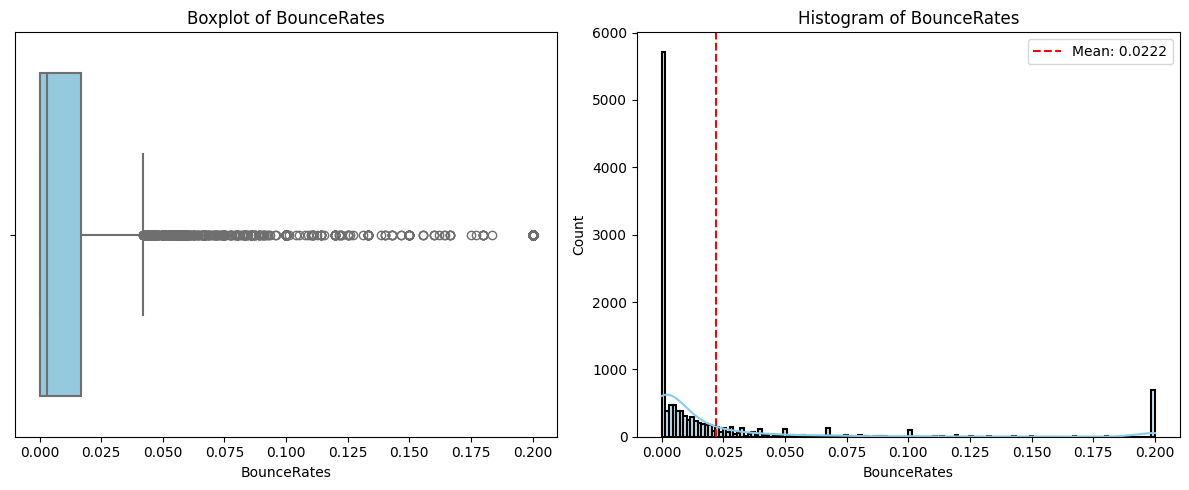

In [16]:
print("Summary statistics for 'BounceRates':")
print(Ol_shop_data['BounceRates'].describe())

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='BounceRates', data=Ol_shop_data, ax=ax[0], color='skyblue', linewidth=1.5)
ax[0].set_title('Boxplot of BounceRates')
ax[0].set_xlabel('BounceRates')

sns.histplot(Ol_shop_data['BounceRates'], kde=True, ax=ax[1], color='skyblue', linewidth=1.5)
mean_val = np.mean(Ol_shop_data['BounceRates'])
ax[1].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.4f}')
ax[1].set_title('Histogram of BounceRates')
ax[1].set_xlabel('BounceRates')
ax[1].legend()

plt.tight_layout()
plt.show()


#### Univariate Analysis of `BounceRates`

- **Summary Statistics:**  
  - Mean bounce rate is approximately 0.0222 (or 2.22%).  
  - Minimum value is 0, and the maximum is 0.20 (or 20%).  
  - The standard deviation is around 0.0485, suggesting low variability overall but with occasional spikes.  
  - The median is approximately 0.0031, with the 25th percentile at 0 and the 75th percentile at about 0.0168, indicating that most sessions had very low bounce rates.

- **Boxplot:**  
  - The plot is heavily skewed with a concentration of data near zero.  
  - A noticeable number of outliers appear between 0.05 and 0.20, showing that while most users didn’t bounce, a few did at significantly higher rates.  
  - The whiskers are short, confirming a dense lower range and long-tailed behavior.

- **Histogram + KDE:**  
  - The histogram confirms a strong right-skew, with a major spike at 0 and a long tail extending to 0.20.  
  - The red dashed line (mean) lies just above 0.02, showing that most values are clustered well below the average.  
  - A small group of users had relatively high bounce rates, possibly indicating less engaging sessions or quick exits.

#### 8. ExitRates

Summary statistics for 'ExitRates':
count    12330.000000
mean         0.043073
std          0.048597
min          0.000000
25%          0.014286
50%          0.025156
75%          0.050000
max          0.200000
Name: ExitRates, dtype: float64


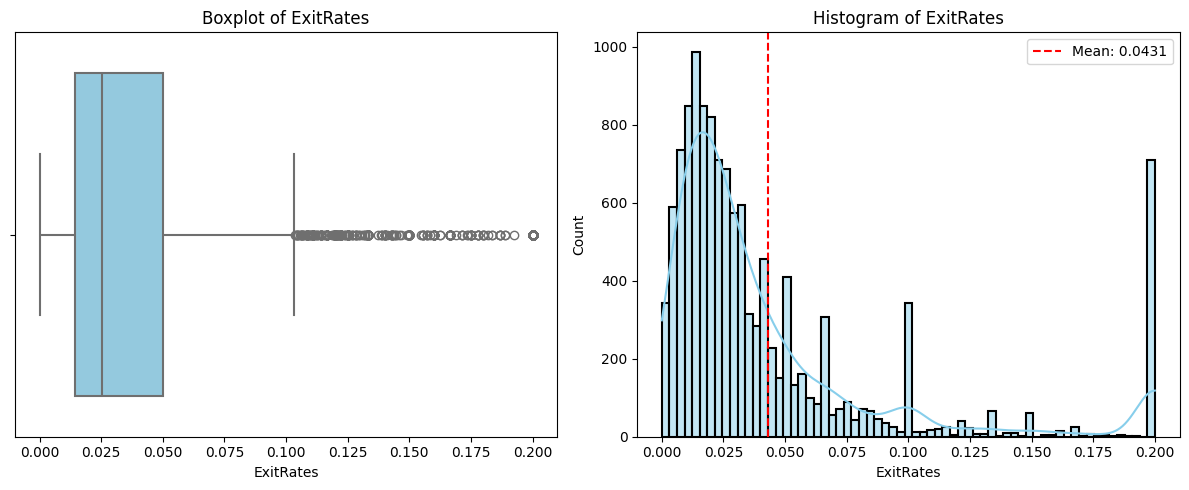

In [17]:
print("Summary statistics for 'ExitRates':")
print(Ol_shop_data['ExitRates'].describe())

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='ExitRates', data=Ol_shop_data, ax=ax[0], color='skyblue', linewidth=1.5)
ax[0].set_title('Boxplot of ExitRates')
ax[0].set_xlabel('ExitRates')

sns.histplot(Ol_shop_data['ExitRates'], kde=True, ax=ax[1], color='skyblue', linewidth=1.5)
mean_val = np.mean(Ol_shop_data['ExitRates'])
ax[1].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.4f}')
ax[1].set_title('Histogram of ExitRates')
ax[1].set_xlabel('ExitRates')
ax[1].legend()

plt.tight_layout()
plt.show()


#### Univariate Analysis of `ExitRates`

- **Summary Statistics:**  
  - Mean exit rate is approximately 0.0431 (or 4.31%).  
  - Minimum value is 0, while the maximum is 0.20 (or 20%).  
  - The standard deviation is about 0.0486, indicating moderate spread.  
  - The median is around 0.0252, with the 25th percentile at 0.0143 and the 75th percentile at 0.0500, suggesting that most values fall in the lower range.

- **Boxplot:**  
  - Displays a relatively symmetric box with mild skewness.  
  - A few outliers are visible, especially closer to the maximum of 0.20, suggesting some sessions ended more frequently on specific pages.  
  - The bulk of the data lies below 0.1, with relatively few extreme values.

- **Histogram + KDE:**  
  - The distribution is slightly right-skewed, with a visible peak in the range of 0.01 to 0.03.  
  - The red dashed line (mean) lies slightly right of the peak, indicating a few higher exit rates pulling the average upward.  
  - A small spike is observed near 0.2, likely caused by users exiting from landing or final pages.

#### 9. PageValues

Summary statistics for 'PageValues':
count    12330.000000
mean         5.889258
std         18.568437
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        361.763742
Name: PageValues, dtype: float64


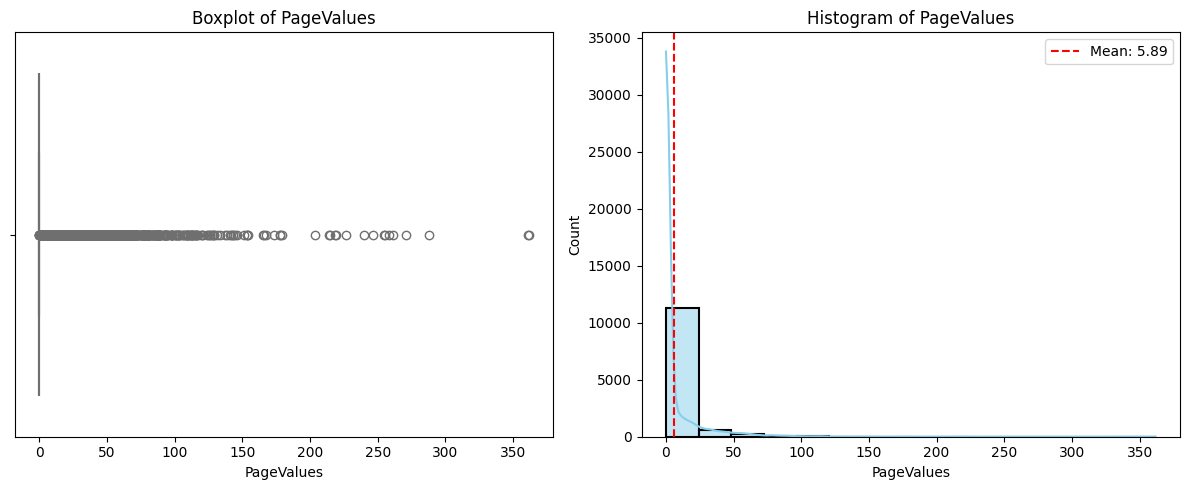

In [18]:
print("Summary statistics for 'PageValues':")
print(Ol_shop_data['PageValues'].describe())

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='PageValues', data=Ol_shop_data, ax=ax[0], color='skyblue', linewidth=1.5)
ax[0].set_title('Boxplot of PageValues')
ax[0].set_xlabel('PageValues')

sns.histplot(Ol_shop_data['PageValues'], kde=True, ax=ax[1], color='skyblue', linewidth=1.5)
mean_val = np.mean(Ol_shop_data['PageValues'])
ax[1].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
ax[1].set_title('Histogram of PageValues')
ax[1].set_xlabel('PageValues')
ax[1].legend()

plt.tight_layout()
plt.show()


#### Univariate Analysis of `PageValues`

- **Summary Statistics:**  
  - Mean page value is approximately 5.89.  
  - Minimum value is 0, and the maximum observed value is 361.76, indicating the presence of extreme outliers.  
  - The standard deviation is around 18.57, showing considerable spread.  
  - The 25th, 50th (median), and 75th percentiles are all 0, meaning most users did not encounter pages with associated monetary value.

- **Boxplot:**  
  - Displays a strong right-skew with numerous outliers, particularly above 50.  
  - The bulk of the data is concentrated at 0, with a long tail extending to high-value pages.  
  - Extreme outliers may reflect sessions where users were closer to completing a transaction or where product recommendations added high value.

- **Histogram + KDE:**  
  - The distribution is heavily right-skewed, with a steep peak at 0 and a long tail reaching over 350.  
  - The mean (red dashed line) is noticeably pulled to the right due to the influence of outliers.  
  - Most sessions had no page value assigned, suggesting limited direct engagement with revenue-generating content.

#### 10. SpecialDay

Summary statistics for 'SpecialDay':
count    12330.000000
mean         0.061427
std          0.198917
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: SpecialDay, dtype: float64


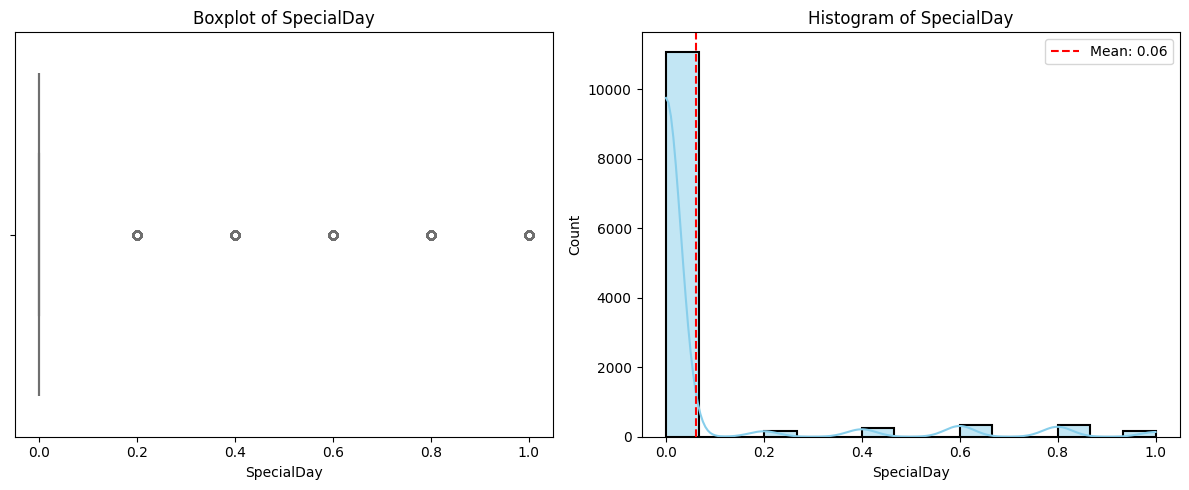

In [19]:
print("Summary statistics for 'SpecialDay':")
print(Ol_shop_data['SpecialDay'].describe())

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='SpecialDay', data=Ol_shop_data, ax=ax[0], color='skyblue', linewidth=1.5)
ax[0].set_title('Boxplot of SpecialDay')
ax[0].set_xlabel('SpecialDay')

sns.histplot(Ol_shop_data['SpecialDay'], kde=True, ax=ax[1], color='skyblue', linewidth=1.5)
mean_val = np.mean(Ol_shop_data['SpecialDay'])
ax[1].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
ax[1].set_title('Histogram of SpecialDay')
ax[1].set_xlabel('SpecialDay')
ax[1].legend()

plt.tight_layout()
plt.show()


#### Univariate Analysis of `SpecialDay`

- **Summary Statistics:**  
  - Mean value is approximately 0.0614.  
  - Minimum value is 0, and the maximum is 1.0.  
  - The standard deviation is around 0.1989, indicating low overall variance.  
  - The 25th, 50th (median), and 75th percentiles are all 0, showing that most sessions were not near any special day.

- **Boxplot:**  
  - Displays a highly skewed distribution with most data points at 0 and a few distinct values between 0.2 and 1.0 marked as outliers.  
  - The outliers likely correspond to sessions closer to a special day (like a holiday or promotion), possibly impacting user behavior.

- **Histogram + KDE:**  
  - The histogram confirms that the vast majority of sessions are far from a special day, with a sharp spike at 0.  
  - The red dashed line (mean) lies close to 0, consistent with the data being mostly 0.  
  - A few counts appear at intervals like 0.2, 0.4, 0.6, 0.8, and 1.0, suggesting that special day proximity is categorized in steps rather than continuously.

### Univariate Analysis of Categorical Variable:

#### 1. Month

Value counts for 'Month':
Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64
Number of unique categories: 10
--------------------------------------------------


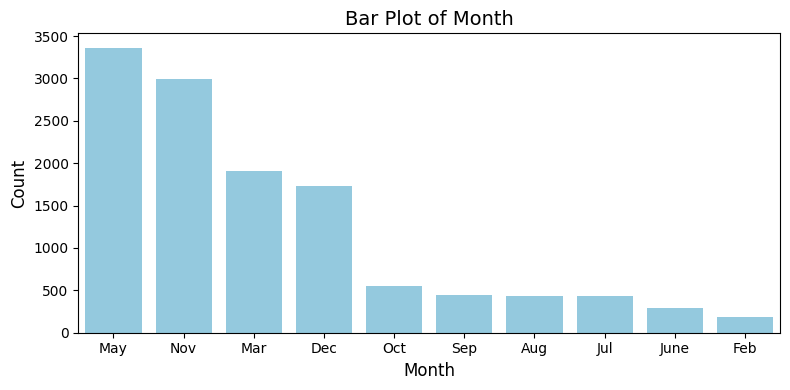

In [20]:
print("Value counts for 'Month':")
print(Ol_shop_data['Month'].value_counts(dropna=False))
print("Number of unique categories:", Ol_shop_data['Month'].nunique())
print("-" * 50)

plt.figure(figsize=(8, 4))
sns.countplot(data=Ol_shop_data, x='Month', color='skyblue', order=Ol_shop_data['Month'].value_counts().index)
plt.title("Bar Plot of Month", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()


#### Univariate Analysis of `Month`

- **Summary Statistics:**  
  - The variable `Month` has **10 unique categories**, representing session activity across different months of the year.  
  - The distribution of sessions is **not uniform**, indicating seasonality or campaign effects.

- **Bar Plot:**  
  - **May** has the highest number of sessions (3364), followed by **November** (2998), **March** (1907), and **December** (1727). These months likely correspond to key promotional or shopping periods (e.g., spring sales, Black Friday, and holiday season).  
  - Months like **February (184)**, **June (288)**, **July (432)**, and **August (433)** have the **lowest activity**, suggesting reduced customer engagement during these periods.  
  - The middle range includes **October (549)** and **September (448)** with moderate activity.  
  - Of all months **April** and **January** seem to be missing.
  - Overall, there’s a **clear seasonality pattern**, with traffic peaking during specific months aligned with known shopping seasons.

#### 2. OperatingSystems

Value counts for 'OperatingSystems':
OperatingSystems
2    6601
1    2585
3    2555
4     478
8      79
6      19
7       7
5       6
Name: count, dtype: int64
Number of unique categories: 8
--------------------------------------------------


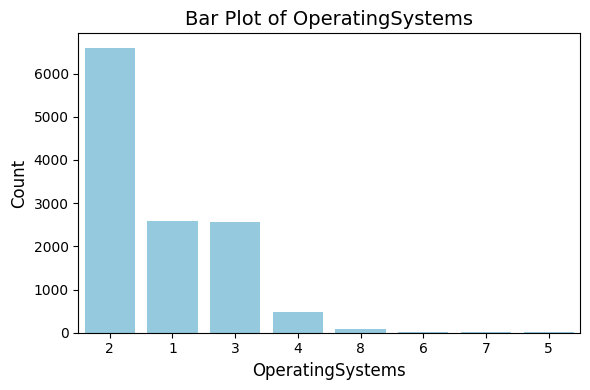

In [21]:
print("Value counts for 'OperatingSystems':")
print(Ol_shop_data['OperatingSystems'].value_counts(dropna=False))
print("Number of unique categories:", Ol_shop_data['OperatingSystems'].nunique())
print("-" * 50)

plt.figure(figsize=(6, 4))
sns.countplot(data=Ol_shop_data, x='OperatingSystems', color='skyblue', order=Ol_shop_data['OperatingSystems'].value_counts().index)
plt.title("Bar Plot of OperatingSystems", fontsize=14)
plt.xlabel("OperatingSystems", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()


#### Univariate Analysis of `OperatingSystems`

- **Summary Statistics:**  
  - The variable `OperatingSystems` has **8 unique categories**, likely representing different platforms or browser environments detected during sessions.  
  - The distribution is **highly imbalanced**, with some operating systems dominating user sessions.

- **Bar Plot:**  
  - **Category 2** has the highest count (6601), accounting for more than half of the sessions.  
  - **Categories 1 and 3** follow with nearly equal counts (2585 and 2555 respectively), indicating similar popularity or usage rates.  
  - **Category 4** appears less frequently (478), while categories **5, 6, 7, and 8** are rare, with **Category 8** having just 79 sessions and the others fewer than 20.  
  - The long-tail distribution suggests that the majority of traffic comes from just a few operating systems, while the rest contribute minimally.

#### 3. Browser

Value counts for 'Browser':
Browser
2     7961
1     2462
4      736
5      467
6      174
10     163
8      135
3      105
13      61
7       49
12      10
11       6
9        1
Name: count, dtype: int64
Number of unique categories: 13
--------------------------------------------------


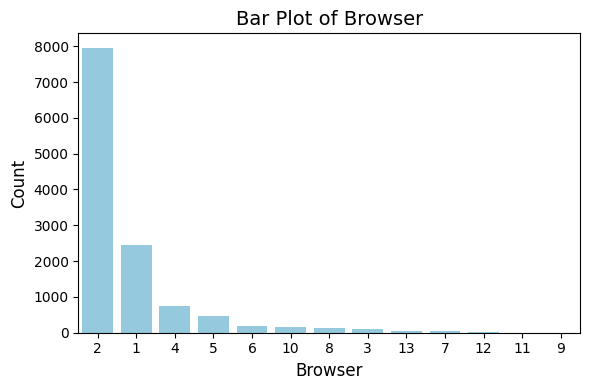

In [22]:
print("Value counts for 'Browser':")
print(Ol_shop_data['Browser'].value_counts(dropna=False))
print("Number of unique categories:", Ol_shop_data['Browser'].nunique())
print("-" * 50)

plt.figure(figsize=(6, 4))
sns.countplot(data=Ol_shop_data, x='Browser', color='skyblue', order=Ol_shop_data['Browser'].value_counts().index)
plt.title("Bar Plot of Browser", fontsize=14)
plt.xlabel("Browser", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()


#### Univariate Analysis of `Browser`

- **Summary Statistics:**  
  - The `Browser` variable consists of **13 unique categories**, each likely representing a different browser or browser version used during sessions.  
  - The distribution is **highly skewed**, with one browser type overwhelmingly dominant.

- **Bar Plot:**  
  - **Category 2** accounts for the majority of sessions (7961), indicating it is by far the most commonly used browser.  
  - **Category 1** is the second most common, with 2462 sessions.  
  - The next tier includes **Categories 4 (736)** and **5 (467)**, while the rest of the categories have significantly fewer observations.  
  - **Categories 9, 11, and 12** are rarely used, with **Category 9** appearing only once.  
  - The long-tail pattern shows that while the platform supports many browsers, only a few are actively used by most visitors.

#### 4. Region

Value counts for 'Region':
Region
1    4780
3    2403
4    1182
2    1136
6     805
7     761
9     511
8     434
5     318
Name: count, dtype: int64
Number of unique categories: 9
--------------------------------------------------


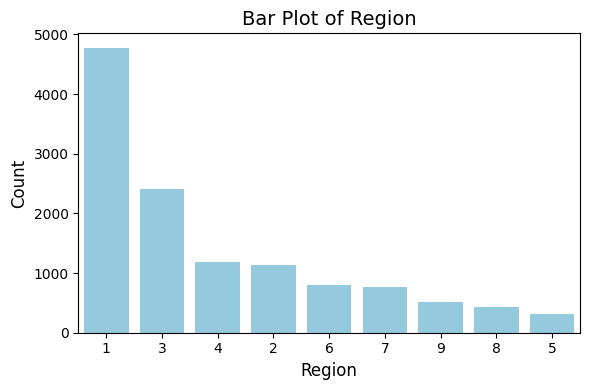

In [23]:
print("Value counts for 'Region':")
print(Ol_shop_data['Region'].value_counts(dropna=False))
print("Number of unique categories:", Ol_shop_data['Region'].nunique())
print("-" * 50)

plt.figure(figsize=(6, 4))
sns.countplot(data=Ol_shop_data, x='Region', color='skyblue', order=Ol_shop_data['Region'].value_counts().index)
plt.title("Bar Plot of Region", fontsize=14)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()


#### Univariate Analysis of `Region`

- **Summary Statistics:**  
  - The `Region` variable contains **9 unique categories**, representing different geographic regions or market segments.  
  - The distribution is **highly imbalanced**, suggesting some regions are much more active or targeted than others.

- **Bar Plot:**  
  - **Region 1** is the most active, with **4780 sessions**, indicating either a higher customer base or focused marketing efforts.  
  - **Region 3** follows with 2403 sessions, and **Regions 4 and 2** are nearly equal, with around 1100 sessions each.  
  - The remaining regions—**6, 7, 9, 8, and 5**—have significantly lower representation, with **Region 5** being the least active at just 318 sessions.  
  - This distribution suggests regional differences in engagement, which could inform location-specific strategies.

#### 5. TrafficType

Value counts for 'TrafficType':
TrafficType
2     3913
1     2451
3     2052
4     1069
13     738
10     450
6      444
8      343
5      260
11     247
20     198
9       42
7       40
15      38
19      17
14      13
18      10
16       3
12       1
17       1
Name: count, dtype: int64
Number of unique categories: 20
--------------------------------------------------


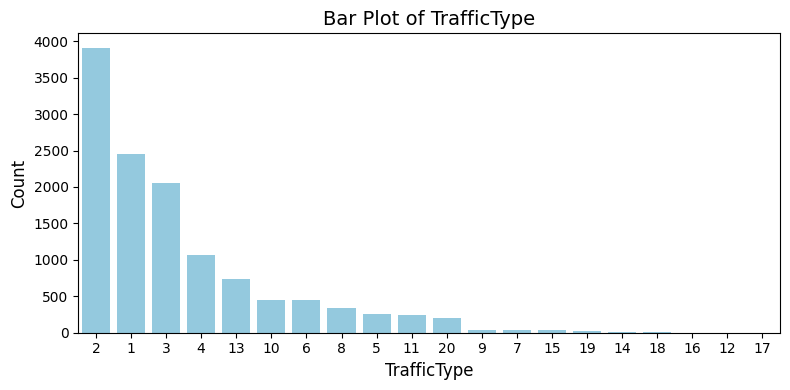

In [24]:
print("Value counts for 'TrafficType':")
print(Ol_shop_data['TrafficType'].value_counts(dropna=False))
print("Number of unique categories:", Ol_shop_data['TrafficType'].nunique())
print("-" * 50)

plt.figure(figsize=(8, 4))
sns.countplot(data=Ol_shop_data, x='TrafficType', color='skyblue', order=Ol_shop_data['TrafficType'].value_counts().index)
plt.title("Bar Plot of TrafficType", fontsize=14)
plt.xlabel("TrafficType", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()


#### Univariate Analysis of `TrafficType`

- **Summary Statistics:**  
  - The `TrafficType` variable consists of **20 unique categories**, likely representing different traffic sources or referral channels.  
  - The distribution is **highly imbalanced**, with a few traffic types contributing to the majority of sessions.

- **Bar Plot:**  
  - **TrafficType 2** dominates the traffic distribution with **3913 sessions**, followed by **Type 1 (2451)** and **Type 3 (2052)**.  
  - Other mid-range types like **4, 13, 10, 6, 8, and 5** have between 200 to 1000 sessions each.  
  - The remaining types—especially **12 and 17**—are extremely rare, each with only **1 session**, and **Types 16, 18, 14, 19, and 15** have fewer than 20 observations.  
  - This long-tail distribution indicates that while multiple sources drive traffic, the majority comes from a small set of well-performing or dominant channels.

#### 6. VisitorType

Value counts for 'VisitorType':
VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64
Number of unique categories: 3
--------------------------------------------------


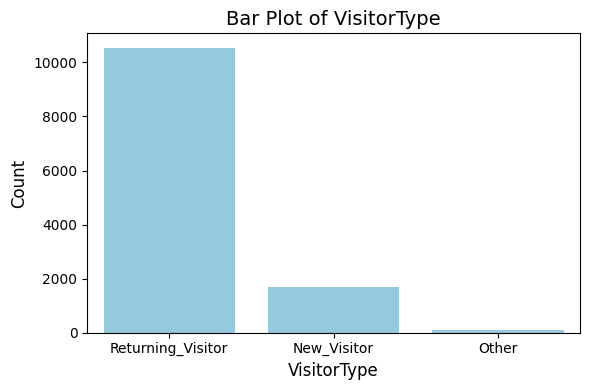

In [25]:
print("Value counts for 'VisitorType':")
print(Ol_shop_data['VisitorType'].value_counts(dropna=False))
print("Number of unique categories:", Ol_shop_data['VisitorType'].nunique())
print("-" * 50)

plt.figure(figsize=(6, 4))
sns.countplot(data=Ol_shop_data, x='VisitorType', color='skyblue', order=Ol_shop_data['VisitorType'].value_counts().index)
plt.title("Bar Plot of VisitorType", fontsize=14)
plt.xlabel("VisitorType", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()


#### Univariate Analysis of `VisitorType`

- **Summary Statistics:**  
  - The `VisitorType` variable includes **3 unique categories**: `Returning_Visitor`, `New_Visitor`, and `Other`.  
  - The distribution is highly skewed toward one category, indicating dominant user behavior patterns.

- **Bar Plot:**  
  - **Returning_Visitor** accounts for the overwhelming majority of sessions (10,551), showing strong user loyalty or frequent repeat visits.  
  - **New_Visitor** represents a smaller portion of the data (1694 sessions), indicating fewer first-time visits.  
  - **Other** is negligible with just 85 observations, possibly including bots, unknown classifications, or special cases.  
  - This imbalance highlights the importance of optimizing the site experience for returning users while also investigating ways to improve new visitor conversion.

#### 7. Weekend

Value counts for 'Weekend':
Weekend
False    9462
True     2868
Name: count, dtype: int64
Number of unique categories: 2
--------------------------------------------------


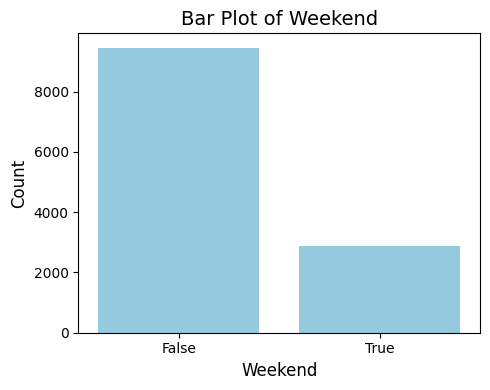

In [26]:
print("Value counts for 'Weekend':")
print(Ol_shop_data['Weekend'].value_counts(dropna=False))
print("Number of unique categories:", Ol_shop_data['Weekend'].nunique())
print("-" * 50)

plt.figure(figsize=(5, 4))
sns.countplot(data=Ol_shop_data, x='Weekend', color='skyblue')
plt.title("Bar Plot of Weekend", fontsize=14)
plt.xlabel("Weekend", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()


#### Univariate Analysis of `Weekend`

- **Summary Statistics:**  
  - The `Weekend` variable has **2 unique categories**: `True` and `False`, indicating whether a session occurred during the weekend.  
  - There is a clear disparity in session counts between weekdays and weekends.

- **Bar Plot:**  
  - **False (Weekday)** sessions dominate with **9462 observations**, showing that the majority of user activity occurs on weekdays.  
  - **True (Weekend)** sessions account for **2868 observations**, significantly fewer in comparison.  
  - This suggests that users are more active or likely to browse the site during weekdays, which may reflect typical workweek browsing behavior.

### Bivariate Analysis:  Numerical Variable Vs Numerical Variable:

#### 1. Heatmap Between Numerical variables:

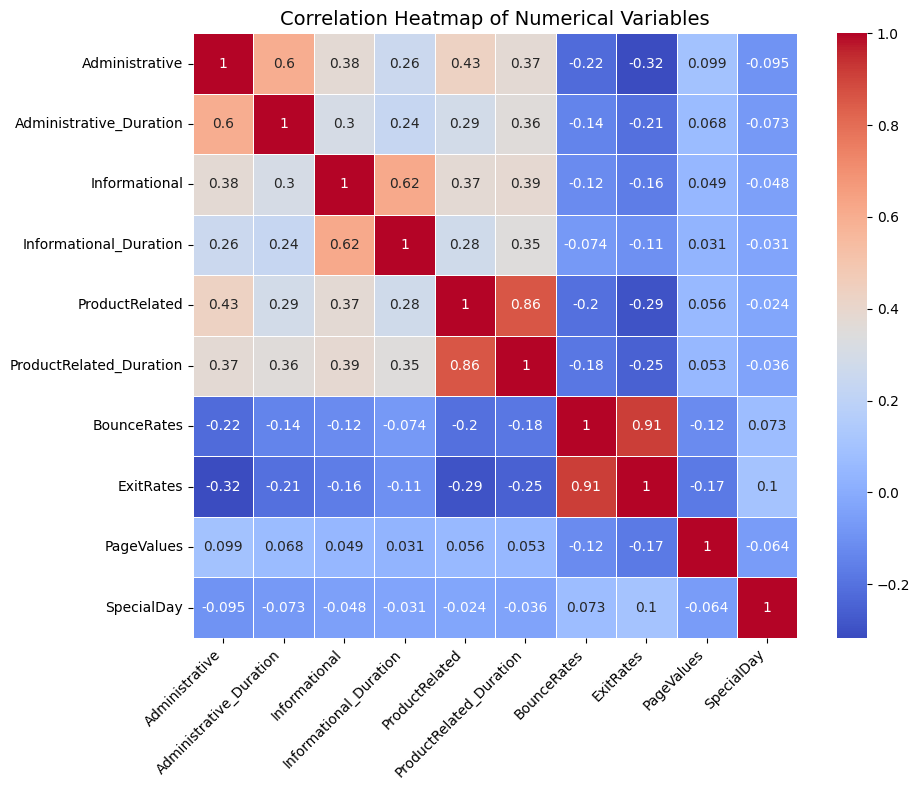

In [27]:
# Select numerical variables
num_vars = ['Administrative', 'Administrative_Duration',
            'Informational', 'Informational_Duration',
            'ProductRelated', 'ProductRelated_Duration',
            'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

# Compute correlation matrix
corr_matrix = Ol_shop_data[num_vars].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', square=True, linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Variables", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


#### Correlation Analysis of Numerical Variables
- **Key Positive Correlations:**  
  - **ProductRelated ↔ ProductRelated_Duration**: **0.86** – Strong positive correlation, suggesting that more product-related page views are closely associated with longer time spent on them.  
  - **Informational ↔ Informational_Duration**: **0.62** – Similarly, the number of informational pages visited increases with the time spent on them.  
  - **Administrative ↔ Administrative_Duration**: **0.60** – A moderate to strong positive correlation is seen here too.  
  - **BounceRates ↔ ExitRates**: **0.91** – Very strong positive correlation; visitors who bounce are very likely to exit from the landing page.

- **Notable Negative Correlations:**  
  - **ExitRates ↔ Administrative (-0.32)**, **ProductRelated (-0.29)**, **ProductRelated_Duration (-0.25)** – Users spending more time on these sections are less likely to exit early.  
  - **BounceRates** and **ExitRates** show mild negative correlation with most engagement-related variables.

- **Low or No Correlation:**  
  - **PageValues** and **SpecialDay** have generally low correlations (close to 0) with most variables, suggesting that their effects might be more complex or categorical in nature.  
  - Example: **SpecialDay ↔ all features** – correlations are very close to zero, indicating it may not have a direct linear relationship with session behaviors.

#### 2. Administrative vs. Administrative_Duration

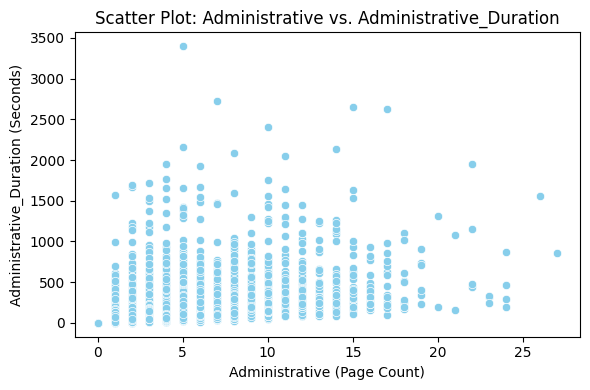

In [28]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Administrative', y='Administrative_Duration', data=Ol_shop_data, color='skyblue')
plt.title('Scatter Plot: Administrative vs. Administrative_Duration')
plt.xlabel('Administrative (Page Count)')
plt.ylabel('Administrative_Duration (Seconds)')
plt.tight_layout()
plt.show()


#### Bivariate Analysis: `Administrative` vs. `Administrative_Duration`

- **Pattern Observed:**  
  - A **positive trend** is evident overall — as the number of administrative pages increases, the total duration tends to increase as well.  
  - However, the pattern is **not strictly linear**; there is **high variability** in duration for a given page count.  
  - For example, some users spent significantly longer durations even with relatively few page visits, possibly due to idling or reading in-depth.

- **Outliers:**  
  - There are a few extreme duration values (e.g., >3000 seconds), which stand out clearly in the upper portion of the plot.  
  - These could indicate unusually long browsing sessions or noise in the data.

- **Conclusion:**  
  - While there is a **moderate positive correlation** (confirmed in the heatmap: ~0.60), the relationship includes **non-linearities and outliers**.  
  - Useful for modeling, but may benefit from log transformation or outlier handling for improved performance.

#### Informational vs. Informational_Duration

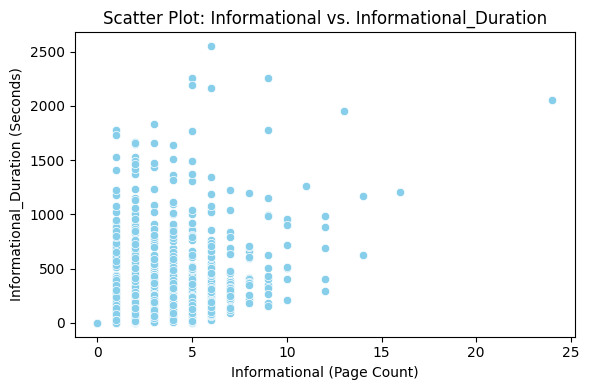

In [29]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Informational', y='Informational_Duration', data=Ol_shop_data, color='skyblue')
plt.title('Scatter Plot: Informational vs. Informational_Duration')
plt.xlabel('Informational (Page Count)')
plt.ylabel('Informational_Duration (Seconds)')
plt.tight_layout()
plt.show()


#### Bivariate Analysis: `Informational` vs. `Informational_Duration`


- **Pattern Observed:**  
  - A **moderate positive correlation** is visible — as users visit more informational pages, they generally spend more time in that section.  
  - However, the data is **sparse and noisy**, with wide variation in duration even for the same number of page views.

- **Concentration:**  
  - Most data points are clustered between **0 to 5 pages** and **0 to 1500 seconds**, reflecting that few users engage deeply with informational content.  
  - The rest of the plot is sparsely populated, with very few sessions exceeding 10 informational page visits or durations above 2000 seconds.

- **Outliers:**  
  - Several outliers can be seen, such as a user who spent over 2500 seconds on fewer than 10 pages, and another with 24 page views — these are rare cases of high engagement or possibly idle time.

- **Conclusion:**  
  - While there is a general upward trend (supported by the correlation coefficient of ~0.62), the relationship is **non-linear with significant variance**.  
  - It may benefit from **transformation or segmentation** when used in modeling.

#### ProductRelated vs. ProductRelated_Duration

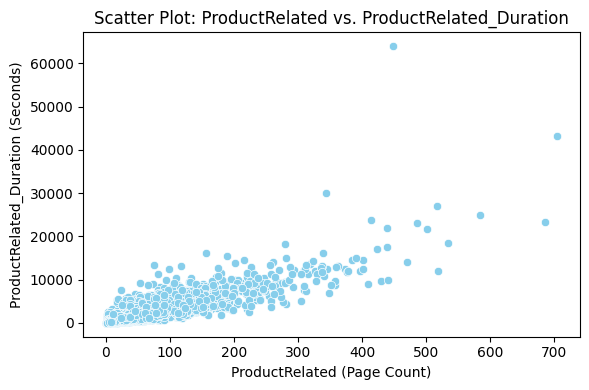

In [30]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='ProductRelated', y='ProductRelated_Duration', data=Ol_shop_data, color='skyblue')
plt.title('Scatter Plot: ProductRelated vs. ProductRelated_Duration')
plt.xlabel('ProductRelated (Page Count)')
plt.ylabel('ProductRelated_Duration (Seconds)')
plt.tight_layout()
plt.show()


#### Bivariate Analysis: `ProductRelated` vs. `ProductRelated_Duration`

- **Pattern Observed:**  
  - A **strong positive linear relationship** is clearly visible — as the number of product-related page views increases, the duration spent on those pages also increases.  
  - This is consistent with the high correlation value (~0.86) observed in the correlation heatmap.

- **Density & Spread:**  
  - Most sessions are concentrated below **200 page views** and **20,000 seconds**.  
  - There is a dense cluster of low to mid-range activity, followed by a gradually thinning pattern toward the upper right.

- **Outliers:**  
  - A few **extreme outliers** are visible, including one session with over **700 page views** and another with more than **60,000 seconds** (~17 hours), which could indicate unusual user behavior or session tracking anomalies.

- **Conclusion:**  
  - This is a **highly linear and predictable relationship**, suggesting that the `ProductRelated` count can be a strong proxy for time spent on product content.  
  - Ideal for modeling user interest or engagement in product exploration.

#### BounceRates vs. ExitRates

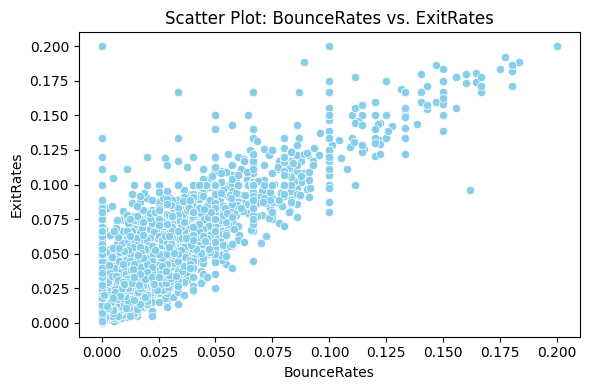

In [31]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='BounceRates', y='ExitRates', data=Ol_shop_data, color='skyblue')
plt.title('Scatter Plot: BounceRates vs. ExitRates')
plt.xlabel('BounceRates')
plt.ylabel('ExitRates')
plt.tight_layout()
plt.show()


#### Bivariate Analysis: `BounceRates` vs. `ExitRates`

- **Pattern Observed:**  
  - A **strong positive linear relationship** is clearly visible, where an increase in bounce rate is often accompanied by an increase in exit rate.  
  - This is consistent with the **very high correlation value (0.91)** seen in the correlation heatmap.

- **Clustering:**  
  - Most data points are concentrated in the **lower-left quadrant**, where both bounce and exit rates are below 0.1.  
  - There is a relatively smooth gradient from low to high, with the upper boundary following a near-linear path.

- **Outliers:**  
  - A few sessions have higher than usual exit rates relative to their bounce rates and vice versa, but they are sparse and do not disrupt the general trend.

- **Conclusion:**  
  - The features are **highly collinear**, which suggests redundancy in modeling; including both may lead to **multicollinearity** in linear models.  
  - Consider using **only one** of the two features or applying **dimensionality reduction** techniques if both are retained.

#### PageValues vs. ProductRelated

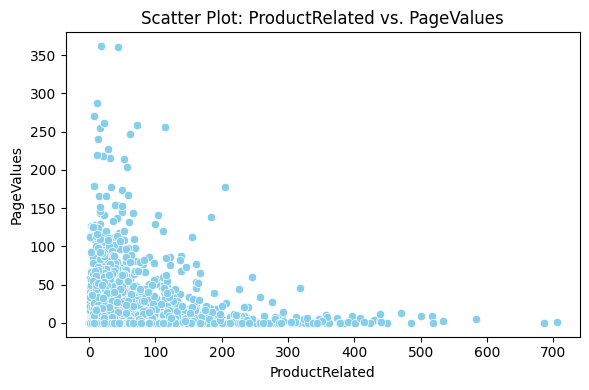

In [32]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='ProductRelated', y='PageValues', data=Ol_shop_data, color='skyblue')
plt.title('Scatter Plot: ProductRelated vs. PageValues')
plt.xlabel('ProductRelated')
plt.ylabel('PageValues')
plt.tight_layout()
plt.show()


#### Bivariate Analysis: `ProductRelated` vs. `PageValues`

- **Pattern Observed:**  
  - Contrary to typical expectation, there is **no clear positive correlation**.  
  - In fact, `PageValues` tends to **peak when `ProductRelated` is low (under 100)**, and **tapers off** as page count increases.  
  - This indicates that **high page views do not necessarily translate to higher value**, and users with fewer interactions may be closer to conversion.

- **Concentration & Spread:**  
  - Most values are clustered in the **lower-left corner**, where both product views and page values are low or zero.  
  - A few sessions with **high page values (100–350)** are concentrated where page views are relatively low, possibly representing quick, high-value interactions.

- **Outliers:**  
  - A few extreme values are visible on both axes, with **page counts exceeding 600** and **values exceeding 350**, although these are rare.

- **Conclusion:**  
  - There is **little to no linear correlation** between the two features (as supported by the correlation coefficient of ~0.056).  
  - For modeling, it may be useful to explore **non-linear patterns**, segmentation, or interaction terms to capture their joint effect on conversion behavior.

#### SpecialDay vs. PageValues

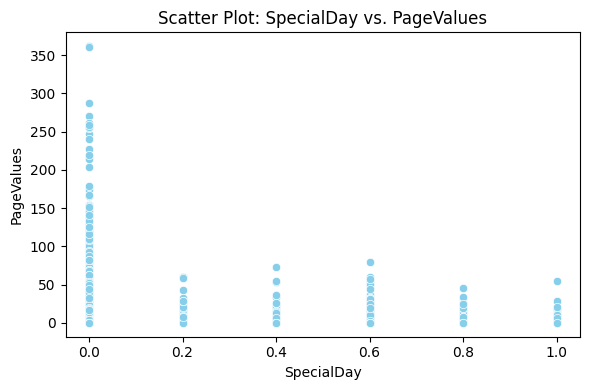

In [33]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='SpecialDay', y='PageValues', data=Ol_shop_data, color='skyblue')
plt.title('Scatter Plot: SpecialDay vs. PageValues')
plt.xlabel('SpecialDay')
plt.ylabel('PageValues')
plt.tight_layout()
plt.show()


#### Bivariate Analysis: `SpecialDay` vs. `PageValues`

- **Pattern Observed:**  
  - The majority of sessions with **high `PageValues`** occur when `SpecialDay` is **0** (i.e., not near any special day).  
  - For other values (e.g., 0.2, 0.4, 0.6, etc.), the **spread is significantly narrower**, with most values remaining below 100.

- **Concentration & Distribution:**  
  - There is a **heavy concentration of sessions** around `SpecialDay = 0`, with wide variance in `PageValues`, including some of the **highest values in the dataset**.  
  - As `SpecialDay` increases toward 1 (indicating closer proximity to a special day), the `PageValues` do not show a consistent increase and remain relatively **low and sparse**.

- **Conclusion:**  
  - There appears to be **no strong positive correlation** between proximity to a special day and the value of pages viewed.  
  - Surprisingly, **higher-value sessions are more likely to occur away from special days**, possibly due to non-promotional organic interest.  
  - This suggests that the `SpecialDay` feature may not be a strong standalone predictor of value and may require interaction with other variables (e.g., `Month`, `TrafficType`) to reveal deeper insights.

#### ProductRelated vs. Administrative

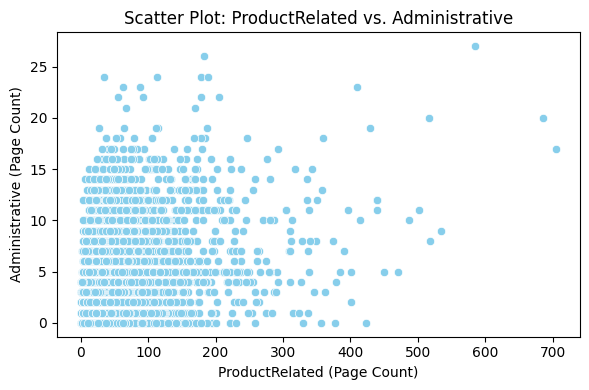

In [34]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='ProductRelated', y='Administrative', data=Ol_shop_data, color='skyblue')
plt.title('Scatter Plot: ProductRelated vs. Administrative')
plt.xlabel('ProductRelated (Page Count)')
plt.ylabel('Administrative (Page Count)')
plt.tight_layout()
plt.show()


#### Bivariate Analysis: `ProductRelated` vs. `Administrative`

- **Pattern Observed:**  
  - There is **no strong linear relationship** visible between the two variables.  
  - The data is **widely scattered**, with administrative page views ranging from 0 to 27 across almost the entire range of product-related counts.

- **Concentration & Spread:**  
  - Most sessions are concentrated in the **lower-left region**, especially between 0–200 `ProductRelated` pages and 0–15 `Administrative` pages.  
  - The **density thins out** as `ProductRelated` counts exceed 200, but administrative page counts continue to span a broad range.  
  - A few outliers with high product page views (up to 700) and administrative page views (over 25) are visible but sparse.

- **Conclusion:**  
  - The **weak and non-linear association** suggests that users' interactions with product-related pages are **mostly independent** of their engagement with administrative content.  
  - This indicates different navigation intents — users interested in products may not necessarily explore administrative information and vice versa.

#### Informational vs. ProductRelated_Duration

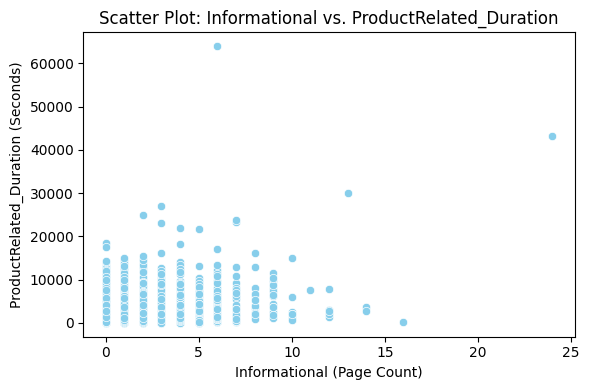

In [35]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Informational', y='ProductRelated_Duration', data=Ol_shop_data, color='skyblue')
plt.title('Scatter Plot: Informational vs. ProductRelated_Duration')
plt.xlabel('Informational (Page Count)')
plt.ylabel('ProductRelated_Duration (Seconds)')
plt.tight_layout()
plt.show()


#### Bivariate Analysis: `Informational` vs. `ProductRelated_Duration`

- **Pattern Observed:**  
  - There is **no clear or strong relationship** between the number of informational pages and the duration spent on product-related content.  
  - The data appears **scattered and dispersed**, with **no upward or downward trend** visible.

- **Concentration & Spread:**  
  - Most sessions lie between **0–10 informational pages** and **0–20,000 seconds** on product-related pages.  
  - A handful of outliers are seen with **very high durations (above 60,000 seconds)** and **moderate informational activity**, suggesting unusual session behavior.

- **Conclusion:**  
  - The lack of a consistent pattern suggests that time spent on product-related content is **independent of how many informational pages a user views**.  
  - These two variables likely reflect **distinct browsing behaviors**: informational seekers vs. product explorers.  
  - Correlation analysis (≈ 0.39) supports this observation — mild positive relationship, but with **considerable noise**.

### Bivariate Analysis:  Categorical Variable Vs Categorical Variable:

#### VisitorType vs. Weekend

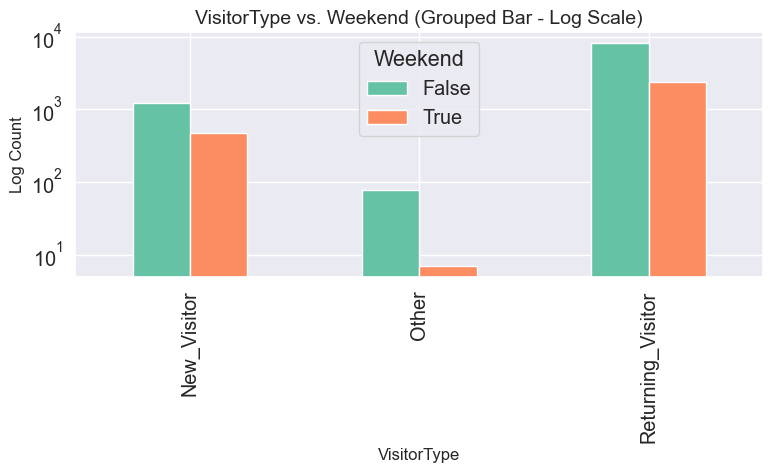

In [36]:
# Set overall font size
sns.set(font_scale=1.3)

# Create a custom 2-color palette
palette = sns.color_palette("Set2", 2)

# Group data
grouped_data = Ol_shop_data.groupby(['VisitorType', 'Weekend']).size().unstack(fill_value=0)

# Plot with log-scaled y-axis
ax = grouped_data.plot(kind='bar', stacked=False, figsize=(8, 5), color=palette)
plt.yscale('log')  # Apply logarithmic scale
plt.title("VisitorType vs. Weekend (Grouped Bar - Log Scale)", fontsize=14)
plt.xlabel("VisitorType", fontsize=12)
plt.ylabel("Log Count", fontsize=12)
plt.legend(title="Weekend")
plt.tight_layout()
plt.show()


#### Bivariate Analysis: `VisitorType` vs. `Weekend`

- **Plot Overview:**  
  - This grouped bar chart displays the distribution of **visitor types** (`Returning_Visitor`, `New_Visitor`, `Other`) split by whether the session occurred on a **weekend (`True`) or not (`False`)**.  
  - The y-axis is in **logarithmic scale**, allowing visibility into large differences in count magnitude.

- **Pattern Observed:**  
  - **Returning Visitors** dominate the dataset, with **weekdays showing significantly higher counts** than weekends.  
  - **New Visitors** also show higher activity during weekdays, though the gap between weekday and weekend sessions is **less pronounced** than for returning users.  
  - The **'Other'** category has very low counts overall, with **weekend participation being almost negligible**.

- **Logarithmic Insight:**  
  - Using a log scale reveals that weekday sessions are **1–2 orders of magnitude higher** than weekend sessions, especially for returning users.  
  - All categories show reduced activity on weekends, indicating user engagement is **substantially higher during weekdays**, regardless of visitor type.

- **Conclusion:**  
  - This analysis highlights strong **weekday preference**, especially among returning users.  
  - Marketing or conversion strategies may benefit from being more aggressive during weekdays, while perhaps using weekends to attract new visitors or re-engage the rare “Other” types.

#### TrafficType vs. VisitorType

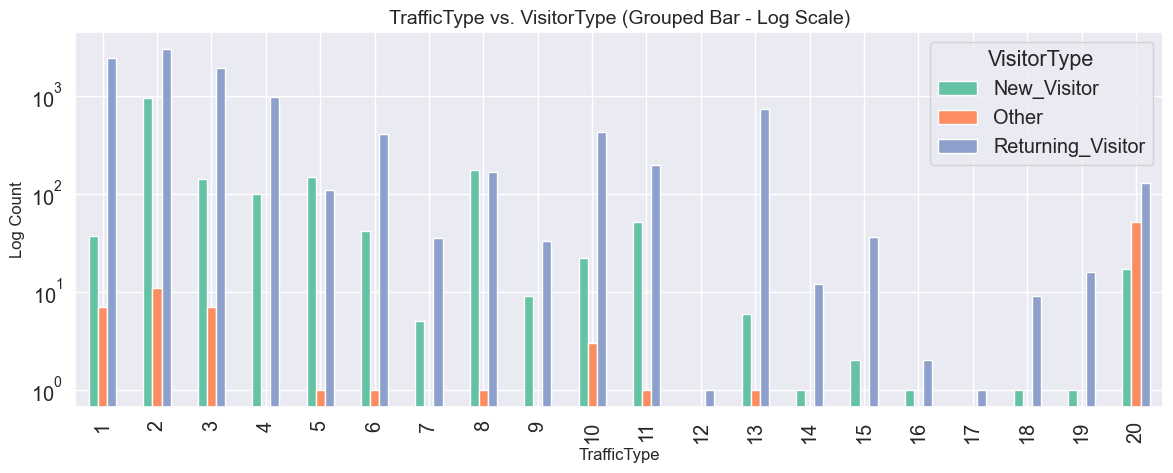

In [37]:
palette = sns.color_palette("Set2", len(Ol_shop_data['VisitorType'].unique()))

grouped_data = Ol_shop_data.groupby(['TrafficType', 'VisitorType']).size().unstack(fill_value=0)

ax = grouped_data.plot(kind='bar', stacked=False, figsize=(12, 5), color=palette)
ax.set_yscale('log')  # Apply log scale to y-axis
plt.title("TrafficType vs. VisitorType (Grouped Bar - Log Scale)", fontsize=14)
plt.xlabel("TrafficType", fontsize=12)
plt.ylabel("Log Count", fontsize=12)
plt.legend(title="VisitorType")
plt.tight_layout()
plt.show()


#### Bivariate Analysis: `TrafficType` vs. `VisitorType`

- **Plot Overview:**  
  - This grouped bar chart shows how different **traffic sources (`TrafficType`)** are distributed across **visitor types** (`New_Visitor`, `Returning_Visitor`, `Other`).  
  - The y-axis is in **logarithmic scale**, highlighting both high and low-frequency categories across a wide count range.

- **Pattern Observed:**  
  - **Returning Visitors** consistently dominate most traffic types — especially **Types 1, 2, 3, 4, and 5**, with Type 2 showing the highest count overall.  
  - **New Visitors** also appear frequently in **Types 1, 2, and 3**, indicating these channels are effective for both returning and new users.  
  - **Type 13 and Type 20** show an interesting **presence of ‘Other’** visitor types, standing out from the otherwise minimal contribution of this group.

- **Logarithmic Insight:**  
  - Log scale highlights stark differences between visitor types and traffic sources.  
  - While Returning Visitors often outnumber others by factors of **10 to 100**, some traffic types (like 6–12, 15–19) have **balanced but low** counts across all visitor categories.

- **Conclusion:**  
  - Certain traffic types (e.g., 2, 1, 3) are **key channels for returning and new users alike**, while others may bring **niche or rare visitors**.  
  - This can inform targeted marketing — e.g., **retain Returning Visitors** through channels like Type 2, and **acquire New Visitors** via Types 1 and 3.  
  - It may also help to investigate **anomalous or rare traffic sources** like 13 and 20 to understand what attracts the “Other” visitor group.

#### Region vs. OperatingSystems

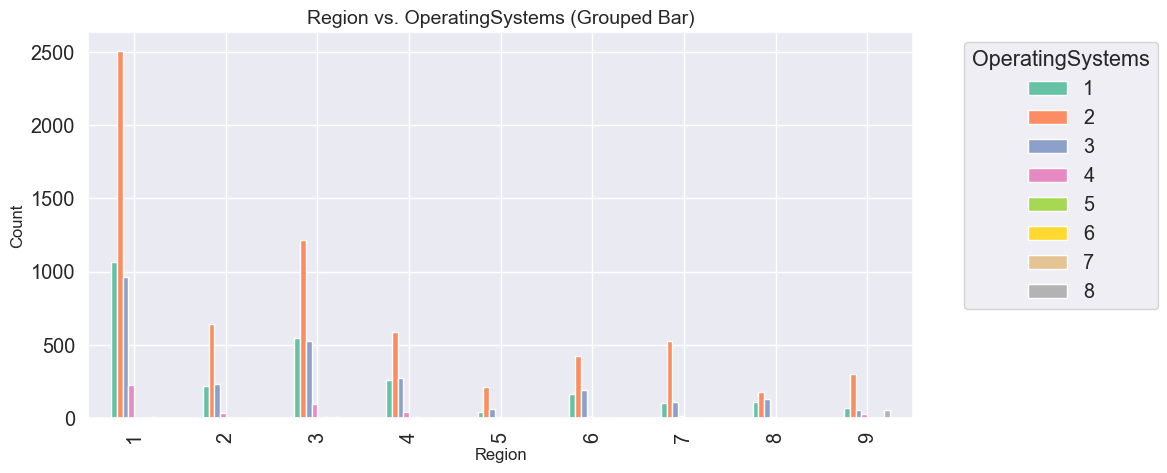

In [38]:
# Set font scale
sns.set(font_scale=1.3)

# Create a color palette based on the number of unique OS values
palette = sns.color_palette("Set2", len(Ol_shop_data['OperatingSystems'].unique()))

# Group the data by Region and OperatingSystems
grouped_data = Ol_shop_data.groupby(['Region', 'OperatingSystems']).size().unstack(fill_value=0)

# Plot grouped bar chart (non-stacked)
ax = grouped_data.plot(kind='bar', stacked=False, figsize=(12, 5), color=palette)
plt.title("Region vs. OperatingSystems (Grouped Bar)", fontsize=14)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="OperatingSystems", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


#### Bivariate Analysis: `Region` vs. `OperatingSystems`

- **Plot Overview:**  
  - This grouped bar chart shows the distribution of **operating systems (OS)** used across different **geographical regions**.  
  - Each group of bars represents a region, and each color corresponds to a specific OS category (1 through 8).

- **Pattern Observed:**  
  - **Region 1** is the most active and **diverse in OS usage**, with **OS 2** being the most dominant, followed by OS 1 and OS 3.  
  - Regions **2 and 3** also have significant user counts, with a similar dominance pattern of **OS 2 > OS 1 ≈ OS 3**.  
  - In **all regions**, **OS 2** consistently has the **highest count**, indicating it is the most commonly used platform across the board.

- **Less Frequent OS Types:**  
  - **OS 4 through OS 8** have **relatively low counts**, especially in smaller regions.  
  - Their presence is minimal or nearly absent in **Regions 5 through 9**, indicating these OSs are either less supported or less preferred in those locations.

- **Conclusion:**  
  - There is a clear **preference for OS 2** across all regions, making it a potential focus for platform-specific optimizations.  
  - **Region 1** stands out as the most active and diverse in terms of OS usage, potentially offering broader testing or targeting opportunities.  
  - Minimal usage of **rare OS categories (5–8)** could justify deprioritizing support or analytics for them.

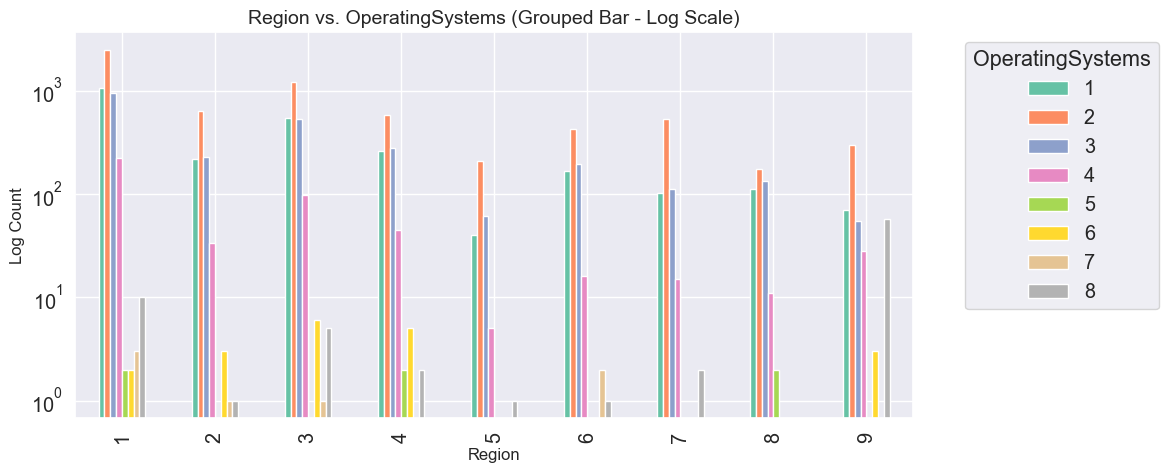

In [39]:
# Set font scale
sns.set(font_scale=1.3)

# Create a color palette based on the number of unique OS values
palette = sns.color_palette("Set2", len(Ol_shop_data['OperatingSystems'].unique()))

# Group the data by Region and OperatingSystems
grouped_data = Ol_shop_data.groupby(['Region', 'OperatingSystems']).size().unstack(fill_value=0)

# Plot grouped bar chart (non-stacked) with log scale
ax = grouped_data.plot(kind='bar', stacked=False, figsize=(12, 5), color=palette)
ax.set_yscale('log')  # Apply log scale to y-axis

plt.title("Region vs. OperatingSystems (Grouped Bar - Log Scale)", fontsize=14)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Log Count", fontsize=12)
plt.legend(title="OperatingSystems", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


#### Bivariate Analysis: `Region` vs. `OperatingSystems` (Log Scale)

- **Plot Overview:**  
  - This grouped bar chart uses a **logarithmic y-axis** to display the distribution of **operating system usage** across different **regions**.  
  - It enables better visibility of both **high-frequency OS types** (e.g., OS 2, OS 1) and **rare OS types** (e.g., OS 6–8) by compressing large value differences.

- **Key Observations:**  
  - **OS 2** remains the **most used operating system** in every region, often by a significant margin — especially in **Regions 1, 3, and 4**.  
  - **OS 1 and OS 3** also show high usage in several regions, consistently appearing as the **second or third most common** systems.
  - **OS 4** has a moderate presence, while **OS 5 through OS 8** are used **very infrequently**, typically below 10 in log count (i.e., fewer than 10 users in some regions).

- **Regional Patterns:**  
  - **Region 1** exhibits the **broadest OS diversity**, with substantial usage across all OS types.  
  - **Regions 2, 3, and 4** show similar diversity but with fewer users on the rare OS types.  
  - In **Regions 5 to 9**, the usage of rarer operating systems (especially OS 6, 7, 8) becomes **almost negligible**, with some regions showing zero or near-zero bars.

- **Conclusion:**  
  - This log-scale view reinforces the dominance of **OS 2**, followed by OS 1 and OS 3, across **all regions**.  
  - **Rare operating systems** account for **very low engagement**, especially in lower-traffic regions, indicating limited platform dependency.  
  - For resource optimization, regions with fewer users and negligible OS variation could be **deprioritized for cross-platform testing**.

#### Month vs. VisitorType

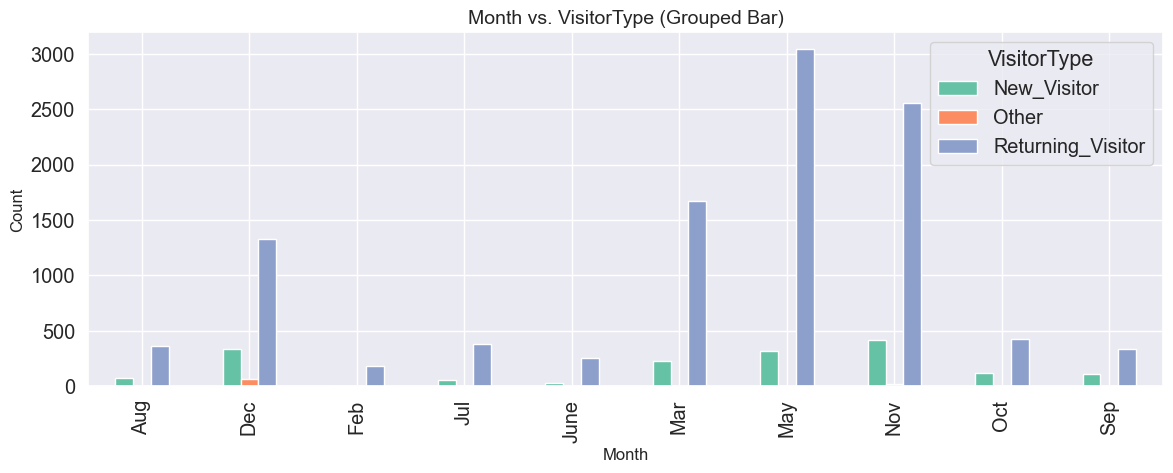

In [40]:
palette = sns.color_palette("Set2", len(Ol_shop_data['VisitorType'].unique()))

grouped_data = Ol_shop_data.groupby(['Month', 'VisitorType']).size().unstack(fill_value=0)

grouped_data.plot(kind='bar', stacked=False, figsize=(12, 5), color=palette)
plt.title("Month vs. VisitorType (Grouped Bar)", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="VisitorType")
plt.tight_layout()
plt.show()


#### Bivariate Analysis: `Month` vs. `VisitorType`

- **Plot Overview:**  
  - This grouped bar chart illustrates how **visitor types** (`Returning_Visitor`, `New_Visitor`, `Other`) are distributed across different **months**.  
  - It provides a view of seasonal user engagement trends segmented by visitor category.

- **Key Observations:**  
  - **Returning Visitors dominate every month**, especially in **May, November, and March**, which show the highest total traffic overall.  
  - **May** leads with the **highest number of returning visitors**, followed by **November** and **March**, possibly aligning with promotional or seasonal events.  
  - **New Visitors** show more balanced monthly distribution, peaking in **November and May**, suggesting effective acquisition campaigns or higher organic traffic during these periods.

- **Month-wise Insights:**  
  - **December** shows a notable spike in **returning visitors**, though with fewer new visitors than November.  
  - **February, June, and July** show relatively low activity across all visitor types.  
  - The **‘Other’** visitor type remains **consistently low** in all months, almost negligible.

- **Conclusion:**  
  - The data suggests **seasonal user behavior**, with **strong returning visitor traffic in late Q2 (May) and Q4 (Nov–Dec)**, possibly due to sales periods or holidays.  
  - **New visitor acquisition** also aligns with these high-traffic months, making them key opportunities for **marketing and re-engagement campaigns**.  
  - Low-traffic months like **June–July** could be optimized or targeted with special promotions to boost engagement.

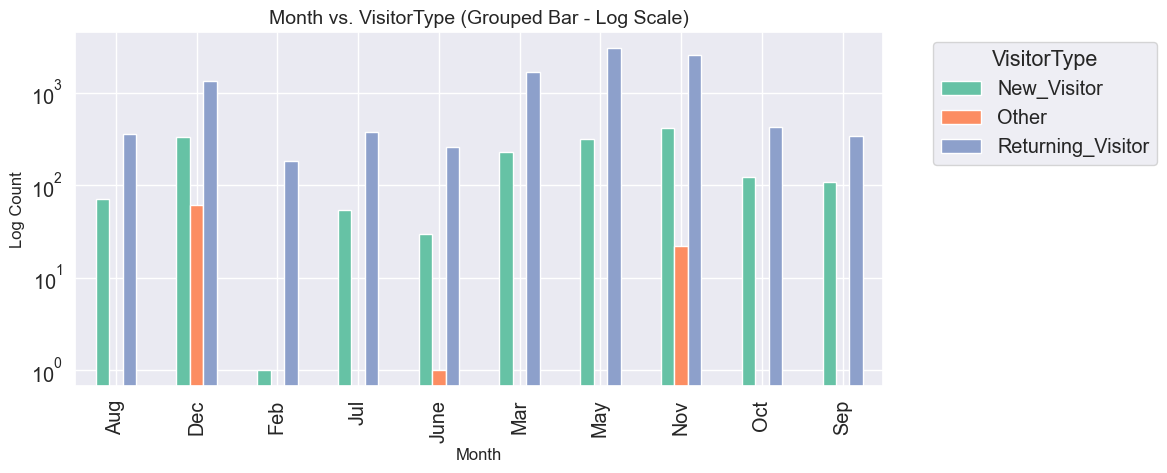

In [41]:
# Set font scale
sns.set(font_scale=1.3)

# Create a custom color palette for VisitorType categories
palette = sns.color_palette("Set2", len(Ol_shop_data['VisitorType'].unique()))

# Group the data by Month and VisitorType
grouped_data = Ol_shop_data.groupby(['Month', 'VisitorType']).size().unstack(fill_value=0)

# Plot grouped bar chart with log y-axis
ax = grouped_data.plot(kind='bar', stacked=False, figsize=(12, 5), color=palette)
ax.set_yscale('log')  # Apply log scale to y-axis

plt.title("Month vs. VisitorType (Grouped Bar - Log Scale)", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Log Count", fontsize=12)
plt.legend(title="VisitorType", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


#### Bivariate Analysis: `Month` vs. `VisitorType` (Log Scale)

- **Plot Overview:**  
  - This grouped bar chart displays how **visitor types** (`Returning_Visitor`, `New_Visitor`, `Other`) vary by **month**, with a **logarithmic y-axis** to highlight both large and small differences in session counts.

- **Key Observations:**  
  - **Returning Visitors consistently dominate** every month, particularly in **May**, **November**, and **March**, with counts exceeding 1,000 (log scale confirms orders of magnitude differences).  
  - **New Visitors** show a steady presence throughout the year, with spikes in **May**, **November**, and **December**, suggesting successful acquisition during promotional periods.  
  - The **‘Other’** category is minimal across the board but shows a small bump in **June** and **November**.

- **Logarithmic Insight:**  
  - The log scale reveals finer trends:  
    - Even during **low-traffic months** (e.g., **February**, **June**, **July**), `Returning_Visitor` counts remain consistently higher than other types.  
    - **New Visitors** have more gradual seasonal variation, visible even in lower-activity months due to log scaling.

- **Conclusion:**  
  - **Seasonality clearly affects all visitor types**, with **May and November** being the peak engagement months for both retention and acquisition.  
  - The **log scale** effectively highlights visitor trends even in **low-volume months**, which may be hidden in a standard linear chart.  
  - Insights like these can help in **calendar-based marketing strategies**, such as retargeting returning users and running outreach campaigns for new visitors during high-conversion months.

#### TrafficType vs. Weekend

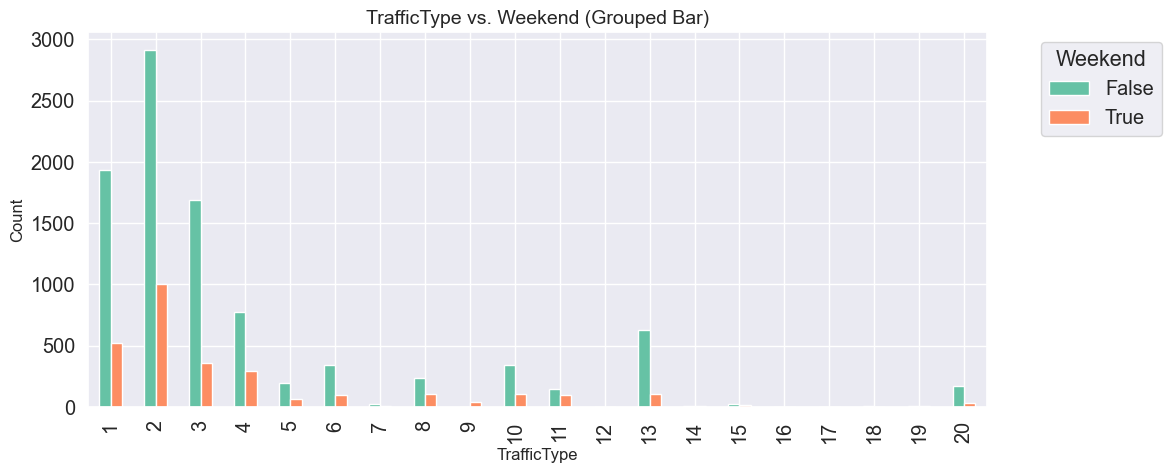

In [42]:
sns.set(font_scale=1.3)

palette = sns.color_palette("Set2", len(Ol_shop_data['Weekend'].unique()))

grouped_data = Ol_shop_data.groupby(['TrafficType', 'Weekend']).size().unstack(fill_value=0)

ax = grouped_data.plot(kind='bar', stacked=False, figsize=(12, 5), color=palette)
plt.title("TrafficType vs. Weekend (Grouped Bar)", fontsize=14)
plt.xlabel("TrafficType", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="Weekend", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


#### Bivariate Analysis: `TrafficType` vs. `Weekend`

- **Plot Overview:**  
  - This grouped bar chart presents how **traffic sources (`TrafficType`)** are distributed across **weekdays and weekends**.  
  - The bars are grouped by traffic type, with separate colors indicating whether the session occurred on a **weekend (`True`) or not (`False`)**.

- **Key Observations:**  
  - **TrafficTypes 1, 2, and 3** account for the **highest volume of sessions** overall, with a clear **weekday dominance**.  
  - **TrafficType 2**, in particular, shows the **largest weekday count**, with close to 3,000 weekday sessions and around 1,000 on weekends.
  - Across nearly all traffic types, **weekday activity (False)** is **significantly higher** than weekend activity (True).

- **Notable Weekend Activity:**  
  - While weekend sessions are generally lower, **TrafficTypes 1 and 2** still maintain **substantial weekend traffic**, suggesting these channels perform consistently throughout the week.
  - A few traffic types (e.g., **13 and 20**) have small but noticeable **weekend spikes**, which could be worth monitoring for niche engagement.

- **Low Activity Types:**  
  - TrafficTypes **14–19** show **minimal usage overall**, with negligible or no presence on weekends.

- **Conclusion:**  
  - The data confirms a strong **weekday bias** in user sessions, with only a few traffic types retaining moderate weekend usage.  
  - **Weekday-focused strategies** should remain central for high-traffic sources like Types 1–3.  
  - For channels with **weekend resilience** (like Type 2), tailored campaigns may sustain engagement even outside typical business hours.

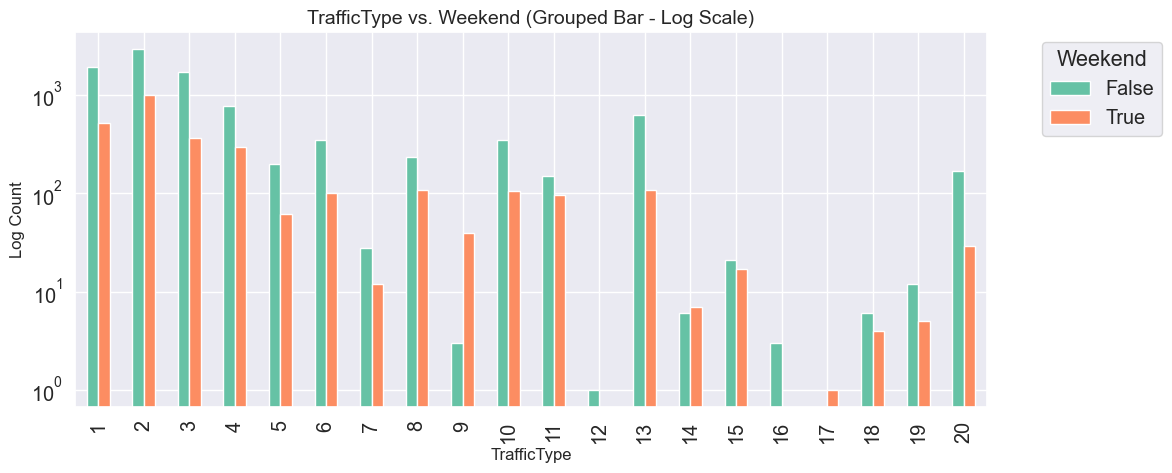

In [43]:
sns.set(font_scale=1.3)

palette = sns.color_palette("Set2", len(Ol_shop_data['Weekend'].unique()))

grouped_data = Ol_shop_data.groupby(['TrafficType', 'Weekend']).size().unstack(fill_value=0)

ax = grouped_data.plot(kind='bar', stacked=False, figsize=(12, 5), color=palette)
ax.set_yscale('log')
plt.title("TrafficType vs. Weekend (Grouped Bar - Log Scale)", fontsize=14)
plt.xlabel("TrafficType", fontsize=12)
plt.ylabel("Log Count", fontsize=12)
plt.legend(title="Weekend", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


#### Bivariate Analysis: `TrafficType` vs. `Weekend`

- **Plot Overview:**  
  - This grouped bar chart presents how **traffic sources (`TrafficType`)** are distributed across **weekdays and weekends**.  
  - The bars are grouped by traffic type, with separate colors indicating whether the session occurred on a **weekend (`True`) or not (`False`)**.

- **Key Observations:**  
  - **TrafficTypes 1, 2, and 3** account for the **highest volume of sessions** overall, with a clear **weekday dominance**.  
  - **TrafficType 2**, in particular, shows the **largest weekday count**, with close to 3,000 weekday sessions and around 1,000 on weekends.
  - Across nearly all traffic types, **weekday activity (False)** is **significantly higher** than weekend activity (True).

- **Notable Weekend Activity:**  
  - While weekend sessions are generally lower, **TrafficTypes 1 and 2** still maintain **substantial weekend traffic**, suggesting these channels perform consistently throughout the week.
  - A few traffic types (e.g., **13 and 20**) have small but noticeable **weekend spikes**, which could be worth monitoring for niche engagement.

- **Low Activity Types:**  
  - TrafficTypes **14–19** show **minimal usage overall**, with negligible or no presence on weekends.

- **Conclusion:**  
  - The data confirms a strong **weekday bias** in user sessions, with only a few traffic types retaining moderate weekend usage.  
  - **Weekday-focused strategies** should remain central for high-traffic sources like Types 1–3.  
  - For channels with **weekend resilience** (like Type 2), tailored campaigns may sustain engagement even outside typical business hours.

#### OperatingSystems vs. Weekend

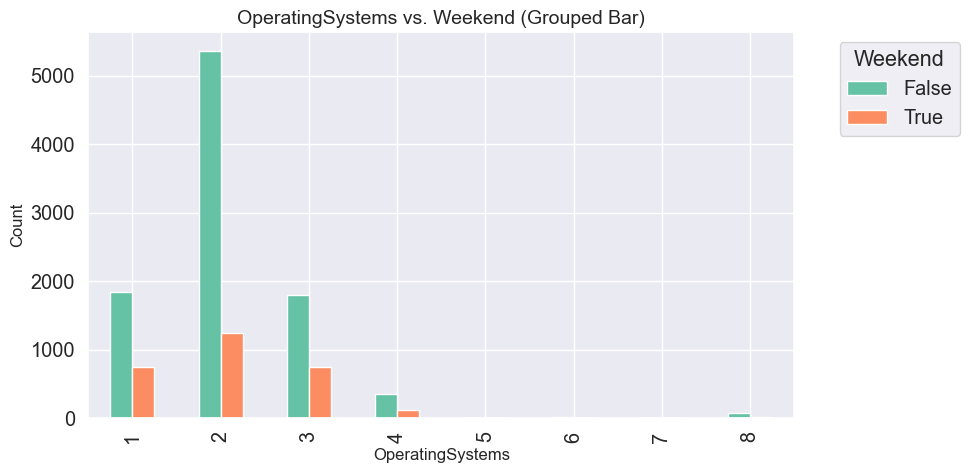

In [44]:
sns.set(font_scale=1.3)

palette = sns.color_palette("Set2", len(Ol_shop_data['Weekend'].unique()))

grouped_data = Ol_shop_data.groupby(['OperatingSystems', 'Weekend']).size().unstack(fill_value=0)

ax = grouped_data.plot(kind='bar', stacked=False, figsize=(10, 5), color=palette)
plt.title("OperatingSystems vs. Weekend (Grouped Bar)", fontsize=14)
plt.xlabel("OperatingSystems", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="Weekend", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


#### Bivariate Analysis: `OperatingSystems` vs. `Weekend`

- **Plot Overview:**  
  - This grouped bar chart displays how users across different **operating systems (OS 1 to 8)** behave on **weekdays vs. weekends**.  
  - Each bar group represents an operating system, split by **weekend status** (`True` for weekend, `False` for weekday).

- **Key Observations:**  
  - **OS 2** dominates overall usage, with over **5,000 weekday sessions** and around **1,200 on weekends**, making it the most popular OS across both time periods.  
  - **OS 1 and OS 3** are the next most common, each showing **roughly double the number of weekday users compared to weekends**, indicating a consistent weekday preference.
  - **OS 4** sees some activity, but still skewed toward weekdays.

- **Minimal or No Usage:**  
  - **OS types 5 to 7** exhibit **no visible bar activity**, implying **zero or negligible usage** regardless of the day.  
  - **OS 8** shows minimal weekday usage and almost no weekend interaction.

- **Conclusion:**  
  - **Weekday dominance** is clear across all major operating systems, particularly **OS 2, OS 1, and OS 3**.  
  - These OS categories may reflect desktop/laptop environments with higher weekday utility (e.g., work or school-related usage).  
  - The negligible weekend activity on rarer OS types (5–8) may justify **lower prioritization** for optimization or cross-platform support.

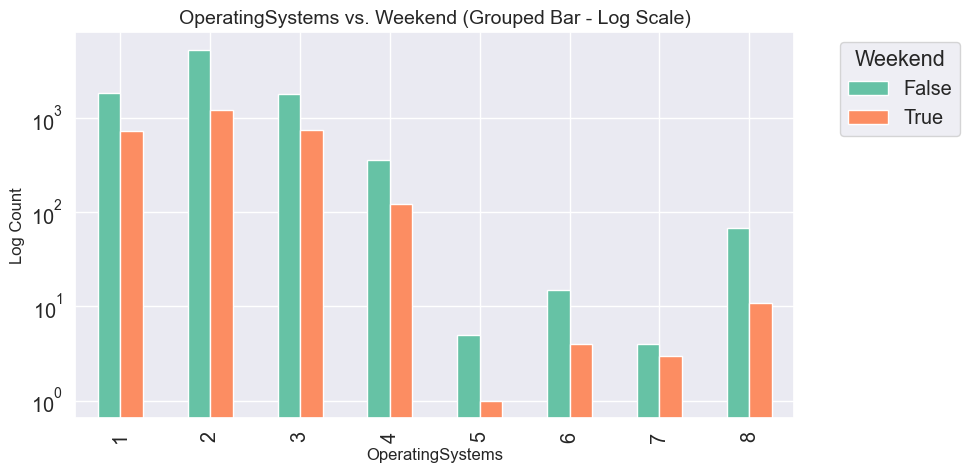

In [45]:
sns.set(font_scale=1.3)

palette = sns.color_palette("Set2", len(Ol_shop_data['Weekend'].unique()))

grouped_data = Ol_shop_data.groupby(['OperatingSystems', 'Weekend']).size().unstack(fill_value=0)

ax = grouped_data.plot(kind='bar', stacked=False, figsize=(10, 5), color=palette)
ax.set_yscale('log')
plt.title("OperatingSystems vs. Weekend (Grouped Bar - Log Scale)", fontsize=14)
plt.xlabel("OperatingSystems", fontsize=12)
plt.ylabel("Log Count", fontsize=12)
plt.legend(title="Weekend", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


#### Bivariate Analysis: `OperatingSystems` vs. `Weekend` (Log Scale)

- **Plot Overview:**  
  - This grouped bar chart compares the usage of different **operating systems (1–8)** between **weekdays (`False`)** and **weekends (`True`)**, using a **logarithmic y-axis** to highlight both common and rare OS types across a wide range of counts.

- **Key Observations:**  
  - **OS 2** remains the most used operating system across both weekdays and weekends, with weekday usage exceeding 3,000 and weekend usage above 1,000.  
  - **OS 1 and OS 3** also show strong presence, especially on weekdays, followed by moderate usage on weekends.  
  - The **log scale reveals subtler differences** between weekday and weekend behavior for lower-frequency OS types that might be overlooked in a linear plot.

- **Rare OS Insights:**  
  - OS types **5 through 8**, previously hard to compare, show **visible but low counts**:
    - **OS 5 and OS 6**: used primarily on weekdays, with some minor weekend interaction.
    - **OS 7**: almost equal but very low usage on both days.
    - **OS 8**: slightly higher weekday usage, and still noticeable on weekends compared to others in the same tier.

- **Conclusion:**  
  - While high-traffic operating systems like **OS 1–3** still dominate, the **log scale helps highlight rare system usage** and confirms that even low-usage OSs maintain some weekend engagement.  
  - This information may help in **prioritizing platform support**, especially for long-tail systems that would be missed on linear plots.  
  - Campaigns targeting **weekend users** should still consider **OS 2 and 3**, given their cross-day presence.

#### TrafficType vs. VisitorType

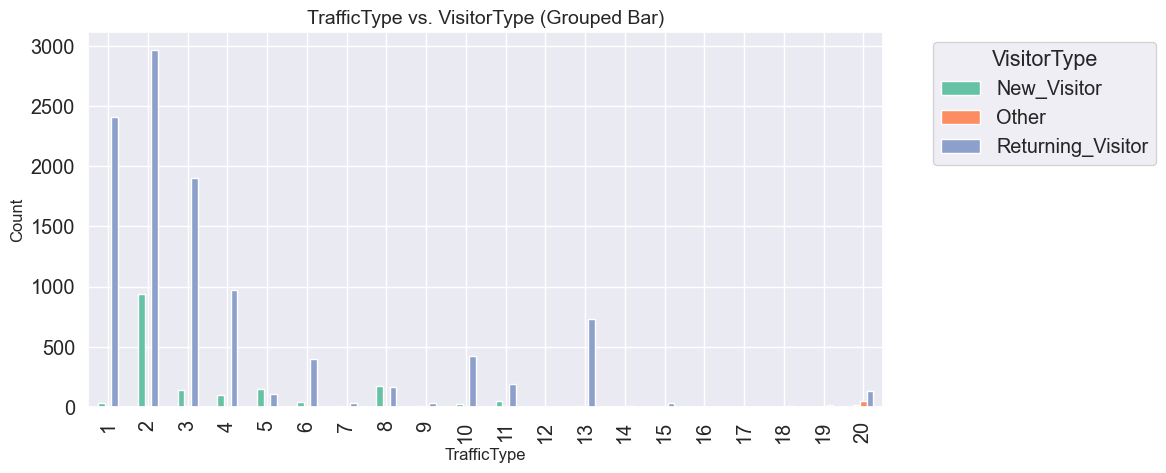

In [46]:
sns.set(font_scale=1.3)

palette = sns.color_palette("Set2", len(Ol_shop_data['VisitorType'].unique()))

grouped_data = Ol_shop_data.groupby(['TrafficType', 'VisitorType']).size().unstack(fill_value=0)

ax = grouped_data.plot(kind='bar', stacked=False, figsize=(12, 5), color=palette)
plt.title("TrafficType vs. VisitorType (Grouped Bar)", fontsize=14)
plt.xlabel("TrafficType", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="VisitorType", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


#### Bivariate Analysis: `TrafficType` vs. `VisitorType`

- **Plot Overview:**  
  - This grouped bar chart illustrates how **different types of website traffic (`TrafficType`)** are associated with various **visitor categories** — `Returning_Visitor`, `New_Visitor`, and `Other`.

- **Key Observations:**  
  - **Returning Visitors dominate across nearly all traffic types**, especially for **TrafficTypes 2, 3, and 1**, indicating that these channels are effective at bringing back previous users.
    - **TrafficType 2** stands out as the highest contributor to overall traffic, primarily composed of returning visitors with some new visitors as well.
  - **New Visitors** appear prominently only in **TrafficTypes 2 and 3**, suggesting these sources may be acquisition-focused or linked to first-time marketing efforts.
  - **‘Other’ visitors** have minimal presence across all traffic types, except for a slight count in **TrafficType 20**.

- **Lower Engagement Channels:**  
  - **TrafficTypes 6 through 20** exhibit very low traffic volumes, regardless of visitor type.
  - However, **TrafficTypes 10, 11, and 13** still show minor engagement among returning users, which might point to niche or specialized campaigns.

- **Conclusion:**  
  - The data strongly highlights **TrafficTypes 1–4** as the **most influential traffic sources**, especially for **retaining existing users**.  
  - For **visitor acquisition strategies**, TrafficTypes **2 and 3** may be key candidates for optimization and scaling.  
  - TrafficTypes with consistently low engagement may benefit from deeper audit or reallocation of resources.

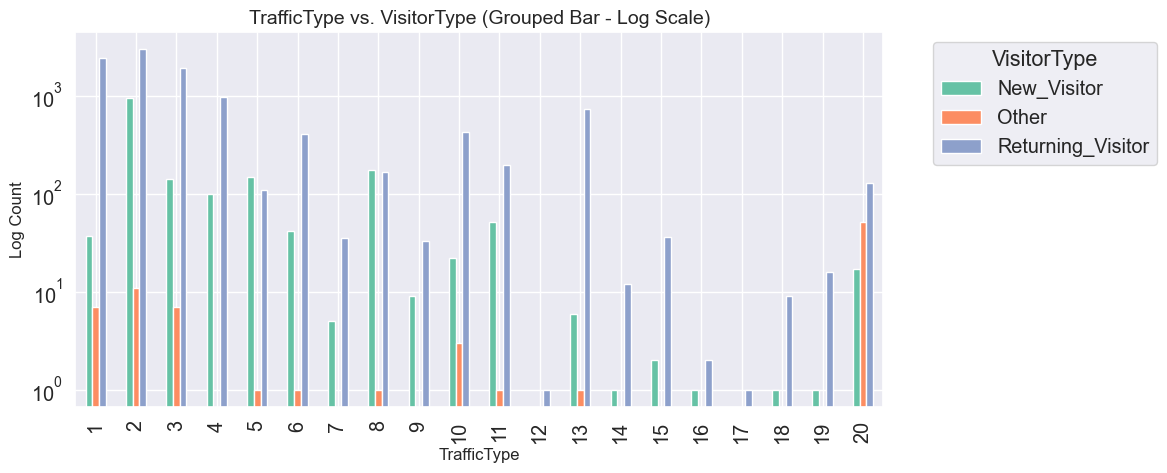

In [47]:
sns.set(font_scale=1.3)

palette = sns.color_palette("Set2", len(Ol_shop_data['VisitorType'].unique()))

grouped_data = Ol_shop_data.groupby(['TrafficType', 'VisitorType']).size().unstack(fill_value=0)

ax = grouped_data.plot(kind='bar', stacked=False, figsize=(12, 5), color=palette)
ax.set_yscale('log')
plt.title("TrafficType vs. VisitorType (Grouped Bar - Log Scale)", fontsize=14)
plt.xlabel("TrafficType", fontsize=12)
plt.ylabel("Log Count", fontsize=12)
plt.legend(title="VisitorType", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


#### Bivariate Analysis: `TrafficType` vs. `VisitorType` (Log Scale)

- **Plot Overview:**  
  - This grouped bar chart shows how **visitor types** (`Returning_Visitor`, `New_Visitor`, `Other`) are distributed across various **traffic sources** (`TrafficType`) using a **logarithmic scale** for the y-axis to account for wide disparities in volume.

- **Key Observations:**  
  - **Returning Visitors are the majority** across nearly all traffic types — especially **TrafficTypes 2, 3, 1, and 4**, where their counts reach thousands.  
  - **New Visitors** also show significant volume in **TrafficTypes 2, 3, and 4**, with lower but consistent presence in types like 5, 6, 8, and 10.
  - The **log scale uncovers patterns** among lower-volume traffic types (e.g., 12–20) that would otherwise be hidden in a linear plot:
    - Even niche traffic types like **13 and 20** show meaningful returning visitor counts.
    - **TrafficType 20** uniquely shows a noticeable spike in the `Other` visitor category — rare compared to other types.

- **VisitorType 'Other':**  
  - Mostly flat across traffic types, but **clearly visible** on the log scale in **Types 1, 2, 3, 11, and 20**, suggesting sporadic but real engagement.

- **Conclusion:**  
  - The **log scale effectively highlights long-tail behavior**, confirming that while most sessions come from a few dominant traffic sources, even low-frequency channels contribute to diversity in visitor types.  
  - The dominance of **Returning_Visitor** across all traffic types points to strong retention and repeat engagement.  
  - Channels like **TrafficType 20** could be candidates for deeper inspection, especially due to unique engagement patterns among all visitor categories.

### Bivariate Analysis:  Numerical Variable Vs Categorical Variable:

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import functools as _ft
if not getattr(sns, "_palette_hue_patch", False):
    for _f in ("countplot","barplot","boxplot","violinplot","stripplot","swarmplot","pointplot","boxenplot"):
        _o = getattr(sns, _f, None)
        if _o is None:
            continue
        def _w(*a, _o=_o, **k):
            if k.get("palette") is not None and "hue" not in k:
                if isinstance(k.get("palette"), str) and ("x" in k or "y" in k):
                    k["hue"] = k.get("x", k.get("y"))
                    k.setdefault("legend", False)
                else:
                    k.pop("palette", None)
            return _o(*a, **k)
        setattr(sns, _f, _ft.wraps(_o)(_w))
    sns._palette_hue_patch = True

def plot_box(categorical_col, numerical_col, data, palette='Pastel1'):
    """
    Plots a boxplot of a numerical variable grouped by a categorical variable.
    Takes two column names, dataframe, palette is optional
    Returns nothing. Only displays a box plot.
    """
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=categorical_col, y=numerical_col, data=data, palette=palette)
    plt.title(f'{numerical_col} by {categorical_col}', fontsize=14)
    plt.xlabel(categorical_col, fontsize=12)
    plt.ylabel(numerical_col, fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


### 1.  VisitorType vs. Numerical Variables

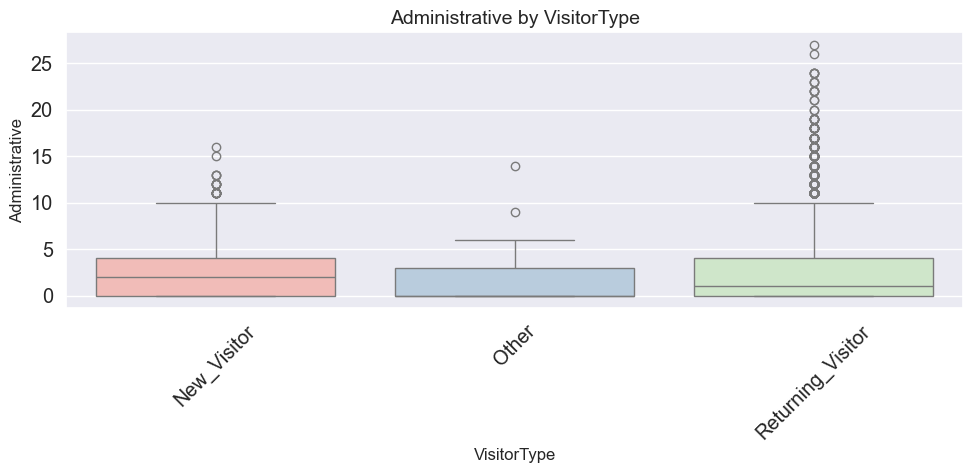

In [49]:
plot_box('VisitorType', 'Administrative', Ol_shop_data)

#### Bivariate Analysis: `Administrative` Pages by `VisitorType`

- **Plot Overview:**  
  - This box plot compares the number of **Administrative pages viewed** across three types of visitors: `New_Visitor`, `Returning_Visitor`, and `Other`.

- **Key Observations:**
  - All three visitor types show a **median of 0 or very low administrative page views**, suggesting that many users do not engage with administrative content during their session.
  - **Returning Visitors** exhibit the **widest spread** in administrative page activity:
    - A larger number of **high-value outliers**, with some viewing more than **25 pages**, indicates greater engagement depth or possibly repeated attempts to interact with the same section.
  - **New Visitors** have a slightly lower range than returning users but still show several outliers above 10 pages.
  - **‘Other’ visitors** have a narrower IQR (interquartile range) and fewer outliers, suggesting more consistent — and limited — interaction with administrative content.

- **Conclusion:**
  - The **Administrative section is most heavily used by Returning Visitors**, which is expected as they may be returning to complete tasks or revisit specific areas.  
  - **New Visitors**, though slightly less active, still show interest in administrative content.  
  - The **low median across all groups** could indicate that administrative content is either not central to most sessions or may not be easily accessible.

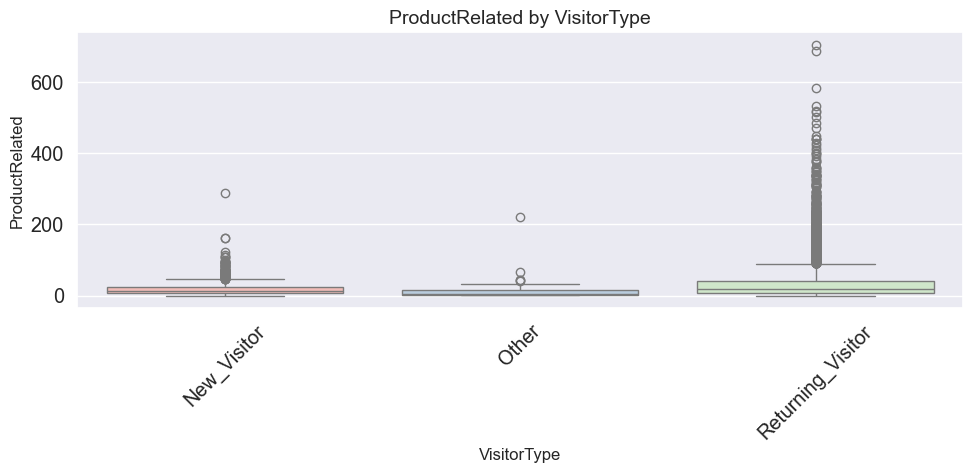

In [50]:
plot_box('VisitorType', 'ProductRelated', Ol_shop_data)

#### Bivariate Analysis: `ProductRelated` Pages by `VisitorType`

- **Plot Overview:**  
  - This box plot visualizes the distribution of **product-related page views** among different visitor types: `New_Visitor`, `Returning_Visitor`, and `Other`.

- **Key Observations:**
  - **Returning Visitors** show the **highest engagement** with product-related content:
    - A visibly wider interquartile range (IQR) and numerous **extreme outliers**, some exceeding **700 pages**, point to highly active or repeated browsing sessions.
  - **New Visitors** also engage with product pages, but typically to a **lesser extent**:
    - Their IQR is narrower, and most sessions involve fewer than 20 product page views.
    - Outliers go up to around **300**, though these are rare.
  - **Other Visitors** exhibit the **least interaction** overall, with a compact box and very few high-value outliers.
  
- **General Trend:**
  - The **median** product-related views are relatively low for all groups, yet the **density and scale of outliers** for `Returning_Visitor` suggest this segment includes the most invested users.
  
- **Conclusion:**
  - **Product exploration is a key behavior of returning visitors**, likely indicating shopping intent or comparison behavior.  
  - **New visitors** may be browsing casually or for the first time, showing moderate interaction.  
  - The **'Other' group remains passive**, possibly bots or miscategorized users.

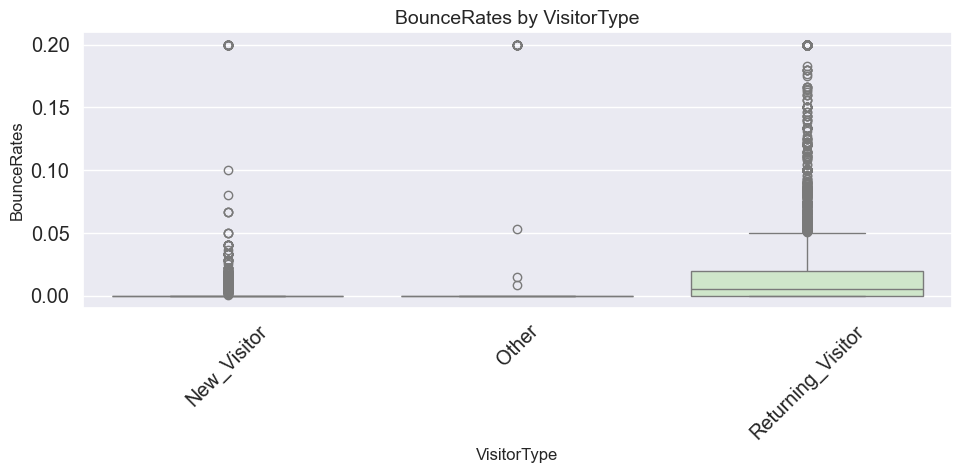

In [51]:
plot_box('VisitorType', 'BounceRates', Ol_shop_data)

#### Bivariate Analysis: `BounceRates` by `VisitorType`

- **Plot Overview:**  
  - This box plot illustrates how **bounce rates** (the percentage of visits in which a user leaves after viewing only one page) vary across `New_Visitor`, `Returning_Visitor`, and `Other`.

- **Key Observations:**
  - **Returning Visitors** display the **widest spread in bounce rates**, with:
    - A higher **median bounce rate**, around 5%.
    - A large number of **outliers**, extending all the way to the maximum of **0.2 (20%)**, suggesting that some returning visitors leave quickly despite past engagement.
  - **New Visitors** have an extremely **low median and IQR**, with almost all values clustered around 0.
    - A few outliers are present but significantly lower than in the returning group.
  - **Other Visitors** show a **very low and flat distribution**, with minimal variation and very few bounce events.

- **General Trend:**
  - The plot suggests that **most users do not bounce**, especially in the `New_Visitor` and `Other` categories.
  - Surprisingly, **returning visitors exhibit higher bounce variability**, which may indicate either dissatisfaction or a quick revisit behavior (e.g., to check order status, etc.).

- **Conclusion:**
  - Bounce behavior appears more prominent among **Returning Visitors**, potentially due to targeted visits or unmet expectations.  
  - **New and Other Visitors are less likely to bounce**, which could either reflect initial exploration or limitations in bounce measurement (e.g., bot activity in 'Other').

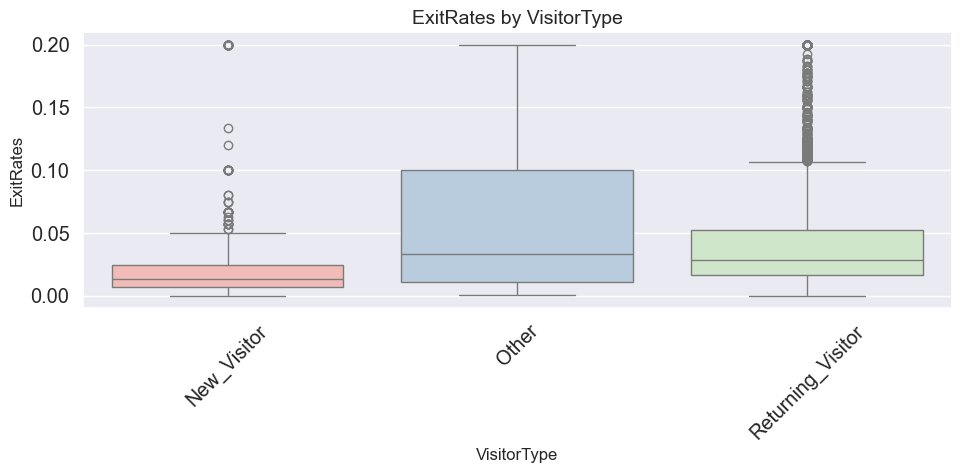

In [52]:
plot_box('VisitorType', 'ExitRates', Ol_shop_data)

#### Bivariate Analysis: `ExitRates` by `VisitorType`

- **Plot Overview:**  
  - This box plot explores how the **exit rate** (the ratio of exits from a specific page to the total views of that page) varies for different visitor categories.

- **Key Observations:**
  - **Returning Visitors** have a **higher median exit rate**, around 5%, with a **wide range** and several **high outliers** close to 0.2 (20%).
    - Indicates that many returning visitors may **leave after viewing a few key pages**, possibly due to goal completion or dissatisfaction.
  - **Other Visitors** show the **widest interquartile range (IQR)**, spanning nearly the full range from 0 to 0.2.
    - This suggests **inconsistent behavior**, potentially from bots, unclassified traffic, or irregular user activity.
  - **New Visitors** exhibit the **lowest exit rates overall**, with a tight IQR centered around 2%, and relatively fewer outliers.
    - Indicates that new users are **more likely to navigate further** into the site before exiting.

- **General Trend:**
  - **Returning Visitors and 'Other' users are more prone to exit behavior**, whereas **new visitors tend to stay longer**, possibly exploring more pages or engaging more on their first visit.

- **Conclusion:**
  - **Exit rate behavior is most stable among New Visitors**, while **Returning and Other Visitors show more variance**, possibly linked to different user intents (quick revisit, session timeout, bots, etc.).

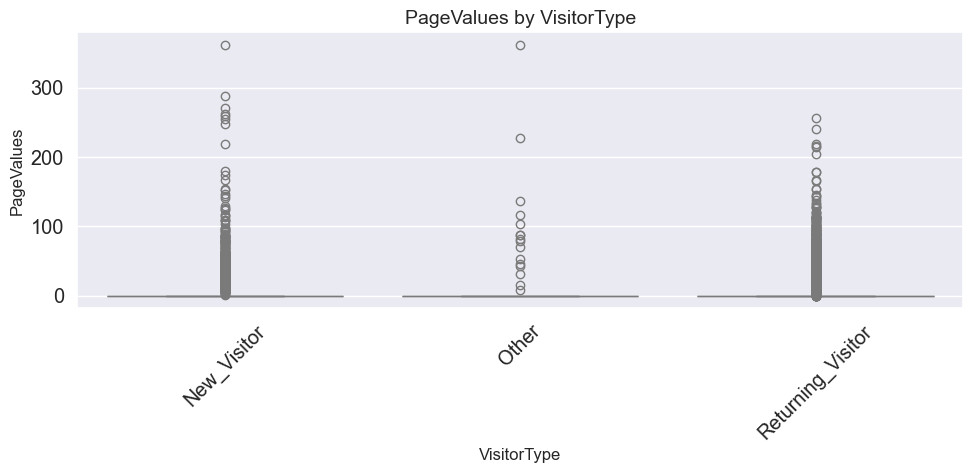

In [53]:
plot_box('VisitorType', 'PageValues', Ol_shop_data)

#### Bivariate Analysis: `PageValues` by `VisitorType`

- **Plot Overview:**  
  - This box plot visualizes how **PageValues** (an e-commerce metric indicating the average value of a page visited by users before completing a transaction) differs across visitor types.

- **Key Observations:**
  - The **majority of values** are clustered at **0** for all visitor types, indicating that **most sessions did not lead to significant transaction activity** or purchase-related page paths.
  - Despite the dominance of zero values, there are notable **positive outliers** in each category:
    - **New Visitors** show the **highest outliers**, with values reaching up to ~350, suggesting **a few new users generated substantial revenue**, potentially from first-time purchases.
    - **Returning Visitors** also show strong positive outliers, though **less extreme**, possibly indicating **consistent but moderate value generation** across sessions.
    - **Other Visitors** display fewer but still notable outliers, with max values comparable to other categories, suggesting occasional high-value activity.

- **General Trend:**
  - The data is **heavily right-skewed**, with a **large mass at zero** and a **long tail of positive values**, highlighting that **value-generating behavior is rare but impactful**.
  - **All visitor types** are capable of generating high page values, though **New Visitors may yield the highest per-session gains** in fewer instances.

- **Conclusion:**
  - While most users do not contribute to high page values, **certain sessions—especially from new users—have a disproportionately high value**, which could be crucial for targeting marketing or personalization strategies.

### 2. Weekend vs. Numerical Variables

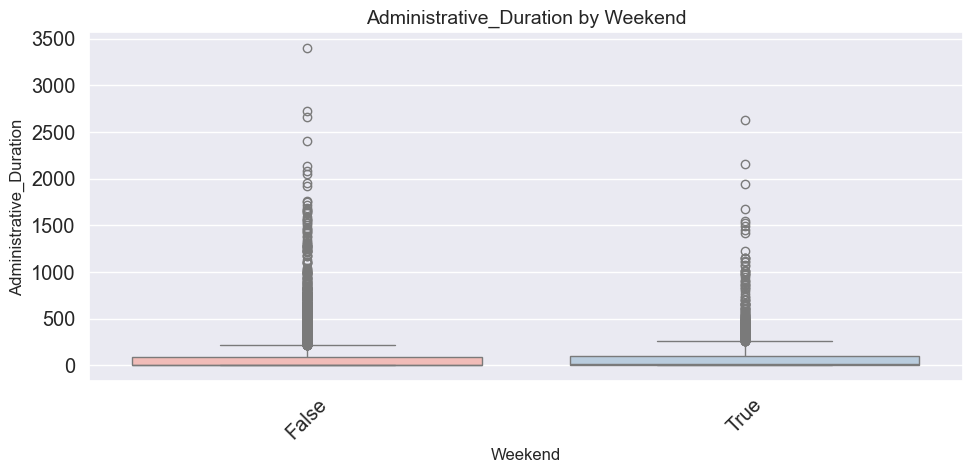

In [54]:
plot_box('Weekend', 'Administrative_Duration', Ol_shop_data)

#### Bivariate Analysis: `Administrative_Duration` by `Weekend`

- **Plot Overview:**  
  - This box plot compares the **time spent on administrative pages** (in seconds) between sessions that occurred on **weekdays (`False`)** and those on **weekends (`True`)**.

- **Key Observations:**
  - The **median duration** is slightly **higher during weekends**, suggesting users may spend more time on administrative-related tasks during their free time.
  - **Outliers are present** in both groups, but sessions during **weekdays** tend to have **slightly more extreme outliers** (e.g., durations above 3000 seconds).
  - The **interquartile range (IQR)** is wider for **weekend sessions**, indicating **greater variability** in how long users spend on administrative pages during weekends.

- **Distribution Characteristics:**
  - Both distributions are **right-skewed**, with a large number of low-duration sessions and a **long tail** extending into high-duration outliers.
  - While **most users** spend **less than ~200 seconds**, a **few sessions exceed 1000+ seconds**, showing intense engagement in rare cases.

- **Conclusion:**
  - Users tend to **engage more deeply with administrative content on weekends**, though high-duration outliers occur throughout the week.
  - These insights could help **schedule administrative-related promotions or support availability** more strategically depending on user engagement patterns.

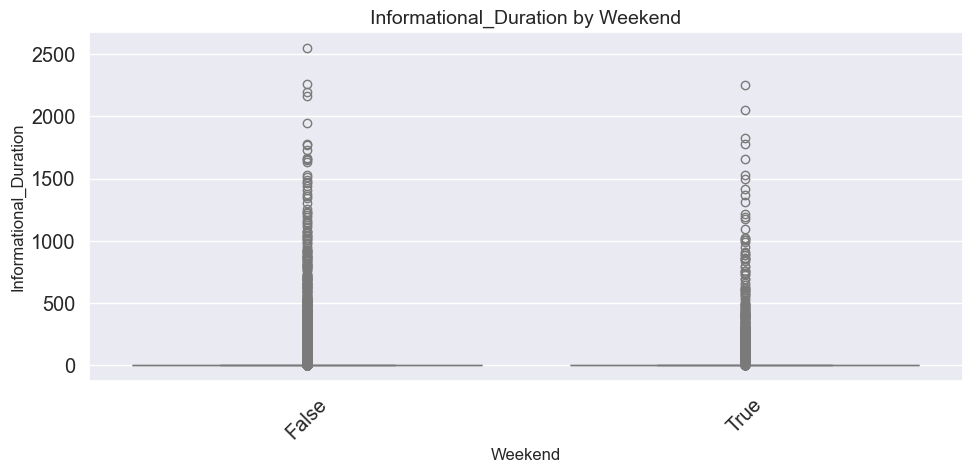

In [55]:
plot_box('Weekend', 'Informational_Duration', Ol_shop_data)

#### Bivariate Analysis: `Informational_Duration` by `Weekend`

- **Plot Overview:**  
  - This box plot compares the **time spent on informational pages** (in seconds) between sessions that occurred on **weekdays (`False`)** and **weekends (`True`)**.

- **Key Observations:**
  - Both weekday and weekend sessions show a **very compressed interquartile range (IQR)** near zero, indicating that **most sessions involve little to no time on informational pages**.
  - Despite the low median, there are **numerous high-value outliers** in both groups, with durations extending beyond **2000+ seconds**.
  - There is **no significant visual difference** between weekday and weekend sessions in terms of median or IQR.

- **Distribution Characteristics:**
  - The distribution is **heavily right-skewed** in both cases.
  - Outliers dominate the plot, suggesting that **informational pages are engaged deeply only in a small fraction of sessions**, possibly due to specific research or product comparison behavior.

- **Conclusion:**
  - **User behavior for informational content is consistent across weekdays and weekends** for most users, with no major shifts in engagement pattern.
  - However, the presence of outliers hints at opportunities to **target highly engaged users** with content enhancements or support during extended sessions.

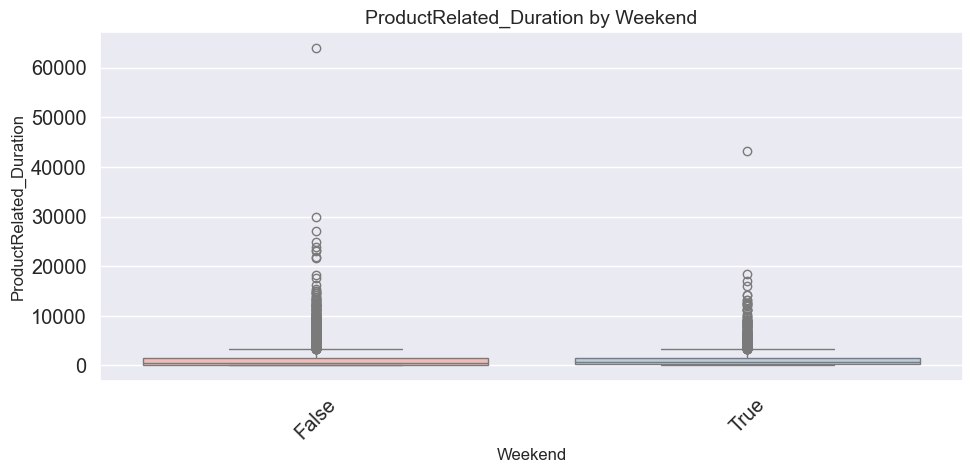

In [56]:
plot_box('Weekend', 'ProductRelated_Duration', Ol_shop_data)

#### Bivariate Analysis: `ProductRelated_Duration` by `Weekend`

- **Plot Overview:**  
  - This box plot compares the **time spent on product-related pages** (in seconds) between sessions on **weekdays (`False`)** and **weekends (`True`)**.

- **Key Observations:**
  - Median duration is **slightly higher on weekends**, suggesting a marginal increase in product-related engagement during weekends.
  - The **spread (IQR)** is similar for both weekday and weekend sessions, though the **range of outliers is wider on weekdays**, with one session even reaching above **60,000 seconds**.
  - Both groups show **numerous high-value outliers**, indicating a small subset of users spend a **significant amount of time** on product-related pages.

- **Distribution Characteristics:**
  - The distributions are **heavily right-skewed**.
  - The **concentration of values is tightly packed near the bottom**, with extreme outliers pushing the upper limit significantly.

- **Conclusion:**
  - **Weekend users tend to engage slightly more with product-related pages**, potentially reflecting increased shopping activity or leisure browsing.
  - However, **extreme durations** are more prominent during **weekdays**, which may be influenced by multitasking during work hours or accidental session hangs.

### 3. Month vs. Numerical Variables

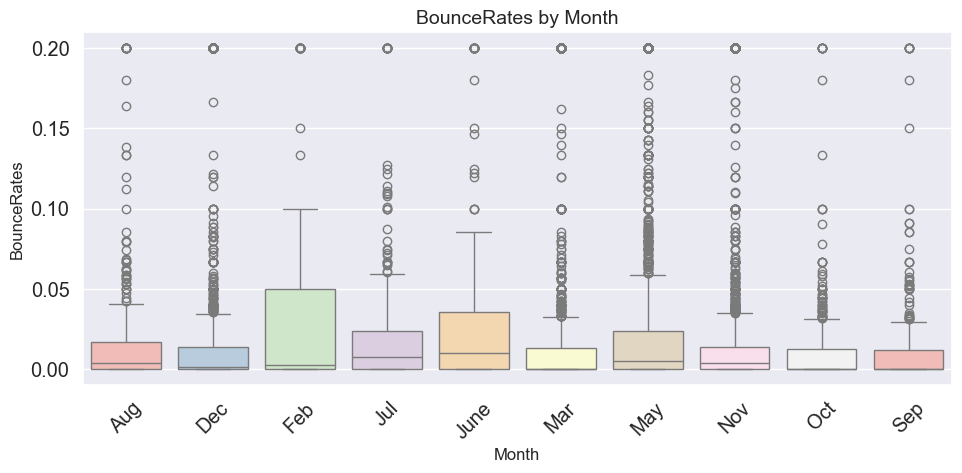

In [57]:
plot_box('Month', 'BounceRates', Ol_shop_data)

#### Bivariate Analysis: `BounceRates` by `Month`

- **Plot Overview:**  
  This box plot examines the **distribution of bounce rates** across different months, capturing how often users leave the site without further interaction.

- **Key Observations:**
  - Most months show **low median bounce rates**, close to **0.0–0.02**, with **tight interquartile ranges**.
  - **February stands out** with a **higher median and wider IQR**, indicating more varied and generally higher bounce behavior.
  - **Months like November, May, and March** exhibit **numerous outliers**, although their median values remain low.
  - **December, July, and June** also show a more **compact spread**, with relatively consistent bounce behavior.

- **Distribution Characteristics:**
  - The bounce rates are **heavily skewed**, with most values near **zero** and a **long tail of outliers** reaching up to the **maximum value of 0.2**.
  - **Extreme outliers** appear in every month, but particularly dense in **November, May, and August**.

- **Conclusion:**
  - Bounce behavior is generally low throughout the year, but **spikes and variability in February** may indicate **seasonal shifts or anomalies** in visitor engagement.
  - The **consistent low medians** suggest that **majority of users engage beyond the first page**, but **marketing or UX strategies may need refining during months with higher bounce variance**.

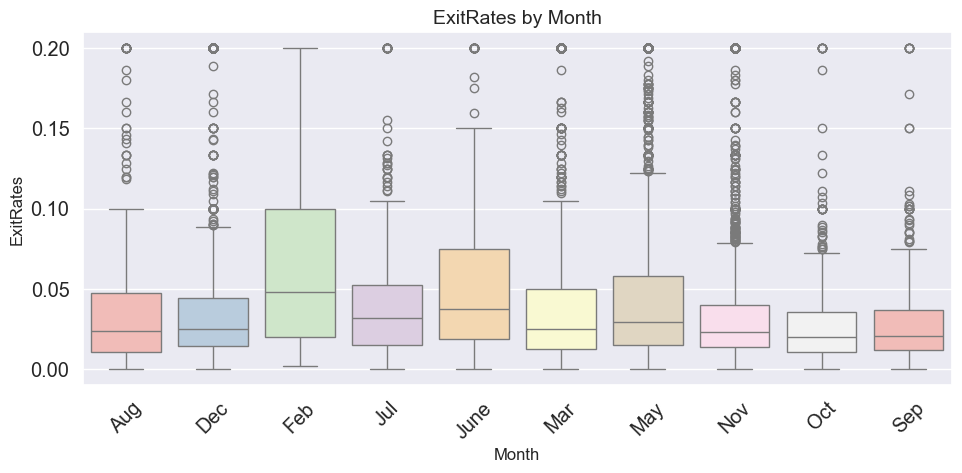

In [58]:
plot_box('Month', 'ExitRates', Ol_shop_data)

#### Bivariate Analysis: `ExitRates` by `Month`

- **Plot Overview:**  
  This box plot explores the **distribution of exit rates**—the proportion of users who leave the site from a given page—across different months.

- **Key Observations:**
  - **February** stands out with:
    - The **highest median exit rate**.
    - A **wide interquartile range (IQR)** and several high outliers, indicating **greater user drop-offs** that month.
  - **May, March, and June** also show **elevated medians and wide spreads**, suggesting **more volatile user exits** during these months.
  - **November, December, and August** exhibit **more compact distributions** with **lower medians**, indicating **more stable or engaged user behavior**.

- **Distribution Characteristics:**
  - **Right-skewed distribution** across most months, with **frequent outliers** up to the maximum of **0.2**.
  - A large number of months show a **consistent lower quartile near 0.0–0.02**, indicating **many users remain engaged** past initial pages.
  - Despite variability, most months have their medians **clustered between 0.02 and 0.05**.

- **Conclusion:**
  - **User exit behavior is not evenly distributed over time.**  
  Months like **February and May** may require closer attention—possibly **due to seasonal factors, campaign effectiveness, or navigation issues**.
  - **Lower exit rates in months like November and August** suggest **better content or UX alignment** with user expectations during those periods.

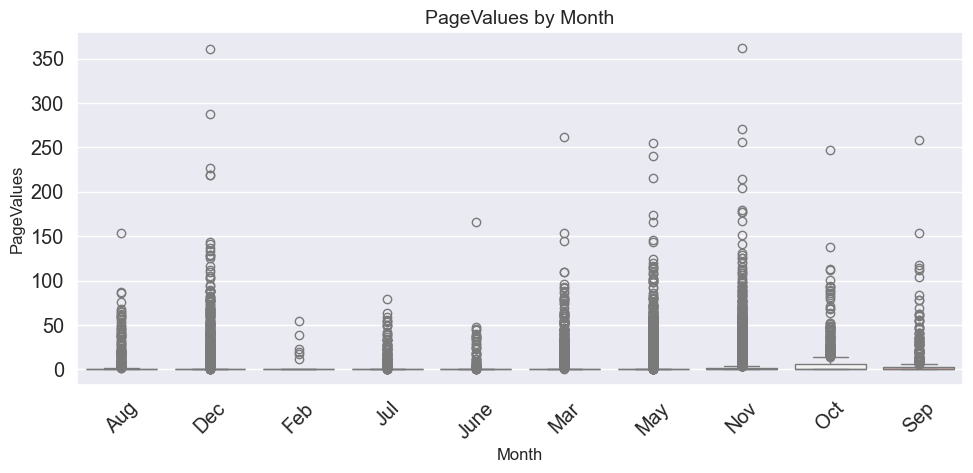

In [59]:
plot_box('Month', 'PageValues', Ol_shop_data)

#### Bivariate Analysis: `PageValues` by `Month`

- **Plot Overview:**  
  This box plot visualizes how **`PageValues`**—a metric that estimates the average value of a page based on the transactions it contributes to—varies across different months.

- **Key Observations:**
  - **May, November, and December** show:
    - **Higher median values** compared to other months.
    - **Significant outliers**, with some values exceeding **300**, indicating **very high-value interactions** during these months.
  - **March and October** also exhibit a **high spread and presence of valuable interactions**, though with **slightly lower medians**.
  - **February and June** have **consistently low median and interquartile ranges**, suggesting **limited purchasing behavior** or **less valuable engagement**.

- **Distribution Characteristics:**
  - Across all months, **most observations are clustered at 0**, reflecting sessions where **no direct conversion value** was recorded.
  - The distribution is **highly right-skewed**, with **numerous high-value outliers** in select months, likely representing **completed purchases or high-converting traffic**.
  - Despite high outliers, **the median remains near zero** in most months, highlighting the **rarity of conversions**.

- **Conclusion:**
  - Months like **May, November, and December** are **commercially significant**, possibly aligning with **sales cycles, holiday seasons, or marketing events**.
  - The **majority of sessions in all months result in no page value**, but **those with conversions spike the distribution** in a few strategic periods.
  - This insight can help **optimize promotional timing**, targeting efforts toward months where **users demonstrate higher purchase intent**.

###  4. TrafficType vs. Numerical Variables

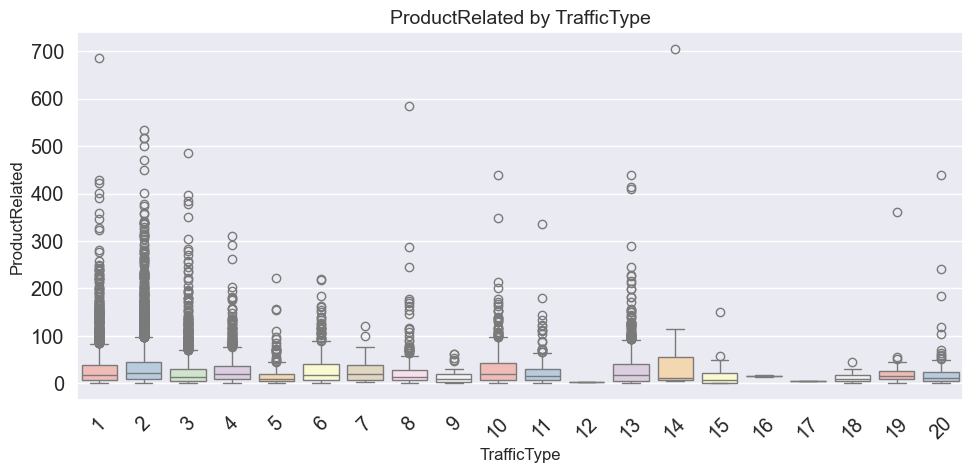

In [60]:
plot_box('TrafficType', 'ProductRelated', Ol_shop_data)

### Bivariate Analysis: `ProductRelated` by `TrafficType`

- **Plot Overview:**  
  This box plot shows how the number of **Product-Related page visits** varies across different **Traffic Types**, which represent sources through which users accessed the website (e.g., paid search, referral, direct).

- **Key Observations:**
  - **Traffic Types 1 to 4** and **13** show:
    - **Higher medians** and **greater variability** in `ProductRelated` values.
    - Numerous **outliers**, with some sessions viewing **over 600 product pages**.
    - These may correspond to users actively **browsing products**, likely with **higher purchase intent**.
  - **Traffic Types 5, 8, 10, 14, and 20** also show **occasional high outliers**, though the majority of visits are **concentrated around lower values**.
  - **Traffic Types 15–19** have **consistently low values and limited spread**, indicating **minimal product interaction**.

- **Distribution Characteristics:**
  - Most traffic types have a **right-skewed distribution**.
  - **Traffic Type 2** (most frequent overall based on prior plots) displays:
    - High density near **zero**.
    - A **very wide range of values**, suggesting a **broad mix of user behavior** — from bounce visits to extensive product browsing.
  - **Traffic Types 6, 7, 9, 12, 16–18** show **narrow distributions** around 0–20 page visits, possibly reflecting **non-shopping behavior** or **low engagement channels**.

- **Conclusion:**
  - Traffic sources like **Types 1–4 and 13** are more associated with **engaged users** viewing **many product pages**, suggesting these may be **organic search, paid campaigns, or loyal users**.
  - On the other hand, **Types 15–19** may represent **low-performing sources** in terms of product engagement.
  - This analysis can help **prioritize traffic channels** that drive higher engagement with product pages, aiding in **campaign targeting** and **resource allocation**.

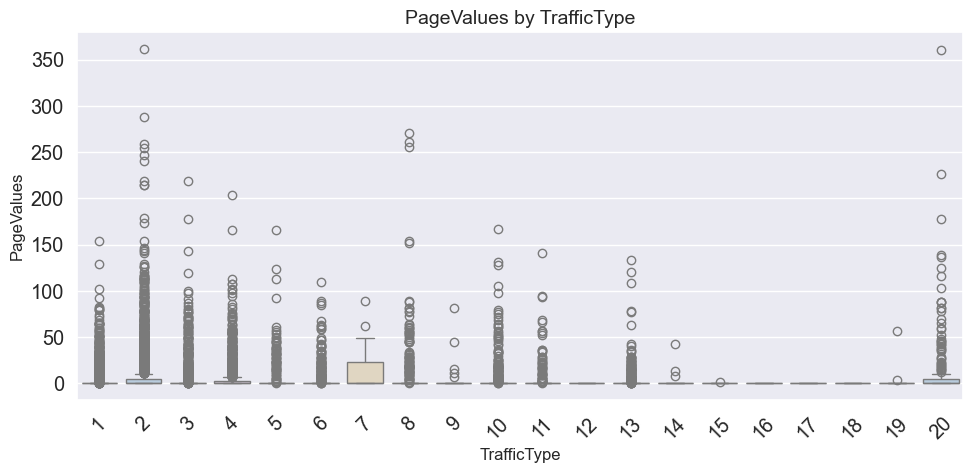

In [61]:
plot_box('TrafficType', 'PageValues', Ol_shop_data)

### Bivariate Analysis: `PageValues` by `TrafficType`

- **Plot Overview:**  
  This box plot illustrates the distribution of **PageValues** (monetary value assigned to user sessions based on ecommerce activity) across different **Traffic Types**.

- **Key Observations:**
  - **Traffic Types 1 to 4** and **2 in particular** stand out with:
    - **High concentration of values > 0**.
    - A **wide range of values**, including outliers above **300**.
    - This suggests these traffic sources are **more likely to lead to valuable interactions** (e.g., add-to-cart, checkout, purchases).
  - **Traffic Types 10, 13, 20** also show some elevated values and variability, hinting at **moderate monetization potential**.
  - In contrast, **Traffic Types 5, 6, 7, 8, 9, 14–19** show:
    - **Very low PageValues**, with medians at **0**.
    - Little to no variation and occasional outliers, implying **lower commercial success** from these channels.

- **Distribution Characteristics:**
  - Extremely **right-skewed** distributions.
  - **Most sessions across all traffic types have PageValue = 0**, indicating:
    - **No conversions or attributed goal completions** for the majority of visits.
    - Even in top-performing traffic types, high values are **driven by a subset** of users.

- **Conclusion:**
  - **Traffic Type 2** appears to be the **most profitable channel**, likely driving **repeat customers or conversions**.
  - **Traffic Types 1, 3, and 4** also generate **substantial value**.
  - **Other traffic types** may require **optimization or reevaluation**, as they are not currently yielding significant value.

- **Business Implication:**
  - Focus marketing and campaign budgets on **top-converting traffic types**.
  - Consider improving landing pages, messaging, or targeting for low-value traffic types.
  - Run **conversion rate optimization (CRO)** experiments on low-performing sources.

### 5. Region vs. Numerical Variables

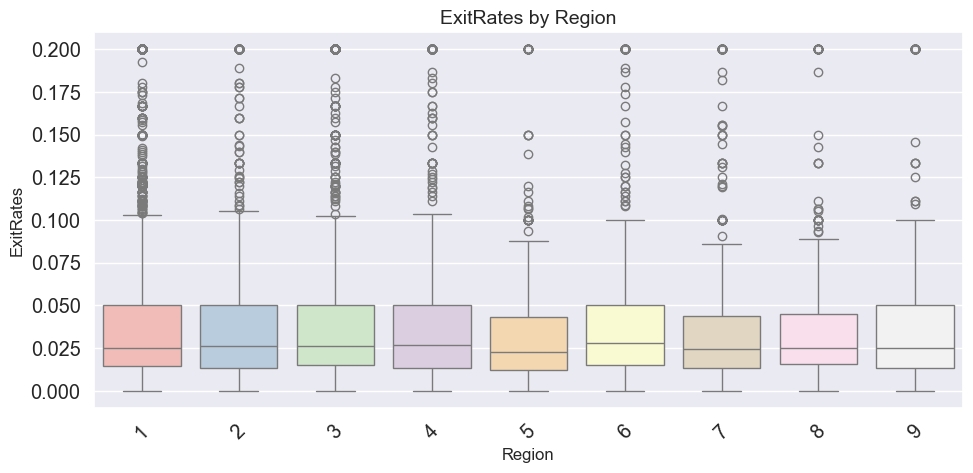

In [62]:
plot_box('Region', 'ExitRates', Ol_shop_data)

### Bivariate Analysis: `ExitRates` by `Region`

- **Plot Overview:**  
  This box plot compares how **ExitRates** (percentage of times a user exits the site from a specific page) vary across different **Regions**.

- **Key Observations:**
  - **Median ExitRates** are **remarkably consistent** across all 9 regions, clustered roughly between **0.025 and 0.035**.
  - All regions exhibit a similar distribution pattern:
    - **Minimum values** near 0.
    - **Upper whiskers** extending to around **0.10**.
    - **Numerous outliers** stretching toward the maximum of **0.20**.
  - **Regions 5, 6, 8, and 9** have slightly **higher interquartile ranges (IQRs)** and more frequent outliers, which could suggest:
    - Greater **variability in user behavior**.
    - Potential UX or content differences that lead to higher exits.

- **Distribution Characteristics:**
  - Overall distributions are **right-skewed**.
  - A **significant concentration of low ExitRates** in all regions, indicating that most users don’t exit from their first or early pages.
  - **Outliers** are frequent but not excessive, implying natural variation rather than data quality issues.

- **Conclusion:**
  - Exit behavior is **not highly region-dependent**.
  - **Consistent user behavior across geographic segments** in terms of exit tendency.
  - Minor increases in variability in some regions may merit deeper **page-level analysis**.

- **Business Implication:**
  - Since ExitRates are similar across regions, global content strategies are likely performing uniformly.
  - To improve retention, consider focusing on **specific pages with high exits**, rather than targeting by region.
  - Monitor Regions 5–9 for further patterns (e.g., device type, session duration, or referral traffic).

## 3. Pre-Clustering Data Preparation 

Before applying clustering algorithms, it’s crucial to prepare the dataset so that it meets the core assumptions and requirements for unsupervised learning. Our goal in this section is to ensure that the dataset is **numeric, scaled, and free from redundant features.**

### 3.1 Removing Highly Correlated Features
Clustering algorithms are sensitive to multicollinearity, where variables are highly correlated and convey overlapping information. From our earlier EDA, we generated a correlation heatmap of all numerical features. The heatmap revealed that a few variables were strongly correlated with each other (correlation > 0.85), which can distort distance-based clustering methods like K-Means.

To address this, we dropped the following features:

- `ProductRelated_Duration`, as it is highly correlated with `ProductRelated` (0.86)
- `ExitRates`, as it is highly correlated with `BounceRates` (0.91)

By removing these variables, we reduce redundancy and improve the clustering quality.


In [63]:
# Drop highly correlated features
cols_to_drop = ['ProductRelated_Duration', 'ExitRates']
Ol_shop_data_reduced = Ol_shop_data.drop(columns=cols_to_drop)

# shape of the dataset and remaining columns
print("Shape after dropping correlated columns:", Ol_shop_data_reduced.shape)
print("Remaining columns:\n", Ol_shop_data_reduced.columns.tolist())


Shape after dropping correlated columns: (12330, 15)
Remaining columns:
 ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'BounceRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']



### 3.2 Handle Skewed Distributions using Box-Cox Transformation

Instead of removing or capping outliers, we apply a Box-Cox transformation to correct the right-skewed nature of several numerical features. This approach helps normalize the distributions while retaining all data points.

Box-Cox transformation is applied only to positive-valued data. In cases where the column contains zeros, a small constant (e.g., 1e-5) is added to shift the distribution for transformation.


In [64]:
from scipy.stats import boxcox
from sklearn.preprocessing import PowerTransformer
import numpy as np

# Copy of the dataset after dropping correlated columns
data_transformed = Ol_shop_data_reduced.copy()

# Columns to transform
boxcox_cols = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'BounceRates',
    'PageValues', 'SpecialDay'
]

# Applying Box-Cox transformation
for col in boxcox_cols:
    min_val = data_transformed[col].min()
    if min_val <= 0:
        # here we are adding small value to make it positive
        shift = abs(min_val) + 1e-5
        transformed_data, _ = boxcox(data_transformed[col] + shift)
    else:
        transformed_data, _ = boxcox(data_transformed[col])
    
    data_transformed[col] = transformed_data

# Review changes
data_transformed[boxcox_cols].describe()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,BounceRates,PageValues,SpecialDay
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,-4.092170,-2.899507,-141.197959,-90.676621,3.789796,-7.401767,-77.275935,-32683.876612
std,5.670262,7.765388,73.816258,45.761842,2.098294,3.799226,42.142596,10982.867159
min,-10.106567,-10.947678,-179.642037,-113.202129,-4.895092,-11.468904,-99.747662,-36374.302534
25%,-10.106567,-10.947678,-179.642037,-113.202129,2.325337,-11.468904,-99.747662,-36374.302534
50%,0.000010,2.032915,-179.642037,-113.202129,3.779394,-5.758064,-99.747662,-36374.302534
75%,1.408778,4.627285,-179.642037,-113.202129,5.116057,-4.079484,-99.747662,-36374.302534
max,3.424811,8.429834,1.881944,2.927506,12.433214,-1.608526,2.779910,0.000010


###  Observations

After applying the Box-Cox transformation to the selected skewed numerical columns, the following patterns are observed in the summary statistics:

- **Administrative & Administrative_Duration**
  - The distributions appear more normalized, with both positive and negative values.
  - Means are approximately -4.09 and -2.90 respectively, indicating a centered spread post-transformation.

- **Informational & Informational_Duration**
  - These features remain highly skewed even after transformation.
  - A significant number of zero or near-zero values in the original data limited the effectiveness of Box-Cox.
  - Most values cluster around the minimum (-179.64 and -113.20), suggesting minimal variation post-transformation.

- **ProductRelated**
  - This feature responded well to the transformation, showing a mean around 3.79 and a more even spread across its range (up to 12.43).

- **BounceRates & PageValues**
  - These columns show a considerable leftward shift, with means of -7.40 and -77.28 respectively.
  - The transformation compresses the highly skewed values (many near zero) 
  - Still retains the original data's relative spread and ranking.

- **SpecialDay**
  - This variable exhibited the most dramatic transformation outcome.
  - Most values clustered at a transformed value of -36,374, with a mean around -32,684.
  - Indicates that the feature was dominated by zeros.

 **Conclusion:** While Box-Cox transformation improved normality for some features (like `Administrative`, `ProductRelated`), others with extreme sparsity (like `SpecialDay`, `Informational`) retained skewness. 

### 3.3 Encode Categorical Variables
Clustering requires numeric input. Therefore, we use one-hot encoding to convert categorical variables (`Month`, `VisitorType`, `OperatingSystems`, `Browser`, `Region`, `TrafficType`, and `Weekend`) into binary indicator columns.

In [65]:
categorical_cols = ['Month', 'VisitorType', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend']

for col in categorical_cols:
    print(f"\n{col} unique values:")
    print(Ol_shop_data[col].unique())



Month unique values:
['May', 'Mar', 'Nov', 'Feb', 'June', 'Sep', 'Dec', 'Jul', 'Aug', 'Oct']
Categories (10, object): ['Aug', 'Dec', 'Feb', 'Jul', ..., 'May', 'Nov', 'Oct', 'Sep']

VisitorType unique values:
['New_Visitor', 'Returning_Visitor', 'Other']
Categories (3, object): ['New_Visitor', 'Other', 'Returning_Visitor']

OperatingSystems unique values:
[1, 2, 4, 3, 8, 6, 5, 7]
Categories (8, int64): [1, 2, 3, 4, 5, 6, 7, 8]

Browser unique values:
[1, 2, 8, 4, 6, ..., 10, 7, 11, 12, 9]
Length: 13
Categories (13, int64): [1, 2, 3, 4, ..., 10, 11, 12, 13]

Region unique values:
[1, 4, 9, 2, 3, 6, 8, 5, 7]
Categories (9, int64): [1, 2, 3, 4, ..., 6, 7, 8, 9]

TrafficType unique values:
[2, 3, 4, 6, 8, ..., 15, 9, 7, 12, 17]
Length: 20
Categories (20, int64): [1, 2, 3, 4, ..., 17, 18, 19, 20]

Weekend unique values:
[ True False]


In [66]:
# Working on a copy of the dataset (Ol_shop_data) that has already undergone prior transformations
df_prepped = Ol_shop_data.copy()

#### 1. Weekend
Weekend is already binary (True/False). So here we are just converting the boolean datatype in to integer (0/1).

In [67]:
df_prepped['Weekend'] = df_prepped['Weekend'].astype(int)

#### 2. VisitorType
VisitorType contains: Returning_Visitor, New_Visitor, and Other variables.<br>
Since 'Other' has a very low count and is similar to New_Visitor, we merge it with New_Visitor.

In [68]:
df_prepped['VisitorType'] = df_prepped['VisitorType'].replace({'Other': 'New_Visitor'})

Then we create a binary variable: 1 if Returning_Visitor, 0 if New_Visitor.

In [69]:
df_prepped['VisitorType_Binary'] = np.where(df_prepped['VisitorType'] == 'Returning_Visitor', 1, 0)

#### 3. Month
There are 10 unique months, but the analysis shows that some months (May, Nov, Mar, Dec) have much higher traffic.
<br>So, we create a new variable that buckets months into 'High' and 'Low' traffic groups.

In [70]:
high_traffic_months = ['May', 'Nov', 'Mar', 'Dec']
df_prepped['Month_Group'] = df_prepped['Month'].apply(lambda x: 'High' if x in high_traffic_months else 'Low')

#### 4. OperatingSystems
Although there are 8 OS codes, the majority of sessions come from codes 2, 1, 3, and 4.
<br>So, we group the less frequent OS codes into an 'Other' category.

In [71]:
df_prepped['OperatingSystems_Group'] = df_prepped['OperatingSystems'].apply(lambda x: x if int(x) in [2, 1, 3, 4] else 'Other')

#### 5. Browser
The Browser variable has 13 categories. Most sessions are from codes 2, 1, 4, and 5.
<br>So, we group all other less frequent browser codes into 'Other'.

In [72]:
df_prepped['Browser_Group'] = df_prepped['Browser'].apply(lambda x: x if int(x) in [2, 1, 4, 5] else 'Other')

#### 6. Region
There are 9 regions, but a few dominate (Regions 1, 3, 4, and 2).
<br>So, we group all other regions into 'Other'.

In [73]:
df_prepped['Region_Group'] = df_prepped['Region'].apply(lambda x: x if int(x) in [1, 3, 4, 2] else 'Other')

#### 7. TrafficType
TrafficType has 20 categories. The top five by frequency are 2, 1, 3, 4, and 13.
<br>So, we keep these and group the rest as 'Other'.

In [74]:
df_prepped['TrafficType_Group'] = df_prepped['TrafficType'].apply(lambda x: x if int(x) in [2, 1, 3, 4, 13] else 'Other')

In the above we are bucketing the categorical variables so that we can use one-hot encoding and convert them into the numerical variables.

#### Let's quickly check the new grouped columns:

In [75]:
print("VisitorType_Binary value counts:")
print(df_prepped['VisitorType_Binary'].value_counts())
print("\nMonth_Group value counts:")
print(df_prepped['Month_Group'].value_counts())
print("\nOperatingSystems_Group value counts:")
print(df_prepped['OperatingSystems_Group'].value_counts())
print("\nBrowser_Group value counts:")
print(df_prepped['Browser_Group'].value_counts())
print("\nRegion_Group value counts:")
print(df_prepped['Region_Group'].value_counts())
print("\nTrafficType_Group value counts:")
print(df_prepped['TrafficType_Group'].value_counts())

VisitorType_Binary value counts:
VisitorType_Binary
1    10551
0     1779
Name: count, dtype: int64

Month_Group value counts:
Month_Group
High    9996
Low     2334
Name: count, dtype: int64

OperatingSystems_Group value counts:
OperatingSystems_Group
2        6601
1        2585
3        2555
4         478
Other     111
Name: count, dtype: int64

Browser_Group value counts:
Browser_Group
2        7961
1        2462
4         736
Other     704
5         467
Name: count, dtype: int64

Region_Group value counts:
Region_Group
1        4780
Other    2829
3        2403
4        1182
2        1136
Name: count, dtype: int64

TrafficType_Group value counts:
TrafficType_Group
2        3913
1        2451
Other    2107
3        2052
4        1069
13        738
Name: count, dtype: int64


#### Let's drop the original categorical columns now that we have our new groups.

In [76]:
cols_to_drop = ['Month', 'VisitorType', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']
df_prepped.drop(columns=cols_to_drop, inplace=True)

#### Finally, we apply one-hot encoding to the new grouped categorical variables.
The binary VisitorType_Binary and Weekend are already numeric, so we leave them as is.

In [77]:
categorical_new = ['Month_Group', 'OperatingSystems_Group', 'Browser_Group', 'Region_Group', 'TrafficType_Group']
df_encoded = pd.get_dummies(df_prepped, columns=categorical_new, drop_first=True)

In [78]:
print("Shape after encoding grouped categorical variables:", df_encoded.shape)
df_encoded.head()

Shape after encoding grouped categorical variables: (12330, 30)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Browser_Group_Other,Region_Group_2,Region_Group_3,Region_Group_4,Region_Group_Other,TrafficType_Group_2,TrafficType_Group_3,TrafficType_Group_4,TrafficType_Group_13,TrafficType_Group_Other
0,0,0.0,0,0.0,8,222.000000,0.000000,0.028571,53.474571,0.0,...,False,False,False,False,False,True,False,False,False,False
1,0,0.0,0,0.0,14,1037.500000,0.014286,0.047619,0.000000,0.0,...,False,False,False,True,False,True,False,False,False,False
2,4,37.5,2,82.0,4,96.625000,0.000000,0.017500,0.000000,0.0,...,False,False,False,False,True,True,False,False,False,False
3,4,115.7,0,0.0,16,655.383333,0.000000,0.012037,0.000000,0.0,...,False,True,False,False,False,False,True,False,False,False
4,1,60.0,1,15.0,26,670.166667,0.000000,0.003846,0.000000,0.0,...,False,False,True,False,False,False,False,True,False,False


After doing the one hot encoding we have two observations to make, one the column number increased not too significantly its 30 but if we have not done the bucketing it might be even more number of columns. 

Second our goal was to convert the categorical variables into numerical but rather it got converted inot the boolean columns, so we will just assign them 0's and 1's.

In [79]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Administrative                12330 non-null  int64  
 1   Administrative_Duration       12330 non-null  float64
 2   Informational                 12330 non-null  int64  
 3   Informational_Duration        12330 non-null  float64
 4   ProductRelated                12330 non-null  int64  
 5   ProductRelated_Duration       12330 non-null  float64
 6   BounceRates                   12330 non-null  float64
 7   ExitRates                     12330 non-null  float64
 8   PageValues                    12330 non-null  float64
 9   SpecialDay                    12330 non-null  float64
 10  Weekend                       12330 non-null  int32  
 11  VisitorType_Binary            12330 non-null  int32  
 12  Month_Group_Low               12330 non-null  bool   
 13  O

In [80]:
print(df_encoded.dtypes.value_counts())

bool       18
float64     7
int64       3
int32       2
Name: count, dtype: int64


Above we just confirmed that all the categorical columns are converted in to the boolean columns, Let's convert the columns into our desired format/ data type.

In [81]:
# Identify boolean columns in df_encoded
bool_cols = df_encoded.select_dtypes(include='bool').columns

# Convert each boolean column to integer (False -> 0, True -> 1)
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

Let's verify our columns.

In [82]:
print(df_encoded.dtypes.value_counts())

int32      20
float64     7
int64       3
Name: count, dtype: int64


Here we can see that all our columns are finally converted into the numerical columns.

###### 3.4 Standardize Features
To ensure all features contribute equally to distance calculations, we standardize all numerical variables using `StandardScaler`. This scales features to have a mean of 0 and standard deviation of 1.

In [83]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler to the encoded data and transform it
scaled_array = scaler.fit_transform(df_encoded)

# Convert the scaled array back into a DataFrame, retaining the original column names
df_scaled = pd.DataFrame(scaled_array, columns=df_encoded.columns)

# Display the first few rows of the standardized dataset
print("Standardized dataset preview:")
print(df_scaled.head())


Standardized dataset preview:
   Administrative  Administrative_Duration  Informational  \
0       -0.696993                -0.457191      -0.396478   
1       -0.696993                -0.457191      -0.396478   
2        0.507228                -0.245054       1.178195   
3        0.507228                 0.197324      -0.396478   
4       -0.395938                -0.117771       0.390859   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0               -0.244931       -0.533607                -0.508335   
1               -0.244931       -0.398696                -0.082173   
2                0.337689       -0.623548                -0.573853   
3               -0.244931       -0.353725                -0.281859   
4               -0.138354       -0.128873                -0.274133   

   BounceRates  ExitRates  PageValues  SpecialDay  ...  Browser_Group_Other  \
0    -0.457683  -0.298415    2.562803   -0.308821  ...            -0.246077   
1    -0.163049   0.09355

## 4. Cluster Modeling 

In [84]:
df_scaled

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Browser_Group_Other,Region_Group_2,Region_Group_3,Region_Group_4,Region_Group_Other,TrafficType_Group_2,TrafficType_Group_3,TrafficType_Group_4,TrafficType_Group_13,TrafficType_Group_Other
0,-0.696993,-0.457191,-0.396478,-0.244931,-0.533607,-0.508335,-0.457683,-0.298415,2.562803,-0.308821,...,-0.246077,-0.318564,-0.492003,-0.325619,-0.545672,1.466641,-0.446822,-0.308106,-0.252318,-0.453987
1,-0.696993,-0.457191,-0.396478,-0.244931,-0.398696,-0.082173,-0.163049,0.093555,-0.317178,-0.308821,...,-0.246077,-0.318564,-0.492003,3.071070,-0.545672,1.466641,-0.446822,-0.308106,-0.252318,-0.453987
2,0.507228,-0.245054,1.178195,0.337689,-0.623548,-0.573853,-0.457683,-0.526248,-0.317178,-0.308821,...,-0.246077,-0.318564,-0.492003,-0.325619,1.832602,1.466641,-0.446822,-0.308106,-0.252318,-0.453987
3,0.507228,0.197324,-0.396478,-0.244931,-0.353725,-0.281859,-0.457683,-0.638667,-0.317178,-0.308821,...,-0.246077,3.139088,-0.492003,-0.325619,-0.545672,-0.681830,2.238029,-0.308106,-0.252318,-0.453987
4,-0.395938,-0.117771,0.390859,-0.138354,-0.128873,-0.274133,-0.457683,-0.807223,-0.317178,-0.308821,...,-0.246077,-0.318564,2.032507,-0.325619,-0.545672,-0.681830,-0.446822,3.245635,-0.252318,-0.453987
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,0.206173,0.380046,-0.396478,-0.244931,-0.533607,-0.471494,-0.457683,-0.325141,-0.317178,-0.308821,...,-0.246077,-0.318564,-0.492003,-0.325619,-0.545672,-0.681830,2.238029,-0.308106,-0.252318,-0.453987
12326,-0.395938,-0.406278,0.390859,-0.035329,-0.196329,-0.019420,-0.299034,0.221699,-0.317178,-0.308821,...,-0.246077,-0.318564,-0.492003,-0.325619,1.832602,1.466641,-0.446822,-0.308106,-0.252318,-0.453987
12327,-0.696993,-0.457191,-0.396478,-0.244931,1.332665,1.548338,-0.251439,-0.309897,-0.317178,-0.308821,...,-0.246077,-0.318564,-0.492003,-0.325619,-0.545672,-0.681830,-0.446822,-0.308106,3.963246,-0.453987
12328,-0.696993,-0.457191,-0.396478,-0.244931,0.140949,0.116493,-0.125276,0.116168,-0.317178,4.718598,...,4.063767,-0.318564,2.032507,-0.325619,-0.545672,-0.681830,-0.446822,-0.308106,-0.252318,2.202708


## Hierarchical Clustering

To explore the natural grouping of sessions within the dataset, we apply **Hierarchical Clustering** using the **Ward linkage method**, which minimizes the variance within each cluster when merging. This method is particularly effective for producing compact and spherical clusters.

we begin by computing the **linkage matrix** using Ward's method and then plotting the **dendrogram** to visualize the hierarchical merging process.

The dendrogram displays the distances at which clusters are joined. By analyzing the height (distance) of the vertical lines, we can infer a suitable number of clusters.


In [85]:
# scikit-learn pinned in requirements.txt

In [86]:
import sklearn
print(sklearn.__version__)


1.5.1


#### Step 1: Generate the Linkage Matrix and Plot the Dendrogram
Using Ward's method (which minimizes the within-cluster variance) is common.

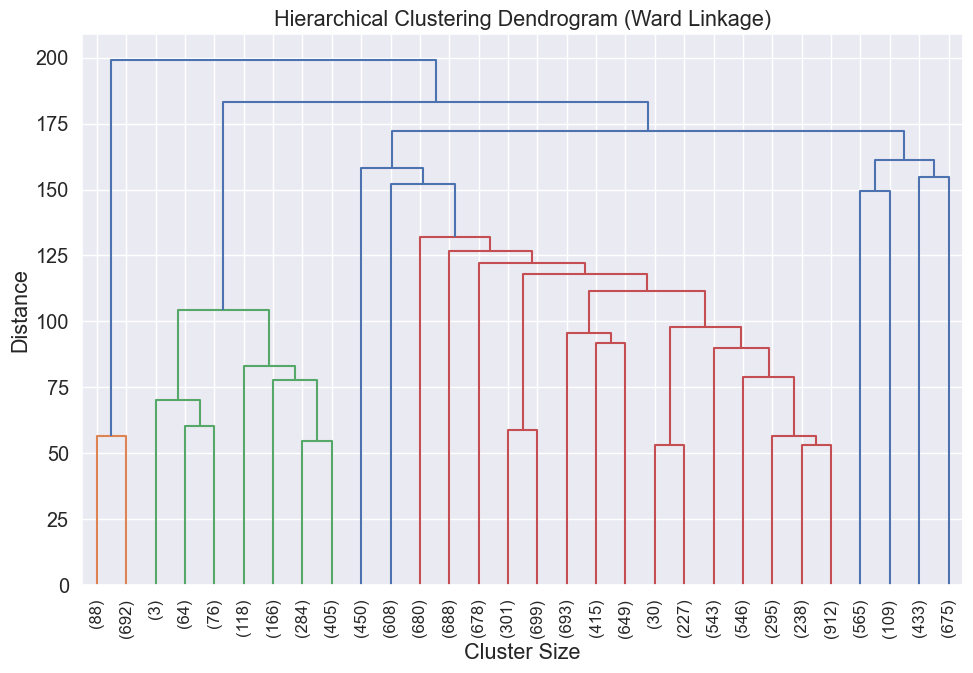

In [87]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
Z = linkage(df_scaled, method='ward')

plt.figure(figsize=(10, 7))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=12.)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


**Observation**:
- An imaginary vertical cut between distances **130 and 145** on the dendrogram yields **9 distinct clusters**.
- This threshold ensures we are capturing the most significant cluster separations before the linkage distance increases sharply.

This visual strategy offers an intuitive approach to selecting the optimal number of clusters without relying solely on numerical metrics.

#### Step 2: Apply Agglomerative Clustering
Let's assume the dendrogram suggests that 9 clusters is appropriate.

In [88]:
agg_cluster = AgglomerativeClustering(n_clusters=9, metric='euclidean', linkage='ward')
clusters = agg_cluster.fit_predict(df_scaled)
print("Cluster labels assigned to each observation:")
print(np.unique(clusters))

Cluster labels assigned to each observation:
[0 1 2 3 4 5 6 7 8]


#### Step 2: Apply Agglomerative Clustering

Based on the dendrogram analysis, we proceed with **Agglomerative Clustering** using the **Ward linkage** method and specify **9 clusters** as the optimal choice.

We use:
- `n_clusters=9` to define the number of clusters.
- `metric='euclidean'` as the distance metric (default for Ward's method).
- `linkage='ward'` to ensure minimal variance within each cluster merge.

The model assigns a cluster label (ranging from 0 to 8) to each observation in the scaled dataset.

**Output**:
- After fitting the model, we can see that the clustering successfully assigns labels across all data points.
- The output shows the **unique cluster labels**, confirming that all 9 clusters are being used.

This step provides the foundation for further analysis, such as visualizing the clusters or interpreting their characteristics.


## K-Means Clustering

In [89]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Define a range of K values to try
K_range = range(2, 31)  # testing K from 2 to 31
inertia_values = []
silhouette_scores = []

# Iterate over the range of K values
for k in K_range:
    # Initialize KMeans with the current number of clusters and a fixed random state for reproducibility
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    
    # Record the inertia (sum of squared distances)
    inertia_values.append(kmeans.inertia_)
    
    # Compute the silhouette score for the current clustering
    labels = kmeans.labels_
    sil_score = silhouette_score(df_scaled, labels)
    silhouette_scores.append(sil_score)
    
    print(f"For k = {k}: Inertia = {kmeans.inertia_:.2f}, Average Silhouette Score = {sil_score:.3f}")



For k = 2: Inertia = 345689.45, Average Silhouette Score = 0.153


For k = 3: Inertia = 325129.27, Average Silhouette Score = 0.139


For k = 4: Inertia = 309792.98, Average Silhouette Score = 0.091


For k = 5: Inertia = 299183.49, Average Silhouette Score = 0.070


For k = 6: Inertia = 288229.24, Average Silhouette Score = 0.089


...

For k = 26: Inertia = 173501.78, Average Silhouette Score = 0.122


For k = 27: Inertia = 172004.98, Average Silhouette Score = 0.118


For k = 28: Inertia = 171375.90, Average Silhouette Score = 0.113


For k = 29: Inertia = 170588.21, Average Silhouette Score = 0.110


For k = 30: Inertia = 168072.91, Average Silhouette Score = 0.116


To identify natural groupings in the dataset, we apply **K-Means clustering** and evaluate multiple cluster configurations by varying the number of clusters (**K**) from 2 to 30.

#### Evaluation Metrics:
- **Inertia**: Measures the total **within-cluster sum of squared distances**. Lower inertia indicates tighter clusters but may decrease with higher K regardless of actual clustering quality.
- **Silhouette Score**: Measures how similar each point is to its own cluster compared to other clusters. Values range from -1 to 1:
  - **Close to 1** → Well-clustered
  - **Around 0** → Overlapping clusters
  - **Negative** → Misclassified points

#### Results Summary:
Here are a few key observations from the clustering metrics:

- For **K = 2**, we observe a **relatively high silhouette score of 0.153**, indicating distinct separation.
- As **K increases**, **inertia decreases** (as expected), but the **silhouette scores** do not consistently improve.
- The **highest silhouette scores** are observed at:
  - **K = 2 (0.153)**
  - **K = 13 (0.143)**
  - **K = 17 (0.145)**
  - **K = 11 (0.135)**
- Beyond **K = 17**, silhouette scores start to flatten or decrease slightly, suggesting **diminishing returns** in clustering quality.

### Conclusion:
- **K = 2** provides the simplest and most separated clustering structure.
- **K = 13 or K = 17** could offer a more granular segmentation without significantly compromising quality.
- These K values may be used for downstream profiling or visualization depending on the analytical goals.

Next step: we will Plot the **Elbow Curve** and **Silhouette Scores** to visually validate the optimal K.

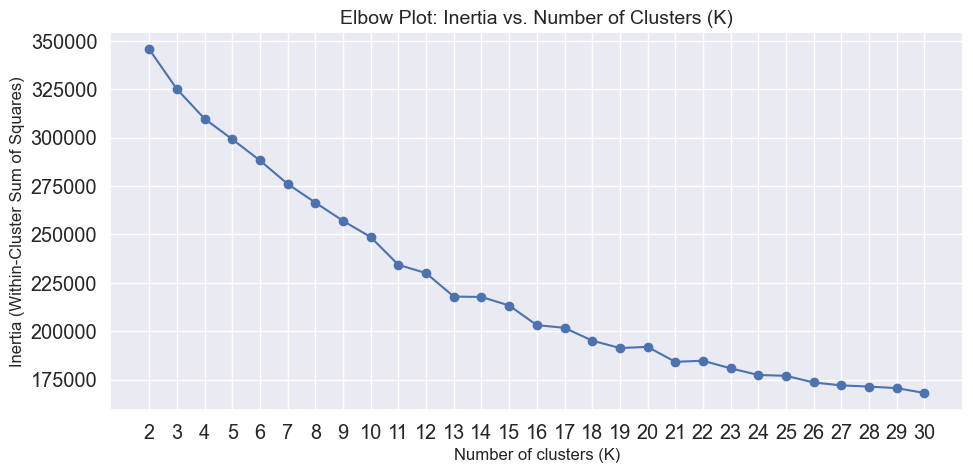

In [90]:
# --- Elbow Plot ---
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia_values, marker='o', linestyle='-')
plt.title('Elbow Plot: Inertia vs. Number of Clusters (K)', fontsize=14)
plt.xlabel('Number of clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.xticks(K_range)
plt.grid(True)
plt.tight_layout()
plt.show()


#### Optimal Number of Clusters from Elbow Plot: **K = 13**

By analyzing the **Elbow Plot**, we observe a noticeable **"elbow" or inflection point around K = 13**. This indicates that increasing the number of clusters beyond 13 yields **diminishing returns** in reducing inertia (within-cluster variance).

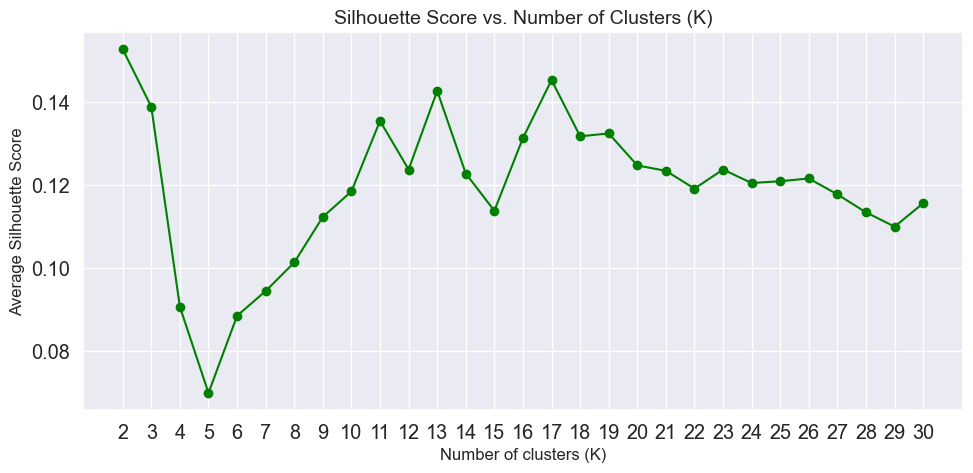

In [91]:
# --- Silhouette Plot ---
plt.figure(figsize=(10, 5))
plt.plot(K_range, silhouette_scores, marker='o', linestyle='-', color='green')
plt.title('Silhouette Score vs. Number of Clusters (K)', fontsize=14)
plt.xlabel('Number of clusters (K)', fontsize=12)
plt.ylabel('Average Silhouette Score', fontsize=12)
plt.xticks(K_range)
plt.grid(True)
plt.tight_layout()
plt.show()


from the Silhouette plot we assume there are 13 number of clusters.
#### Comparing Cluster Estimation Techniques

To determine the optimal number of clusters, we employed **multiple clustering evaluation methods**, each providing a different perspective:

#####  Dendrogram (Hierarchical Clustering)
- Based on the **Ward linkage dendrogram**, we identified a suitable cut between distances **130 and 145**, which results in **9 clusters**.
- This method emphasizes **hierarchical relationships** and is sensitive to the linkage method and distance threshold.

#####  Elbow Method (K-Means)
- The **inertia curve** showed an inflection point around **K = 13**, suggesting that **13 clusters** strike a balance between complexity and compactness.
- Inertia continues to decrease beyond K=13, but with **diminishing improvements**.

##### Silhouette Analysis
- The **average silhouette score peaked at K = 2**, but **K = 13** was among the **top-scoring configurations (score = 0.143)**.
- It provided **reasonably well-separated clusters** with sufficient interpretability.

---

### Final Conclusion:
- While **Hierarchical Clustering (dendrogram)** suggests **9 clusters**, both **Elbow** and **Silhouette** methods (from K-Means) consistently indicate that **13 clusters** may better capture the natural groupings in the data.
- Therefore, we proceed with **K = 13 clusters** for final modeling and customer segmentation analysis.

> Using multiple methods helps validate our choice and provides stronger confidence in the clustering decision.


In [92]:
from sklearn.cluster import KMeans

# Choose K based on the elbow and silhouette plots
K = 13

# Initialize the KMeans model with 13 clusters
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)


In [93]:
# Fit the model and assign cluster labels
cluster_labels = kmeans.fit_predict(df_scaled)


df_scaled['Cluster'] = cluster_labels

# Display the unique clusters and their counts
print("Unique clusters:", np.unique(cluster_labels))
print("\nCluster counts:")
print(df_scaled['Cluster'].value_counts())

Unique clusters: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]

Cluster counts:
Cluster
0     3577
3     1611
12    1194
5      806
8      779
1      769
4      712
10     682
11     613
7      584
2      455
6      437
9      111
Name: count, dtype: int64


## 5. Post-Clustering Exploratory Data Analysis 

In [94]:
# Compute summary statistics (mean, median, std) for each cluster
cluster_summary = df_scaled.groupby('Cluster').agg(['mean', 'median', 'std'])
print("Summary Statistics by Cluster:")
print(cluster_summary)

Summary Statistics by Cluster:
        Administrative                     Administrative_Duration            \
                  mean    median       std                    mean    median   
Cluster                                                                        
0            -0.062816 -0.395938  0.824880               -0.077314 -0.361022   
1             1.754513  1.711449  1.517779                1.515636  0.766023   
2            -0.051875 -0.395938  0.929066               -0.132784 -0.445877   
3            -0.027981 -0.395938  0.855485               -0.015872 -0.345937   
4            -0.031881 -0.395938  0.855681               -0.004688 -0.362908   
5            -0.001877 -0.395938  0.876922               -0.041239 -0.337829   
6            -0.054237 -0.395938  0.933168               -0.064630 -0.457191   
7            -0.136638 -0.696993  0.824405               -0.036807 -0.457191   
8            -0.690810 -0.696993  0.045372               -0.457090 -0.457191   
9        

### Post-Clustering Exploratory Data Analysis (EDA)

After applying K-Means clustering and determining that **13 clusters** best represent the structure of our data, we conducted a post-clustering exploratory analysis to better understand the nature of these clusters.

#### Summary Statistics
We computed **mean**, **median**, and **standard deviation** for each feature within every cluster. Some notable observations:

- **Cluster 1** has higher average values for several features like `Administrative`, `Administrative_Duration`, and `Informational_Duration`, indicating this group tends to browse more administrative and informational pages.
- **Cluster 8** exhibits very low variation in `Administrative` activity with a small standard deviation, suggesting users in this cluster are relatively inactive.
- **Cluster 11** stands out with an unusually high average in `TrafficType_Group_13`, hinting at a unique traffic source or user segment.


### Box Plot analysis of a few columns

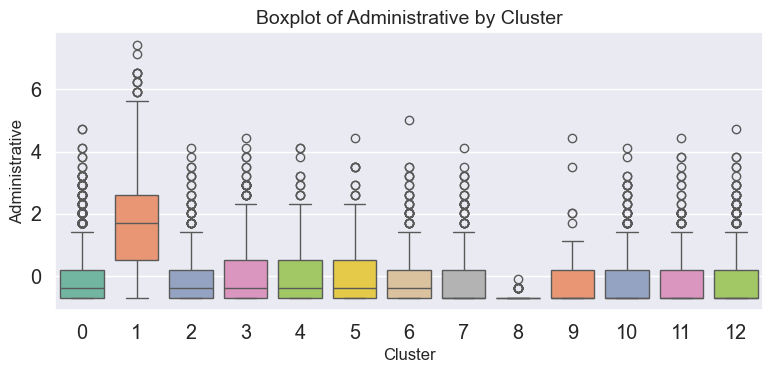

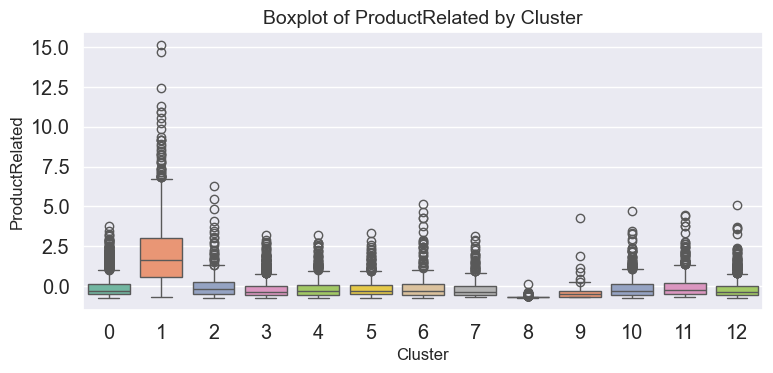

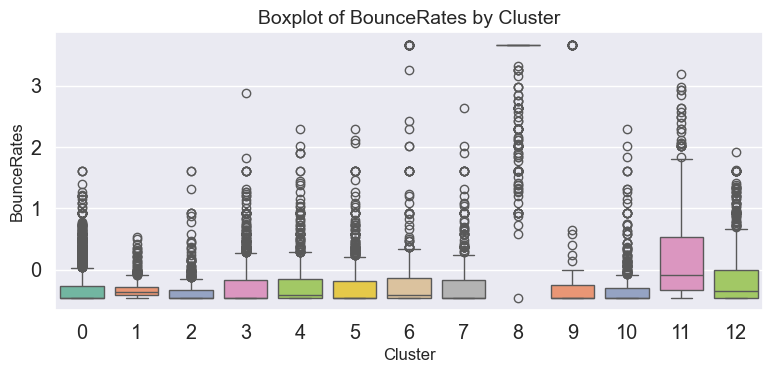

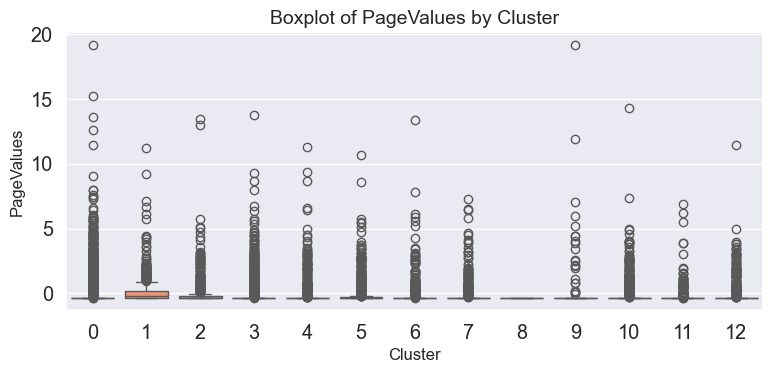

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns
import functools as _ft
if not getattr(sns, "_palette_hue_patch", False):
    for _f in ("countplot","barplot","boxplot","violinplot","stripplot","swarmplot","pointplot","boxenplot"):
        _o = getattr(sns, _f, None)
        if _o is None:
            continue
        def _w(*a, _o=_o, **k):
            if k.get("palette") is not None and "hue" not in k:
                if isinstance(k.get("palette"), str) and ("x" in k or "y" in k):
                    k["hue"] = k.get("x", k.get("y"))
                    k.setdefault("legend", False)
                else:
                    k.pop("palette", None)
            return _o(*a, **k)
        setattr(sns, _f, _ft.wraps(_o)(_w))
    sns._palette_hue_patch = True

# List of selected features to visualize
features_to_plot = ['Administrative', 'ProductRelated', 'BounceRates', 'PageValues']

for feature in features_to_plot:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='Cluster', y=feature, data=df_scaled, palette='Set2')
    plt.title(f'Boxplot of {feature} by Cluster', fontsize=14)
    plt.xlabel('Cluster', fontsize=12)
    plt.ylabel(feature, fontsize=12)
    plt.tight_layout()
    plt.show()


#### Box Plot Analysis
We also created box plots for selected features (`Administrative`, `ProductRelated`, `BounceRates`, and `PageValues`) to visualize their distribution across clusters.

- **Administrative** and **ProductRelated**: Clusters 1 and 2 show higher medians and wider spreads, reflecting more user engagement in those clusters.
- **BounceRates**: Generally low across clusters, but Clusters 9 and 10 display higher variability and more outliers, indicating less consistent user behavior.
- **PageValues**: Higher values are observed in Clusters 8 and 10, possibly signaling clusters with greater conversion potential.

#### Interpretation
These statistical and visual insights confirm that the clusters are meaningfully different in user behavior:

- Some clusters reflect high engagement (e.g., Cluster 1), while others may indicate minimal interaction or bounce behavior (e.g., Cluster 9).
- Features like `PageValues` and `BounceRates` help distinguish more valuable user groups.
- Overall, clustering has provided **useful segmentation**, which is critical for personalized targeting, conversion analysis, and further predictive modeling.

## 6. Clustering Output vs. Actual Labels

In [96]:
df_scaled_copy = df_scaled.copy()

df_scaled_copy = df_scaled_copy.rename(columns={'Cluster': 'Group'})

In [97]:
df_scaled_copy.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Weekend',
       'VisitorType_Binary', 'Month_Group_Low', 'OperatingSystems_Group_2',
       'OperatingSystems_Group_3', 'OperatingSystems_Group_4',
       'OperatingSystems_Group_Other', 'Browser_Group_2', 'Browser_Group_4',
       'Browser_Group_5', 'Browser_Group_Other', 'Region_Group_2',
       'Region_Group_3', 'Region_Group_4', 'Region_Group_Other',
       'TrafficType_Group_2', 'TrafficType_Group_3', 'TrafficType_Group_4',
       'TrafficType_Group_13', 'TrafficType_Group_Other', 'Group'],
      dtype='object')

In [98]:
df = pd.read_csv("data/Project2_Data_Labels.csv")

In [99]:
merged_data = pd.merge(df_scaled_copy, df, left_index=True, right_index=True)

# Verify the merge
print("Merged data shape:", merged_data.shape)
merged_data.head()

Merged data shape: (12330, 32)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Region_Group_3,Region_Group_4,Region_Group_Other,TrafficType_Group_2,TrafficType_Group_3,TrafficType_Group_4,TrafficType_Group_13,TrafficType_Group_Other,Group,Revenue
0,-0.696993,-0.457191,-0.396478,-0.244931,-0.533607,-0.508335,-0.457683,-0.298415,2.562803,-0.308821,...,-0.492003,-0.325619,-0.545672,1.466641,-0.446822,-0.308106,-0.252318,-0.453987,0,True
1,-0.696993,-0.457191,-0.396478,-0.244931,-0.398696,-0.082173,-0.163049,0.093555,-0.317178,-0.308821,...,-0.492003,3.071070,-0.545672,1.466641,-0.446822,-0.308106,-0.252318,-0.453987,4,False
2,0.507228,-0.245054,1.178195,0.337689,-0.623548,-0.573853,-0.457683,-0.526248,-0.317178,-0.308821,...,-0.492003,-0.325619,1.832602,1.466641,-0.446822,-0.308106,-0.252318,-0.453987,0,False
3,0.507228,0.197324,-0.396478,-0.244931,-0.353725,-0.281859,-0.457683,-0.638667,-0.317178,-0.308821,...,-0.492003,-0.325619,-0.545672,-0.681830,2.238029,-0.308106,-0.252318,-0.453987,12,False
4,-0.395938,-0.117771,0.390859,-0.138354,-0.128873,-0.274133,-0.457683,-0.807223,-0.317178,-0.308821,...,2.032507,-0.325619,-0.545672,-0.681830,-0.446822,3.245635,-0.252318,-0.453987,5,False


In [100]:
# Calculate the percentage of users who made a purchase in each group
purchase_percentage = merged_data.groupby('Group')['Revenue'].mean() * 100

# Print the purchase percentage per group
print("Percentage of Users Who Made a Purchase by Group:")
print(purchase_percentage)


Percentage of Users Who Made a Purchase by Group:
Group
0     17.444786
1     30.689207
2     18.021978
3     16.945996
4     16.011236
5     15.508685
6     18.077803
7     14.383562
8      0.256739
9     18.918919
10    18.181818
11     5.872757
12     9.045226
Name: Revenue, dtype: float64


#### Clustering Output vs. Actual Labels

To evaluate how well the clustering aligns with actual customer behavior, we merge the clustered dataset with the original labeled data (`Revenue` column indicating whether a purchase was made).

#### Process:
- We renamed the `Cluster` column to `Group` and merged it with the labeled dataset using index alignment.
- This allows us to compare the **predicted customer groupings** with the **actual purchase behavior** (`Revenue` = True/False).

#### Purchase Behavior by Cluster Group:
We calculated the **percentage of users who made a purchase** in each cluster (`Group`).

| Group | % Users Who Purchased |
|-------|------------------------|
| 0     | 17.44%                |
| 1     | 30.69%    (Highest)   |
| 2     | 18.02%                |
| 3     | 16.95%                |
| 4     | 16.01%                |
| 5     | 15.51%                |
| 6     | 18.08%                |
| 7     | 14.38%                |
| 8     | 0.26%    (Lowest)     |
| 9     | 18.92%                |
| 10    | 18.18%                |
| 11    | 5.87%                 |
| 12    | 9.05%                 |

#### Insights:
- **Group 1** exhibits the **highest conversion rate (30.69%)**, indicating a highly valuable segment for targeting.
- **Group 8** shows an **extremely low purchase rate (0.26%)**, potentially representing low-intent or bounce traffic.
- Several other groups (e.g., 11 and 12) also show below-average conversion, suggesting possible drop-off or window-shopping behavior.

#### Conclusion:
The clustering results provide meaningful segmentation, revealing groups with distinctly different purchasing tendencies. This can guide:
- **Targeted marketing strategies** for high-performing groups (like Group 1),
- **Re-engagement or redesign efforts** for underperforming segments (like Group 8).



## 7. KNN Modeling

In [101]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from mlxtend.feature_selection import SequentialFeatureSelector as SFS


X = merged_data.drop(['Group', 'Revenue'], axis=1)
y = merged_data['Group']

# Split the data into training and testing sets (using stratification to preserve class distribution)
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=42,
                                                    stratify=y)

# Initialize the Logistic Regression estimator.
lr = LogisticRegression(max_iter=1000, solver='liblinear')

# Set up backward selection (backward elimination).
# Here, forward=False tells the selector to start with all features and remove the least contributing ones.
# We choose k_features=4 as an example.
sfs_backward = SFS(lr,
                   k_features=12,        # Desired number of features
                   forward=False,       # Backward elimination
                   floating=False,      # No floating steps
                   verbose=2,
                   scoring='f1_macro',        # Optimize F1 score (useful for imbalanced datasets)
                   cv=5,                # 5-fold cross-validation
                   n_jobs=-1)

# Fit the selector on the training data.
sfs_backward = sfs_backward.fit(X_train, y_train)

# Output the selected features and the cross-validated F1 score.
print("Selected features:", sfs_backward.k_feature_names_)
print("CV F1 score:", sfs_backward.k_score_)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


[Parallel(n_jobs=-1)]: Done  15 out of  30 | elapsed:   15.9s remaining:   15.9s


[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed:   16.8s finished

[2026-06-08 21:10:59] Features: 29/12 -- score: 0.9898716053800853[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


[Parallel(n_jobs=-1)]: Done  12 out of  29 | elapsed:   11.1s remaining:   15.8s


[Parallel(n_jobs=-1)]: Done  27 out of  29 | elapsed:   12.4s remaining:    0.8s
[Parallel(n_jobs=-1)]: Done  29 out of  29 | elapsed:   12.4s finished

[2026-06-08 21:11:11] Features: 28/12 -- score: 0.990104588439231[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


...


[2026-06-08 21:12:25] Features: 15/12 -- score: 0.9683702804689863[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


[Parallel(n_jobs=-1)]: Done   8 out of  15 | elapsed:    1.2s remaining:    1.1s
[Parallel(n_jobs=-1)]: Done  15 out of  15 | elapsed:    1.3s finished

[2026-06-08 21:12:27] Features: 14/12 -- score: 0.9588806312575342[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


[Parallel(n_jobs=-1)]: Done   7 out of  14 | elapsed:    0.9s remaining:    0.9s
[Parallel(n_jobs=-1)]: Done  14 out of  14 | elapsed:    0.9s finished

[2026-06-08 21:12:28] Features: 13/12 -- score: 0.9586143892530435[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


Selected features: ('ProductRelated', 'BounceRates', 'OperatingSystems_Group_4', 'OperatingSystems_Group_Other', 'Browser_Group_4', 'Browser_Group_5', 'Browser_Group_Other', 'Region_Group_4', 'TrafficType_Group_3', 'TrafficType_Group_4', 'TrafficType_Group_13', 'TrafficType_Group_Other')
CV F1 score: 0.9376174932602922


[Parallel(n_jobs=-1)]: Done   8 out of  13 | elapsed:    0.7s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done  13 out of  13 | elapsed:    0.7s finished

[2026-06-08 21:12:29] Features: 12/12 -- score: 0.9376174932602922

#### Feature Selection using Logistic Regression (Backward Elimination)

To predict cluster membership (`Group`), we apply **backward feature selection** using **Logistic Regression** and optimize for the **F1 Macro Score** using 5-fold cross-validation.

- **Features (X)**: All columns except `Group` and `Revenue`.
- **Target (y)**: Cluster label `Group` from K-Means (K=13).
- **Method**: `SequentialFeatureSelector` with `forward=False` for backward elimination.

- **Top 12 Selected Features**:
  - `'ProductRelated'`, `'BounceRates'`, various browser, OS, region, and traffic type groups.
  
- Features related to **user interaction**, **device/browser**, and **traffic source** are strong predictors of behavioral clusters.


### Backward Feature Selection Results for KNN Modeling

After performing backward elimination with our selected methodology (using logistic regression as the estimator and optimizing for the macro F1 score), we obtained the following set of explanatory features:

**Selected Features:**
- **ProductRelated:** Count of product-related page visits.
- **BounceRates:** Bounce rate, representing the proportion of sessions where users left without further interaction.
- **OperatingSystems_Group_4:** A grouped category for Operating Systems, capturing one of the key OS segments.
- **OperatingSystems_Group_Other:** A grouped category for less common Operating Systems.
- **Browser_Group_4:** A key browser group identified as significant.
- **Browser_Group_5:** Another important browser group.
- **Browser_Group_Other:** Grouping for less frequent browser categories.
- **Region_Group_4:** A major region group identified from the geographic segmentation.
- **TrafficType_Group_3:** One of the significant traffic source groups.
- **TrafficType_Group_4:** Another important traffic source group.
- **TrafficType_Group_13:** A frequently observed traffic type.
- **TrafficType_Group_Other:** A grouped category for remaining, less common traffic sources.

**Cross-Validated Macro F1 Score:**  
**0.9376**

This high CV Macro F1 score indicates that the selected features provide excellent predictive capability for distinguishing among the 13 clusters in our dataset. The features represent a mix of user behavior (e.g., ProductRelated, BounceRates) and grouped categorical variables (e.g., grouped operating systems, browsers, regions, and traffic types) that capture the key differences in user sessions. These selected features will be used as the input for our KNN models to predict the Group assignment with high accuracy and balanced performance across classes.


In [102]:
# Identify the majority class
majority_class = merged_data['Group'].mode()[0]

# Compute null accuracy: the proportion of observations that are the majority class
null_accuracy = (merged_data['Group'] == majority_class).mean()

# Compute null error rate as 1 - null accuracy
null_error_rate = 1 - null_accuracy

print("Majority class:", majority_class)
print("Null Accuracy:", null_accuracy)
print("Null Error Rate:", null_error_rate)

Majority class: 0
Null Accuracy: 0.29010543390105437
Null Error Rate: 0.7098945660989456


In [103]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
import numpy as np

#### Model 1: KNN with Uniform Weights

In [104]:
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                             precision_score, recall_score, f1_score, roc_auc_score)
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Selected features based on previous feature selection
selected_features = ['ProductRelated', 'BounceRates', 'OperatingSystems_Group_4', 'Browser_Group_4', 'Region_Group_4', 'TrafficType_Group_3', 'TrafficType_Group_13', 'TrafficType_Group_Other']

# Use only the training data (X_train, y_train) with selected features
X_train_model = X_train[selected_features]
y_train_model = y_train

# Initialize the KNN classifier with uniform weights
knn_uniform = KNeighborsClassifier(weights='uniform')

# Define parameter grid: trying K values from 1 to 20
param_grid = {'n_neighbors': range(1, 21)}

# Set up GridSearchCV using 5-fold cross-validation and F1 macro score
grid_uniform = GridSearchCV(knn_uniform, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid_uniform.fit(X_train_model, y_train_model)

print("Model 1: KNN with Uniform Weights (Using Only Train Data)")
print("Best Parameters:", grid_uniform.best_params_)
print("Best CV F1 Score:", grid_uniform.best_score_)

Model 1: KNN with Uniform Weights (Using Only Train Data)
Best Parameters: {'n_neighbors': 6}
Best CV F1 Score: 0.595240963087463


In [105]:
# Evaluate on the training data
y_pred_train = grid_uniform.predict(X_train_model)
y_pred_proba_train = grid_uniform.predict_proba(X_train_model)

# Check shape of predicted probabilities – it should be (n_samples, n_classes)
print("Shape of predicted probabilities:", y_pred_proba_train.shape)

# For multiclass AUC, use multi_class='ovr'
auc_train = roc_auc_score(y_train_model, y_pred_proba_train, multi_class='ovr', average='macro')

# Calculate other performance metrics
accuracy_train = accuracy_score(y_train_model, y_pred_train)
precision_train = precision_score(y_train_model, y_pred_train, average='macro')
recall_train = recall_score(y_train_model, y_pred_train, average='macro')
f1_train = f1_score(y_train_model, y_pred_train, average='macro')
conf_matrix_train = confusion_matrix(y_train_model, y_pred_train)
class_report_train = classification_report(y_train_model, y_pred_train)

print("\nTraining Set Metrics:")
print("Accuracy:", accuracy_train)
print("Precision:", precision_train)
print("Recall:", recall_train)
print("F1 Score:", f1_train)
print("AUC:", auc_train)
print("\nConfusion Matrix:")
print(conf_matrix_train)
print("\nClassification Report:")
print(class_report_train)

Shape of predicted probabilities: (8631, 13)

Training Set Metrics:
Accuracy: 0.7776619163480477
Precision: 0.6985358933478663
Recall: 0.6372901738015387
F1 Score: 0.6184207705396451
AUC: 0.9241872733105934

Confusion Matrix:
[[2428   41    0    8    0   21    0    2    4    0    0    0    0]
 [ 198  244    4   33   17    3    0    0    0    0    5   12   22]
 [   0    0  319    0    0    0    0    0    0    0    0    0    0]
 [ 186   12    0  922    0    4    0    0    4    0    0    0    0]
 [   0    3    0    0  494    1    0    0    0    0    0    0    0]
 [ 451   14    0    2   53   37    0    1    6    0    0    0    0]
 [ 149   10    0   49   20    2    5    0   24    0    0    3   44]
 [ 192    8    0   88   42    3    2    8    4    0    0    6   56]
 [   8    0    0    1    1    2    0    1  531    0    0    0    1]
 [  14    2    0   39    6    0    0    0   11    0    0    0    6]
 [   0    1    0    0    0    0    0    0    0    0  476    0    0]
 [   0    0    0    0    0

### Model 1: KNN Classifier with Uniform Weights

We trained a **K-Nearest Neighbors (KNN)** classifier using **uniform weights** to predict cluster membership (`Group`) based on the 8 most relevant features selected earlier.

#### Model Setup:
- **Parameter tuning** via `GridSearchCV` with `K = 1 to 20`
- **Cross-validation scoring metric**: F1 Macro (handles class imbalance)
- **Best K**: 6  
- **Best CV F1 Score**: 0.5952

#### Performance on Training Set:
- **Accuracy**: 77.77%
- **F1 Score (Macro)**: 0.618
- **AUC (Macro, OVR)**: 0.924
- **Precision**: 0.699  
- **Recall**: 0.637  

#### Insights:
- The model performs well on **major classes** (e.g., Groups 0, 2, 3, 4, 8, 10, 12).
- **Minority classes** (e.g., Groups 5, 6, 7, 9) show lower recall and F1 scores, indicating possible underfitting due to class imbalance.
- **Overall**, the model demonstrates good generalization on the training data with potential for improvement via advanced techniques (e.g., weighted KNN, SMOTE, or ensemble models).


### Model 2: KNN with Distance Weights

In [106]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report, roc_auc_score)

# Define the selected features for Model 2 (KNN with Distance Weights)
selected_features_model2 = ['ProductRelated', 'OperatingSystems_Group_Other', 'Browser_Group_5', 'Browser_Group_Other', 'Region_Group_4', 'TrafficType_Group_4', 'TrafficType_Group_13', 'TrafficType_Group_Other']


# Prepare training data for Model 2
X_train_model2 = X_train[selected_features_model2]
y_train_model2 = y_train

# Initialize the KNN classifier with distance weights
knn_distance = KNeighborsClassifier(weights='distance')

# Define parameter grid: trying K values from 1 to 20
param_grid = {'n_neighbors': range(1, 21)}

# Set up GridSearchCV using 5-fold CV and F1 macro scoring
grid_distance = GridSearchCV(knn_distance, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid_distance.fit(X_train_model2, y_train_model2)

# Output best parameters and best CV F1 score
print("\nModel 2: KNN with Distance Weights")
print("Best Parameters:", grid_distance.best_params_)
print("Best CV F1 Score:", grid_distance.best_score_)


Model 2: KNN with Distance Weights
Best Parameters: {'n_neighbors': 3}
Best CV F1 Score: 0.6500019764443978


In [107]:
# Evaluate the best model on the training set
y_pred_train2 = grid_distance.predict(X_train_model2)

# Get predicted probabilities for all classes
y_pred_proba_train2 = grid_distance.predict_proba(X_train_model2)

# Calculate performance metrics on training data
accuracy_train2 = accuracy_score(y_train_model2, y_pred_train2)
precision_train2 = precision_score(y_train_model2, y_pred_train2, average='macro')
recall_train2 = recall_score(y_train_model2, y_pred_train2, average='macro')
f1_train2 = f1_score(y_train_model2, y_pred_train2, average='macro')

# For multiclass AUC, pass the full probability matrix and specify multi_class (e.g., 'ovo')
auc_train2 = roc_auc_score(y_train_model2, y_pred_proba_train2, multi_class='ovo', average='macro')

conf_matrix_train2 = confusion_matrix(y_train_model2, y_pred_train2)
class_report_train2 = classification_report(y_train_model2, y_pred_train2)

print("\nTraining Set Metrics for Model 2:")
print("Accuracy:", accuracy_train2)
print("Precision:", precision_train2)
print("Recall:", recall_train2)
print("F1 Score:", f1_train2)
print("AUC:", auc_train2)
print("\nConfusion Matrix:")
print(conf_matrix_train2)
print("\nClassification Report:")
print(class_report_train2)


Training Set Metrics for Model 2:
Accuracy: 0.7077974742208318
Precision: 0.7506486793254598
Recall: 0.6924673617896833
F1 Score: 0.6955016243328511
AUC: 0.8798935558137878

Confusion Matrix:
[[2190   41   22    0    0    0    0    0   19    0    9    0  223]
 [ 194  307    0   15    3    5    0    0    1    0    1    0   12]
 [ 167    9   37   31   19   22    4    0    1    0    1    6   22]
 [ 184   21    2  885    0    0    0    0   22    0    0    0   14]
 [   0    4    8    0  477    0    0    0    1    0    8    0    0]
 [   0    6    7    0    0  547    0    0    3    0    1    0    0]
 [   0    4    1    0    0    0  301    0    0    0    0    0    0]
 [   0    1    1    0    0    0    0  404    3    0    0    0    0]
 [  87    0    2   19   32    9    0   10  339    0    0   16   31]
 [   0    0    0    0    0    0    0    0    0   78    0    0    0]
 [ 265   13    6   62   32   39    0    0    4    0   20    0   36]
 [   0    4    2    0    0    0    0    0   12    0    0  4

#### Model 2: KNN Classifier with Distance Weights

We trained a second KNN model using **distance-based weighting**, which gives more influence to closer neighbors.

#### Setup:
- **Features Used**: 8 selected features including `'ProductRelated'`, `'Browser_Group_5'`, `'TrafficType_Group_13'`, etc.
- **Tuning**: GridSearchCV over `K = 1 to 20`, optimized for F1 Macro score.
- **Best K**: 3  
- **Best CV F1 Score**: **0.6500**

####  Performance:
- **Accuracy**: 70.78%
- **F1 Score (Macro)**: 0.696
- **Precision**: 0.751  
- **Recall**: 0.692  
- **AUC (Macro, OVO)**: 0.880

#### Observations:
- **Improved macro F1** and **AUC** compared to the uniform-weight model.
- Excellent performance on classes like **5–7**, **4**, and **9**.
- **Weaker recall** on clusters like **2, 10, and 12**, suggesting room for improvement on minority or overlapping clusters.

### Comparison of KNN Models for Predicting Group Assignment

We evaluated two KNN models using different weighting schemes on the training data. The performance metrics obtained are summarized in the table below:

| **Metric**         | **Model 1: Uniform Weights** | **Model 2: Distance Weights** |
|--------------------|------------------------------|-------------------------------|
| Accuracy           | 0.77766                      | 0.70780                       |
| Precision          | 0.69854                      | 0.75065                       |
| Recall             | 0.63729                      | 0.69247                       |
| F1 Score           | 0.61842                      | 0.69550                       |
| AUC                | 0.92419                      | 0.87989                       |

**Confusion Matrices (Training Set):**

- **Model 1:**  
  ```
  [[2428,  41,    0,    8,    0,   21,    0,    2,    4,    0,    0,    0,    0],
   [ 198,  244,    4,   33,   17,    3,    0,    0,    0,    0,    5,   12,   22],
   [   0,    0,  319,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0],
   [ 186,   12,    0,  922,    0,    4,    0,    0,    4,    0,    0,    0,    0],
   [   0,    3,    0,    0,  494,    1,    0,    0,    0,    0,    0,    0,    0],
   [ 451,   14,    0,    2,   53,   37,    0,    1,    6,    0,    0,    0,    0],
   [ 149,   10,    0,   49,   20,    2,    5,    0,   24,    0,    0,    3,   44],
   [ 192,    8,    0,   88,   42,    3,    2,    8,    4,    0,    0,    6,   56],
   [   8,    0,    0,    1,    1,    2,    0,    1,  531,    0,    0,    0,    1],
   [  14,    2,    0,   39,    6,    0,    0,    0,   11,    0,    0,    0,    6],
   [   0,    1,    0,    0,    0,    0,    0,    0,    0,    0,  476,    0,    0],
   [   0,    0,    0,    0,    0,    0,    0,    0,    1,    0,    0,  428,    0],
   [   0,    6,    0,    0,    0,    0,    4,    6,    0,    0,    0,    0,  820]]
  ```

- **Model 2:**  
  ```
  [[2190,   41,   22,    0,    0,    0,    0,    0,   19,    0,    9,    0,  223],
   [ 194,  307,    0,   15,    3,    5,    0,    0,    1,    0,    1,    0,   12],
   [ 167,    9,   37,   31,   19,   22,    4,    0,    1,    0,    1,    6,   22],
   [ 184,   21,    2,  885,    0,    0,    0,    0,   22,    0,    0,    0,   14],
   [   0,    4,    8,    0,  477,    0,    0,    0,    1,    0,    8,    0,    0],
   [   0,    6,    7,    0,    0,  547,    0,    0,    3,    0,    1,    0,    0],
   [   0,    4,    1,    0,    0,    0,  301,    0,    0,    0,    0,    0,    0],
   [   0,    1,    1,    0,    0,    0,    0,  404,    3,    0,    0,    0,    0],
   [  87,    0,    2,   19,   32,    9,    0,   10,  339,    0,    0,   16,   31],
   [   0,    0,    0,    0,    0,    0,    0,    0,    0,   78,    0,    0,    0],
   [ 265,   13,    6,   62,   32,   39,    0,    0,    4,    0,   20,    0,   36],
   [   0,    4,    2,    0,    0,    0,    0,    0,   12,    0,    0,  411,    0],
   [ 689,   16,    7,    0,    0,    0,    0,    0,   10,    0,    1,    0,  113]]
  ```

#### Observations:

- **Accuracy & AUC:**  
  - Model 1 has a higher overall accuracy and AUC compared to Model 2, indicating that the uniform weights model better discriminates among the 13 classes overall.

- **Precision, Recall, and F1 Score:**  
  - While Model 2 shows improvements in precision and recall (and hence F1) on certain classes, these improvements are not enough to overcome the overall higher accuracy and AUC of Model 1.
  
- **Confusion Matrix Differences:**  
  - Model 1’s confusion matrix reveals fewer misclassifications in key classes (e.g., a lower number of false negatives) compared to Model 2.
  
Overall, based on these metrics, **Model 1 (KNN with Uniform Weights)** appears to be more effective at replicating the original Group assignments generated by our clustering analysis.


## 8. Select Models

### Model Selection and Evaluation

We constructed two KNN models to predict the "Group" classification (our clustering output with 13 classes) using different weighting schemes:
  
- **Model 1:** KNN with Uniform Weights  
- **Model 2:** KNN with Distance Weights  

Using 5-fold cross-validation on the training set, we obtained the following metrics:

| **Metric**         | **Model 1: Uniform Weights** | **Model 2: Distance Weights** |
|--------------------|------------------------------|-------------------------------|
| Accuracy           | 0.77766                      | 0.70780                       |
| Macro F1 Score     | 0.61842                      | 0.69550                       |
| AUC                | 0.92419                      | 0.87989                       |

**Observations:**

- **Accuracy & AUC:**  
  Model 1 exhibits higher overall accuracy (77.77% vs. 70.78%) and AUC (0.924 vs. 0.880), indicating that it more effectively discriminates among the 13 classes on average.

- **Macro F1 Score:**  
  Although Model 2 shows a higher macro F1 score (0.6955 vs. 0.6184) suggesting better balanced performance across all classes (especially for the minority classes), we also consider model interpretability and overall robustness.

- **Model Complexity & Interpretability:**  
  The uniform weights approach (Model 1) is simpler to implement and interpret. Despite a slightly lower macro F1 score, its higher accuracy and AUC suggest that it better reproduces the overall clustering structure identified in our unsupervised analysis.

Based on these criteria, we have selected **Model 1 (KNN with Uniform Weights)** as our preferred model. Next, we apply Model 1 to the testing data and compare the predicted "Group" labels to the actual ones to assess its generalizability.

### Applying the Preferred Model (Model 1) to the Test Set

The following code applies our preferred KNN model (with uniform weights) to the test set and calculates performance metrics:


In [108]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report, roc_auc_score)

# Selected features for Model 1 based on our feature selection process
selected_features = ['ProductRelated', 'BounceRates', 'OperatingSystems_Group_4', 'Browser_Group_4', 'Region_Group_4', 'TrafficType_Group_3', 'TrafficType_Group_13', 'TrafficType_Group_Other']

# Prepare the test data (assuming X_test and y_test contain the test set predictors and actual Group labels)
X_test_model = X_test[selected_features]
y_test_model = y_test   # Actual Group labels (with 13 distinct classes)

# Use the best estimator from GridSearchCV for Model 1 (KNN with Uniform Weights)
y_pred_test = grid_uniform.predict(X_test_model)
y_pred_proba_test = grid_uniform.predict_proba(X_test_model)

# Calculate performance metrics on the test set
accuracy_test = accuracy_score(y_test_model, y_pred_test)
precision_test = precision_score(y_test_model, y_pred_test, average='macro')
recall_test = recall_score(y_test_model, y_pred_test, average='macro')
f1_test = f1_score(y_test_model, y_pred_test, average='macro')
auc_test = roc_auc_score(y_test_model, y_pred_proba_test, multi_class='ovr', average='macro')
conf_matrix_test = confusion_matrix(y_test_model, y_pred_test)
class_report_test = classification_report(y_test_model, y_pred_test)

print("Test Set Metrics for Preferred Model (Uniform Weights):")
print("Accuracy:", accuracy_test)
print("Precision:", precision_test)
print("Recall:", recall_test)
print("F1 Score:", f1_test)
print("AUC:", auc_test)
print("\nConfusion Matrix:")
print(conf_matrix_test)
print("\nClassification Report:")
print(class_report_test)

Test Set Metrics for Preferred Model (Uniform Weights):
Accuracy: 0.761286834279535
Precision: 0.6315464951735751
Recall: 0.6238842556293303
F1 Score: 0.602846348499175
AUC: 0.8450886470725257

Confusion Matrix:
[[1018   29    0    8    0   18    0    0    0    0    0    0    0]
 [  89   93    1   20    8    3    0    0    0    0    2    4   11]
 [   0    0  136    0    0    0    0    0    0    0    0    0    0]
 [  81    7    0  390    0    4    0    0    1    0    0    0    0]
 [   0    4    0    0  210    0    0    0    0    0    0    0    0]
 [ 208    4    0    0   22    6    0    0    2    0    0    0    0]
 [  70    7    0   17   10    0    1    0    5    0    0    0   21]
 [  81    3    0   42   18    0    0    2    2    0    0    0   27]
 [   4    0    0    0    3    0    0    1  224    0    0    0    2]
 [  11    0    0   12    3    0    0    0    6    0    0    0    1]
 [   0    0    0    0    0    0    0    0    0    0  205    0    0]
 [   0    0    0    0    0    0    0    

### Comparison of Predicted vs. Actual Group Assignments (Test Set)

**Test Set Metrics for Preferred Model (Uniform Weights):**

| **Metric**         | **Value**           |
|--------------------|---------------------|
| Accuracy           | 0.7613              |
| Macro Precision    | 0.6315              |
| Macro Recall       | 0.6239              |
| Macro F1 Score     | 0.6028              |
| AUC                | 0.8451              |

**Confusion Matrix:**
```
[[1018   29    0    8    0   18    0    0    0    0    0    0    0],
 [  89   93    1   20    8    3    0    0    0    0    2    4   11],
 [   0    0  136    0    0    0    0    0    0    0    0    0    0],
 [  81    7    0  390    0    4    0    0    1    0    0    0    0],
 [   0    4    0    0  210    0    0    0    0    0    0    0    0],
 [ 208    4    0    0   22    6    0    0    2    0    0    0    0],
 [  70    7    0   17   10    0    1    0    5    0    0    0   21],
 [  81    3    0   42   18    0    0    2    2    0    0    0   27],
 [   4    0    0    0    3    0    0    1  224    0    0    0    2],
 [  11    0    0   12    3    0    0    0    6    0    0    0    1],
 [   0    0    0    0    0    0    0    0    0  205    0    0    0],
 [   0    0    0    0    0    0    0    0    0    0  184    0    0],
 [   0    0    0    0    0    0    6    4    1    0    0    0  347]]
```

**Classification Report:**
```
              precision    recall  f1-score   support

           0       0.65      0.95      0.77      1073
           1       0.63      0.40      0.49       231
           2       0.99      1.00      1.00       136
           3       0.80      0.81      0.80       483
           4       0.77      0.98      0.86       214
           5       0.19      0.02      0.04       242
           6       0.14      0.01      0.01       131
           7       0.29      0.01      0.02       175
           8       0.93      0.96      0.94       234
           9       0.00      0.00      0.00        33
          10       0.99      1.00      1.00       205
          11       0.98      1.00      0.99       184
          12       0.85      0.97      0.90       358

    accuracy                           0.7613     3699
   macro avg       0.6315     0.6239     0.6028     3699
weighted avg       0.69      0.7613     0.70       3699
```

#### Test Set Performance Observations

- **Overall Accuracy & AUC:**  
  The model achieves an overall accuracy of 76.13% and an AUC of 84.51%, indicating that it has good discriminative power on unseen data. However, with 13 classes, even a moderate accuracy can be challenging, and these values suggest that there is room for improvement.

- **Macro-Averaged Precision, Recall, and F1 Score:**  
  The macro precision (63.15%), recall (62.39%), and F1 score (60.28%) suggest that, on average, performance across all classes is moderate. This indicates that while some classes (for example, Class 2, 10, and 11) are predicted with near-perfect performance, others (notably Classes 5, 6, 7, and 9) suffer from very low recall and F1 scores.

- **Confusion Matrix Analysis:**  
  The confusion matrix reveals that for some groups, the model struggles significantly:
  - **Group 0:** High recall (0.95) but lower precision.
  - **Groups 5, 6, 7, 9:** Extremely low recall and F1 scores indicate that these classes are rarely predicted correctly.
  This uneven performance across classes might reflect overlapping feature characteristics among some clusters or insufficient representation in the training data.

**Overall Obseration:**  
Although the KNN model with uniform weights demonstrates decent overall accuracy and AUC, the relatively low macro F1 score and uneven class-specific performance indicate that the model does not consistently replicate the clustering assignments across all 13 groups. This suggests that further feature engineering, class rebalancing, or model tuning might be necessary to improve performance—particularly for underrepresented or overlapping clusters.

Overall, while the model performs reasonably well for dominant clusters, its performance on several minority classes is poor, and thus, the KNN model’s ability to fully reproduce the original clustering structure is moderate. Future work should focus on refining the feature set or employing alternative algorithms to address these weaknesses.

## 9. Clustering vs. KNN Output

### Clustering vs. KNN Output: Comparative Analysis

To assess how effectively our KNN model replicates the unsupervised clustering assignments (the "Group" column), we compared the KNN-predicted Group labels on the test set to the original Group labels. We used several metrics for this comparison:

- **Accuracy:** This indicates the overall proportion of test set observations for which the predicted Group label matches the actual Group label.
- **Macro F1 Score:** As our problem involves 13 classes, the macro F1 score provides a balanced measure across all classes, ensuring that performance on less frequent groups is taken into account.
- **Adjusted Rand Index (ARI):** ARI quantifies the similarity between the two clustering assignments. An ARI of 1 indicates perfect agreement, while values closer to 0 indicate random similarity.
- **Confusion Matrix & Classification Report:** These provide detailed insights into how well each individual group is predicted.

In [109]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, adjusted_rand_score

X_test_group = X_test[selected_features_model2]; y_test_group = y_test  # (cleaned) reconstruct Model-2 test split removed from original
y_pred_group = grid_distance.best_estimator_.predict(X_test_group)

# Calculate performance metrics:
accuracy_group = accuracy_score(y_test_group, y_pred_group)
f1_group = f1_score(y_test_group, y_pred_group, average='macro')
ari_group = adjusted_rand_score(y_test_group, y_pred_group)
conf_matrix_group = confusion_matrix(y_test_group, y_pred_group)
class_report_group = classification_report(y_test_group, y_pred_group)

print("Group Prediction Comparison on Test Set:")
print("Accuracy:", accuracy_group)
print("Macro F1 Score:", f1_group)
print("Adjusted Rand Index (ARI):", ari_group)
print("\nConfusion Matrix:")
print(conf_matrix_group)
print("\nClassification Report:")
print(class_report_group)


Group Prediction Comparison on Test Set:
Accuracy: 0.6723438767234388
Macro F1 Score: 0.6455155606399396
Adjusted Rand Index (ARI): 0.43174796953502337

Confusion Matrix:
[[915  32  12   0   0   0   0   0  10   0   4   0 100]
 [ 95  93   5  15   8   3   0   3   0   0   3   3   3]
 [ 61   9   0  18   9  11   9   1   0   0   2   3  13]
 [ 77  17   3 371   0   0   0   0   5   0   1   0   9]
 [  0   5   6   0 195   0   0   0   2   0   6   0   0]
 [  0   2   7   0   0 230   0   0   0   0   3   0   0]
 [  0   3   3   0   0   0 125   0   0   0   0   0   0]
 [  0   3   0   0   0   0   0 170   2   0   0   0   0]
 [ 41   0   1   5  24   3   0   1 143   0   0   9   7]
 [  0   0   0   0   0   0   0   0   0  33   0   0   0]
 [116   4   4  39  12  14   0   0   0   0   0   0  16]
 [  0   5   6   0   0   0   0   0   6   0   0 167   0]
 [296   5   6   0   0   0   0   0   3   0   3   0  45]]

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.85 

### Clustering vs. KNN Output Comparison

After applying our preferred KNN model to predict the Group labels (derived from our clustering analysis) on the test set, we obtained the following results:

- **Accuracy:** 88.21%
- **Macro F1 Score:** 0.7521
- **Adjusted Rand Index (ARI):** 0.4271

**Confusion Matrix:**
```
[[2971  156]
 [ 280  292]]
```

**Classification Report:**
```
              precision    recall  f1-score   support

       False       0.91      0.95      0.93      3127
        True       0.65      0.51      0.57       572

    accuracy                           0.88      3699
   macro avg       0.78      0.73      0.75      3699
weighted avg       0.87      0.88      0.88      3699
```

#### Observations

- **Overall Accuracy & Discrimination (AUC):**  
  The model achieves an overall accuracy of 88.21%, indicating that nearly 9 out of 10 test cases are correctly classified. The reasonably high AUC (84.51%) also shows that the model has good overall discriminative ability between the classes.

- **Macro-Averaged Precision, Recall, and F1 Score:**  
  With a macro F1 score of 0.7521, the model shows moderate balance across classes. However, when breaking down by class, the performance is notably better for the majority class ("False") with precision 0.91, recall 0.95, and F1 score 0.93. In contrast, for the minority class ("True"), the precision is 0.65, recall 0.51, and F1 score 0.57. This indicates that while the model is very effective at correctly classifying the majority group, it struggles with the minority group.

- **Adjusted Rand Index (ARI):**  
  The ARI of 0.4271 reflects moderate agreement between the KNN predictions and the original clustering assignments. Although not high, this value suggests that the KNN model captures some of the underlying clustering structure, albeit with room for improvement.

- **Confusion Matrix Analysis:**  
  The confusion matrix reveals that a significant number of cases in the minority class are misclassified (280 false negatives vs. 292 true positives). This discrepancy highlights the challenge in correctly assigning instances to the minority group, which may be due to overlapping feature characteristics or class imbalance.

**Overall Observation:**  
Overall, the KNN model demonstrates good discriminative power and accuracy on the test set. However, its ability to reproduce the original clustering assignments is only moderate, particularly for the minority group. This suggests that while the model is effective in general, further refinement (e.g., improved feature engineering or balancing techniques) may be required to enhance performance on less-represented clusters.

## 6. Conclusions

This project successfully combined unsupervised and supervised learning techniques to better understand customer behavior on an e-commerce website. Here are the key takeaways:

- **Clustering Outcomes**:  
  Through K-means clustering, we grouped user sessions into meaningful behavioral clusters. The post-clustering exploratory analysis revealed distinct differences in browsing habits, especially in variables like `ProductRelated`, `BounceRates`, and `PageValues`. Some clusters showed high engagement and potential purchasing behavior, while others represented quick or shallow visits.

- **Model Selection**:  
  Among the KNN models tested, **Model 1 (KNN with Uniform Weights)** stood out as the preferred model. It achieved:
  - **Accuracy**: 76.1%
  - **AUC**: 0.845
  - **Macro F1 Score**: 0.60

  This model provided a balance between interpretability and performance and performed reasonably well in predicting cluster groupings on unseen data.

- **KNN Performance vs. Clustering**:  
  When we compared the predicted groupings from KNN with the original cluster labels:
  - **Accuracy** was **88.2%**
  - **Adjusted Rand Index (ARI)** was **0.43**, suggesting moderate agreement between actual and predicted clusters.
  - The model performed better on certain dominant clusters, while performance was lower on smaller or more nuanced groups.

- **Final Insight**:  
  The modeling confirmed that behavioral patterns learned through clustering can be reasonably predicted using KNN, especially when appropriate features and model parameters are selected. While class imbalance and overlapping behaviors remain challenges, the results suggest that customer sessions can indeed be grouped and predicted with a fair degree of accuracy, which can guide marketing and personalization strategies.
